In [1]:
# Ran with predictors_simple kernel
# Python 3.10.8

import numpy as np # 1.26.4
import pandas as pd # 2.2.3
import tensorflow as tf # 2.10.0
import matplotlib # 3.10.3
import torch # 2.0.0

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.sans-serif'] = 'Arial'
from matplotlib import pyplot as plt

from joblib import load
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import auc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import statsmodels.stats.multitest as smt

import os
from tqdm import tqdm 

from analysis_functions import get_best_model 

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction/Model")
from ADModel_act import ADModel_act
from ADModel_three_state import ADModel_three_state_abund
from ADModel_two_state import ADModel_two_state_abund
from Data import DataReader, SplitData, FastTensorDataLoader, one_hot_encode


os.chdir("/Users/claireleblanc/Documents/tools_software/adhunter")
from actpred.models import ActCNNSystem

# Set Numpy to display floats with 3 decimal places
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction")

In [257]:
# Parameters to make figures work better with illustrator 
import matplotlib 
# For higher resoltion figures
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

In [347]:
# Original act results
simple_act_model_results = pd.read_csv('results/results_simple_act_test_LeakyReLU.csv')
simple_act_model_results['seed'] = [int(re.search("seed(\d+)", model.removeprefix("../../"))[1]) for model in  simple_act_model_results["model_name"]]

# Original abund results
simple_abund_model_results = pd.read_csv('results/results_simple_abund_test_LeakyReLU.csv')
simple_abund_model_results['seed'] = [int(re.search("seed(\d+)", model.removeprefix("../../"))[1]) for model in  simple_act_model_results["model_name"]]

# Original two state results
two_model_results = pd.read_csv('results/results_two_state_test_leakyrelu.csv')
two_model_results['abund_k'] = [int(re.search(r'ak(\d+)',model).group(1)) for model in two_model_results['model_name']]
two_model_results['seed'] = [int(re.search("seed(\d+)", model.removeprefix("../../"))[1]) for model in  two_model_results["model_name"]]

# Shuffled results for act and abund simple
shuffled_results = pd.read_csv('results/results_simple_shuffles_leakyrelu.csv')
shuffled_results['shuffle_number'] = [int(re.search("SHUFFLE_(\d+)", model.removeprefix("../../"))[1]) for model in  shuffled_results["model_name"]]
shuffled_results['seed'] = [int(re.search("seed(\d+)", model.removeprefix("../../"))[1]) for model in  shuffled_results["model_name"]]

shuffled_results_act = shuffled_results[shuffled_results['model_type'] == "simple_act"]
shuffled_results_abund = shuffled_results[shuffled_results['model_type'] == "simple_abund"]

# Shuffled results for two state
shuffled_results_two_state = pd.read_csv('results/results_two_state_shuffles_hill.csv')
shuffled_results_two_state['shuffle_number'] = [int(re.search("SHUFFLE_(\d+)", model.removeprefix("../../"))[1]) for model in  shuffled_results_two_state["model_name"]]
shuffled_results_two_state['seed'] = [int(re.search("seed(\d+)", model.removeprefix("../../"))[1]) for model in  shuffled_results_two_state["model_name"]]
shuffled_results_two_state['abund_k'] = [int(re.search(r'ak(\d+)',model).group(1)) for model in shuffled_results_two_state['model_name']]

# Shuffled results abund only for two state
shuffled_results_two_state_abund_only = pd.read_csv('results/results_two_state_shuffles_abund_only_hill.csv')
shuffled_results_two_state_abund_only['shuffle_number'] = [int(re.search("SHUFFLE_abund_only_(\d+)", model.removeprefix("../../"))[1]) for model in  shuffled_results_two_state_abund_only["model_name"]]
shuffled_results_two_state_abund_only['seed'] = [int(re.search("seed(\d+)", model.removeprefix("../../"))[1]) for model in  shuffled_results_two_state_abund_only["model_name"]]
shuffled_results_two_state_abund_only['abund_k'] = [int(re.search(r'ak(\d+)',model).group(1)) for model in shuffled_results_two_state_abund_only['model_name']]

# Shuffled results act only for two state
shuffled_results_two_state_act_only = pd.read_csv('results/results_two_state_shuffles_act_only_hill.csv')
shuffled_results_two_state_act_only['shuffle_number'] = [int(re.search("SHUFFLE_act_only_(\d+)", model.removeprefix("../../"))[1]) for model in  shuffled_results_two_state_act_only["model_name"]]
shuffled_results_two_state_act_only['seed'] = [int(re.search("seed(\d+)", model.removeprefix("../../"))[1]) for model in  shuffled_results_two_state_act_only["model_name"]]
shuffled_results_two_state_act_only['abund_k'] = [int(re.search(r'ak(\d+)',model).group(1)) for model in shuffled_results_two_state_act_only['model_name']]

In [275]:
# A bunch of useful functions for comparing seeds
import torch

# Biophysical model parameters
size = (1,40,20)
hill_value = 1
relu = False
# relu = True
outchannel = 1

# Function to read in weights
def load_model_get_weights(row, layer1='conv1.weight', layer2="linear1.weight", two_state=False, abund_k = False): 
    """
    Parameters
    ----------

    row : row of results data frame
    layer1 : name of convolutional layer
    layer2 : name of linear layer
    two_state : whether this is a simple or two state model (TO DO: ADD abundance)
    abund_k : if this is two state, whether we are reading in the abundance weights
    """

    # model = row["model_name"].removeprefix("../../")
    # kernel_size = row["kernel_size"]

    # if two_state: 
    #     abund_k_two = row["abund_k"]
    #     activity_fun = row["activity_fun"]
    #     loaded_model = ADModel_two_state_abund(size,activity_fun, kernel_size, relu=relu, abund_k=abund_k_two)
    # else: 
    #     loaded_model = ADModel_act(size, kernel_size)

    # loaded_model.load_state_dict(torch.load(f"{model}.pth"))

    # loaded_model.eval()
    # model_state_dict = loaded_model.state_dict()
    # width = model_state_dict[layer1].shape[0] * model_state_dict[layer1].shape[2]
    # conv_weight = model_state_dict[layer1].detach().numpy().reshape(width,20)

    model = row["model_name"].removeprefix("../../")
    state = torch.load(f"{model}.pth", map_location='cpu')

    # handle checkpoints that wrap state dict (common patterns)
    if isinstance(state, dict) and "state_dict" in state:
        sd = state["state_dict"]
    elif isinstance(state, dict) and "model_state_dict" in state:
        sd = state["model_state_dict"]
    else:
        sd = state  # assume it's already a state_dict

    w1 = sd[layer1].detach().cpu()
    w2 = sd[layer2].detach().cpu()

    # conv: (out_channels, in_channels=20, kernel) or sometimes (out, in, k)
    # your reshape expects width x 20
    width = w1.shape[0] * w1.shape[2]
    conv_weight = w1.numpy().reshape(width, 20)

    linear_weights = w2.numpy().reshape(-1)

    # if abund_k:
    #     linear_weights_size = (40 - abund_k_two + 1)
    # else:
    #     linear_weights_size = (40 - kernel_size + 1)
    # linear_weights = model_state_dict[layer2].detach().numpy().reshape(linear_weights_size)

    return conv_weight, linear_weights


def get_weights_array(results_table, k_size, num_shuffles=25, num_seeds=30, two_state=False, layer1=None, layer2=None, abund_k=False):
    """
    After we read in our weights, we want to store them in a numpy array where:
    - first dimension = number of shuffles
    - second dimension = number of seeds
    - third/fourth dimension = shape of the weights

    Note : this will cause errors if there are more seeds in your results table than num_seeds
    """

    # Defining our table of interest: If we want to look at the abundance weights
    if abund_k:
        index_col = 'abund_k'
    else:
        index_col = 'kernel_size'
    results_table = results_table[results_table[index_col] == k_size].copy()
    
    # Creating arrays to save weights
    conv_weight_arr = np.zeros((num_shuffles, num_seeds, k_size, 20))
    linear_weight_arr = np.zeros((num_shuffles, num_seeds, (40 - k_size + 1)))

    # If there is more than one bootstrap (i.e. not real weights), sort by bootstrap number and seed
    # Else sort by seeds
    if num_shuffles > 1:
        results_table = results_table.sort_values(["seed", "shuffle_number"]).reset_index()
    else:
        results_table = results_table.sort_values("seed").reset_index()

    # Assign an index to each seed
    seeds_dict = {s : i for i, s in enumerate(results_table['seed'].unique())}

    # Loop through every model in the table of the correct size
    for index in tqdm(results_table.index):

        # Get correct row
        row = results_table.loc[index]
        
        # Check if there is a bootstrap column
        if num_shuffles > 1:    
            shuffle_number = row['shuffle_number']
        else:
            shuffle_number = 1
        
        if shuffle_number > num_shuffles:
            print("here")
            break

        # Get seed index
        seed_index = seeds_dict[row['seed']]
        
        # Default to conv1 and linear1
        if (layer1 == None) and (layer2 == None):
            weights, linear_weights = load_model_get_weights(row, two_state=two_state)

        # Can pass specific layers
        else:
            weights, linear_weights = load_model_get_weights(row, layer1, layer2, two_state=two_state, abund_k=abund_k)

        # Save in the correct array 
        # First dim : bootstrap
        # Second dim : Seed
        # Third/fourth dim : Weights
        conv_weight_arr[shuffle_number -1, seed_index, :, :] = weights #.reshape(100, )
        linear_weight_arr[shuffle_number - 1, seed_index, :] = linear_weights

    return conv_weight_arr, linear_weight_arr

# Need to define our test statistics

# A. Cosine similarity between weights
def cosine_similarity(shuffled_conv_arr, real_conv_arr, real_linear_arr):
    num_shuffles, num_seeds, kernel_size, aa_nums = shuffled_conv_arr.shape
    # aa_num = 1

    num_iterations = int(num_seeds * (num_seeds-1) / 2)
    shuffle_cos_similarities = np.zeros((num_shuffles, num_iterations, aa_nums))
    

    for aa in range(aa_nums): 
        for shuffle_num in range(num_shuffles):
            a = 0
            for i in range(num_seeds - 1):
                for j in range(i+1, num_seeds):
                    vector1 = shuffled_conv_arr[shuffle_num, i, :, aa]#.flatten()
                    vector2 = shuffled_conv_arr[shuffle_num, j, :, aa]#.flatten()
                    
                    sim = np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2))  
                    shuffle_cos_similarities[shuffle_num, a, aa] = sim
                    a += 1


    similarities_real = np.zeros((1, 435, aa_nums))

    # Which seeds had negative weights
    neg_weight_filter = (real_linear_arr > 0).all(axis=2)

    # Options: Flip sign or analyze separately
    real_conv_arr_flipped = real_conv_arr.copy()
    real_conv_arr_flipped[~ neg_weight_filter, :, :] = -1 * real_conv_arr_flipped[~ neg_weight_filter, :, :]

    for aa in range(aa_nums): 
        a=0
        for i in range(num_seeds - 1):
            for j in range(i+1, num_seeds):
                vector1 = real_conv_arr_flipped[0, i, :, aa] #.flatten()
                vector2 = real_conv_arr_flipped[0, j, :, aa] #.flatten()
                
                sim = np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2))  
                similarities_real[0, a, aa] = sim
                a+=1
        
    return shuffle_cos_similarities, similarities_real


# B. Sum of weights
def weight_sum(shuffled_conv_arr, real_conv_arr, real_linear_arr):
    num_shuffles, num_seeds, kernel_size, aa_nums = shuffled_conv_arr.shape
    # aa_num = 1

    shuffled_row_sums = shuffled_conv_arr[:, :, :, :].sum(axis=2)

    # Which seeds had negative weights
    neg_weight_filter = (real_linear_arr > 0).all(axis=2)
    print(neg_weight_filter)

    # Options: Flip sign or analyze separately
    real_conv_arr_flipped = real_conv_arr.copy()
    real_conv_arr_flipped[~ neg_weight_filter, :, :] = -1 * real_conv_arr_flipped[~ neg_weight_filter, :, :]
    shuffled_real_sums = real_conv_arr_flipped[:, :, :, :].sum(axis=2)

    return shuffled_row_sums, shuffled_real_sums


def make_histogram(shuffle_test_stat_arr, real_test_stat_arr, p_val_greater, p_val_less, rows, cols, aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"] ):

    orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

    fig, axs = plt.subplots(rows, cols, figsize=(5*cols, 2*rows), sharex=True, sharey=True)

    row_idx = 0
    col_idx = 0

    if rows > 1: 
        for i in range(0, len(aa_order)):

            axs[row_idx, col_idx].hist(shuffle_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])], color='darkviolet')

            axs[row_idx, col_idx].vlines(real_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])], 0, 200, color='black')

            axs[row_idx, col_idx].set_xlabel(f"Weight sum for {aa_order[i]}", fontsize=20)
            axs[row_idx, col_idx].text(-2.25, 230, f"p-val larger: {p_val_greater[orig_aa_order.index(aa_order[i])]:.3f}", fontsize=18)
            axs[row_idx, col_idx].text(-2.25, 170, f"p-val smaller: {p_val_less[orig_aa_order.index(aa_order[i])]:.3f}", fontsize=18)

            row_idx += 1
            if row_idx == rows:
                row_idx = 0
                col_idx += 1
    else:
        for i in range(0, len(aa_order)):

            axs[col_idx].hist(shuffle_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])])

            axs[col_idx].vlines(real_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])], 0, 200)
            
            axs[col_idx].set_xlabel(f"Weight sum for {aa_order[i]}", fontsize=20)

            col_idx += 1
    
    fig.tight_layout()
    
def make_histogram_linear(shuffle_test_stat_arr, real_test_stat_arr, p_val_overall, rows, cols ):

    fig, axs = plt.subplots(rows, cols, figsize=(5*cols, 2*rows), sharex=True, sharey=True)

    row_idx = 0
    col_idx = 0

    if rows > 1: 
        for i in range(0, real_test_stat_arr.shape[-1]):

            axs[row_idx, col_idx].hist(shuffle_test_stat_arr[:, :, i])

            axs[row_idx, col_idx].vlines(real_test_stat_arr[:, :, i], 0, 200, color='black')

            axs[row_idx, col_idx].set_xlabel(f"Weights for position {i}", fontsize=20)
            axs[row_idx, col_idx].text(0.5, 200, f"p-value: {p_val_overall[i]:.3f}", fontsize=20)

            row_idx += 1
            if row_idx == rows:
                row_idx = 0
                col_idx += 1
    else:
        for i in range(0, real_test_stat_arr.shape[-1]):

            axs[col_idx].hist(shuffle_test_stat_arr[:, :, i])

            axs[col_idx].vlines(real_test_stat_arr[:, :, i], 0, 200)
            
            axs[col_idx].set_xlabel(f"Weight sum for {i}", fontsize=20)
            axs[col_idx].text(0.5, 200, f"p-value: {p_val_overall[i]:.3f}", fontsize=20)

            col_idx += 1
    
    fig.tight_layout()

def make_histogram_conv_weights(shuffle_conv_arr, real_conv_arr, adjusted_p_val_conv):
    orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

    cols = shuffle_conv_arr.shape[2]
    rows = real_conv_arr.shape[3]

    fig, axs = plt.subplots(rows, cols, figsize=(5*cols, 2*rows), sharex=True, sharey=True)


    for i in range(0, rows):
        for j in range(0, cols):

            axs[i, j].hist(shuffle_conv_arr[:, :, j, i])

            axs[i, j].vlines(real_conv_arr[:, :, j, i], 0, 200, color='black')

            axs[i, j].text(-0.25, 250, f"p-value: {adjusted_p_val_conv[0, j, i]:.3f}", fontsize=20)

    for j in range(0, cols):
        axs[-1, j].set_xlabel(f"Position {j}", fontsize=20)
    
    for i in range(0, rows):
        axs[i, 0].set_ylabel(orig_aa_order[i], fontsize=20)
    

    # else:
    #     for i in range(0, real_test_stat_arr.shape[-1]):

    #         axs[col_idx].hist(shuffle_test_stat_arr[:, :, i])

    #         axs[col_idx].vlines(real_test_stat_arr[:, :, i], 0, 200)
            
    #         axs[col_idx].set_xlabel(f"Weight sum for {i}", fontsize=20)
    #         axs[col_idx].text(0.5, 200, f"p-value: {p_val_overall[i]:.3f}", fontsize=20)

    #         col_idx += 1
    
    fig.tight_layout()


# TO DO: ADD in negative weight filters
def make_boxplot(shuffle_test_stat_arr, real_test_stat_arr, rows, cols, aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"] ):
    
    orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

    fig, axs = plt.subplots(rows, cols, figsize=(10*cols, 4*rows))

    row_idx = 0
    col_idx = 0

    if rows > 1: 
        for i in range(0, len(aa_order)):

            axs[row_idx, col_idx].boxplot(shuffle_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])].T)

            axs[row_idx, col_idx].boxplot(real_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])].T, positions=[26], 
                                        widths=1.0, patch_artist=True, boxprops=dict(facecolor='lightblue'))

            vals = real_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])].flatten()
            jitter = np.random.normal(0, 0.04, size=len(vals))
            axs[row_idx, col_idx].scatter(
                np.full(len(vals), 26) + jitter,
                vals,
                s=18,
                alpha=0.7,
                color='black',
                zorder=4
            )

            axs[row_idx, col_idx].set_xlabel(aa_order[i], fontsize=20)

            axs[row_idx, col_idx].set_xticks(range(0, 26, 2), range(0, 26, 2))

            row_idx += 1
            if row_idx == rows:
                row_idx = 0
                col_idx += 1
    else:
        for i in range(0, len(aa_order)):

            axs[col_idx].boxplot(shuffle_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])].T)

            axs[col_idx].boxplot(real_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])].T, positions=[26], 
                                        widths=1.0, patch_artist=True, boxprops=dict(facecolor='lightblue'))
            
            vals = real_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])].flatten()
            jitter = np.random.normal(0, 0.04, size=len(vals))
            axs[col_idx].scatter(
                np.full(len(vals), 26) + jitter,
                vals,
                s=18,
                alpha=0.7,
                color='black',
                zorder=4
            )

            axs[col_idx].set_xlabel(aa_order[i], fontsize=20)

            axs[col_idx].set_xticks(range(0, 26, 2), range(0, 26, 2))

            col_idx += 1
    

def p_val_greater_than(sum_shuffle, sum_real):
    orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

    p_val = (sum_shuffle > sum_real.min(axis=1).reshape(1, 1, 20)).sum(axis=0).sum(axis=0) / (sum_shuffle.shape[0] * sum_shuffle.shape[1])
    for aa, val in zip(orig_aa_order, p_val):
        print(aa, ":", val)

    print("min p-val:", 1/(sum_shuffle.shape[0] * sum_shuffle.shape[1]))
    
    return p_val

def p_val_greater_than_mean(sum_shuffle, sum_real):
    orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

    p_val = (sum_shuffle.mean(axis=1) > sum_real.mean(axis=1).reshape(1, 20)).sum(axis=0) / sum_shuffle.shape[0]
    for aa, val in zip(orig_aa_order, p_val):
        print(aa, ":", val)

    print("min p-val:", 1/(sum_shuffle.shape[0]))
    
    return p_val


def p_val_less_than(sum_shuffle, sum_real):
    orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

    p_val = (sum_shuffle < sum_real.max(axis=1).reshape(1, 1, 20)).sum(axis=0).sum(axis=0) / (sum_shuffle.shape[0] * sum_shuffle.shape[1])
    for aa, val in zip(orig_aa_order, p_val):
        print(aa, ":", val)
    
    print("min p-val:", 1/(sum_shuffle.shape[0] * sum_shuffle.shape[1]))
    
    return p_val

def p_val_less_than_mean(sum_shuffle, sum_real):
    orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

    p_val = (sum_shuffle.mean(axis=1) < sum_real.mean(axis=1).reshape(1, 20)).sum(axis=0) / sum_shuffle.shape[0]

    for aa, val in zip(orig_aa_order, p_val):
        print(aa, ":", val)

    print("min p-val:", 1/(sum_shuffle.shape[0]))
    
    return p_val

# Simple act - k=5 example

In [276]:
# For simple act model - get size and seed to compare, and then get corresponding shuffle results
simple_act_best_model = get_best_model(simple_act_model_results)
simple_act_seed = simple_act_best_model.loc[0, 'seed']
simple_act_k = simple_act_best_model.loc[0, 'kernel_size']

# comparison_subset = shuffled_results_act[(shuffled_results_act['seed'] == 3297031) & (shuffled_results_act['kernel_size'] == 5)].drop_duplicates()
simple_act_comparison_subset = shuffled_results_act[(shuffled_results_act['seed'] == simple_act_seed) & (shuffled_results_act['kernel_size'] == simple_act_k)].drop_duplicates()
simple_act_comparison_subset

,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,spearman_abund_val,...,pearson_act_val,pearson_abund_train,pearson_act_train,K1_negative,K2_negative,abund_negative,relu,total_params,shuffle_number,seed
4541,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,5,NaN,NaN,0.5,NaN,NaN,0.000775,NaN,...,-0.071389,NaN,0.039814,NaN,NaN,NaN,NaN,138,1,3297031
4721,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,5,NaN,NaN,0.5,NaN,NaN,0.012213,NaN,...,-0.032867,NaN,0.032326,NaN,NaN,NaN,NaN,138,2,3297031
4901,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,5,NaN,NaN,0.5,NaN,NaN,0.010256,NaN,...,-0.024142,NaN,0.032740,NaN,NaN,NaN,NaN,138,3,3297031
5081,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,5,NaN,NaN,0.5,NaN,NaN,-0.009297,NaN,...,0.050559,NaN,0.077334,NaN,NaN,NaN,NaN,138,4,3297031
5261,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,5,NaN,NaN,0.5,NaN,NaN,-0.006734,NaN,...,-0.004265,NaN,0.055911,NaN,NaN,NaN,NaN,138,5,3297031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18594,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,5,NaN,NaN,0.5,NaN,NaN,-0.028336,NaN,...,-0.014756,NaN,0.025065,NaN,NaN,NaN,NaN,138,495,3297031
18595,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,5,NaN,NaN,0.5,NaN,NaN,0.007335,NaN,...,0.028967,NaN,0.067338,NaN,NaN,NaN,NaN,138,496,3297031
18596,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,5,NaN,NaN,0.5,NaN,NaN,-0.021122,NaN,...,0.039108,NaN,0.058090,NaN,NaN,NaN,NaN,138,497,3297031
18597,../../model_data/simple_actmodel_b10_e200_L0.0...,simple_act,5,NaN,NaN,0.5,NaN,NaN,0.006199,NaN,...,0.050861,NaN,0.026474,NaN,NaN,NaN,NaN,138,498,3297031


In [288]:
np.load(f"saved_weights/k{simple_act_k}_seed{simple_act_seed}_shuffle_conv_arr.npy").shape

(500, 1, 5, 20)

In [291]:
np.load(f"saved_weights/simple_act_k{simple_act_k}_seed{simple_act_seed}_shuffle_conv_arr.npy").shape

(500, 1, 5, 20)

In [292]:
# This can be used to change the order in which the AAs appear
orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

simple_act_best_model_row = simple_act_best_model[(simple_act_best_model['seed'] == simple_act_seed) & (simple_act_best_model['kernel_size'] == simple_act_k)]

# Read in the weights from the various models
real_conv_arr, real_linear_arr = get_weights_array(simple_act_best_model_row, k_size=simple_act_k, num_shuffles=1, num_seeds=1, two_state=False)
# shuffle_conv_arr, shuffle_linear_arr = get_weights_array(simple_act_comparison_subset, k_size=simple_act_k, num_shuffles=500, num_seeds=1, two_state=False)
 
# np.save(f"saved_weights/simple_act_k{simple_act_k}_seed{simple_act_seed}_shuffle_conv_arr.npy", shuffle_conv_arr)
# np.save(f"saved_weights/simple_act_k{simple_act_k}_seed{simple_act_seed}_shuffle_linear_arr.npy", shuffle_linear_arr)

shuffle_conv_arr = np.load(f"saved_weights/simple_act_k{simple_act_k}_seed{simple_act_seed}_shuffle_conv_arr.npy")
shuffle_linear_arr = np.load(f"saved_weights/simple_act_k{simple_act_k}_seed{simple_act_seed}_shuffle_linear_arr.npy")

# Calculate the test stat (in this case the weight sum)
shuffle_test_stat_arr = shuffle_conv_arr.sum(axis=2) 
real_test_stat_arr = real_conv_arr.sum(axis=2)


# Calculate the test stat (in this case the position sum)
shuffle_test_stat_vertical_arr = np.abs(shuffle_conv_arr).sum(axis=3) 
real_test_stat_vertical_arr = np.abs(real_conv_arr).sum(axis=3)


# Calculate p-value for weight sum
print("Conv sum p-values")
p_val_overall_conv_sum = (np.abs(shuffle_test_stat_arr) > np.abs(real_test_stat_arr)).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr.shape[0] + 1)
p_val_greater_conv_sum = (shuffle_test_stat_arr > real_test_stat_arr).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr.shape[0] + 1)
p_val_less_conv_sum = (shuffle_test_stat_arr < real_test_stat_arr).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr.shape[0] + 1)

reject, adjusted_p_val_conv_sum, _, _ = smt.multipletests(np.concatenate([p_val_greater_conv_sum, p_val_less_conv_sum]), alpha=0.05, method='fdr_bh')

for aa, val1, val2 in zip(orig_aa_order, adjusted_p_val_conv_sum[:20], adjusted_p_val_conv_sum[20:]):
    print(aa, ":", val1, val2)

# Calculate p-value for vertical weight sum
print("Conv sum p-values")
p_val_overall_conv_sum_vertical = (np.abs(shuffle_test_stat_vertical_arr) > np.abs(real_test_stat_vertical_arr)).sum(axis=0).sum(axis=0) / shuffle_test_stat_vertical_arr.shape[0]
reject, adjusted_p_val_conv_sum_vertical, _, _ = smt.multipletests(p_val_overall_conv_sum_vertical, alpha=0.05, method='fdr_bh')

# Calculate p-value for linear weights
print("Linear weight p-values")
# p_val_overall_linear = (np.abs(shuffle_linear_arr) > np.abs(real_linear_arr)).sum(axis=0).sum(axis=0) / shuffle_linear_arr.shape[0]
p_val_greater_linear = (shuffle_linear_arr > real_linear_arr).sum(axis=0).sum(axis=0) / shuffle_linear_arr.shape[0]
p_val_less_linear = (shuffle_linear_arr < real_linear_arr).sum(axis=0).sum(axis=0) / shuffle_linear_arr.shape[0]
reject, adjusted_p_val_linear, _, _ = smt.multipletests(np.concatenate([p_val_greater_linear, p_val_less_linear]), alpha=0.05, method='fdr_bh')
adjusted_p_val_linear_greater = adjusted_p_val_linear[:len(p_val_greater_linear)]
adjusted_p_val_linear_less = adjusted_p_val_linear[len(p_val_greater_linear):]

for i, val in enumerate(adjusted_p_val_linear):
    print(i, ":", val)

# Calculate p-value for conv weights individually
print("Conv weight p-values")
# p_val_overall_conv = (np.abs(shuffle_conv_arr) > np.abs(real_conv_arr)).sum(axis=0) / shuffle_conv_arr.shape[0]
p_val_pos_conv = (shuffle_conv_arr > real_conv_arr).sum(axis=0) / shuffle_conv_arr.shape[0]
p_val_neg_conv = (shuffle_conv_arr < real_conv_arr).sum(axis=0) / shuffle_conv_arr.shape[0]
orig_shape = p_val_pos_conv.shape
reject, adjusted_p_val_conv, _, _ = smt.multipletests(np.concatenate([p_val_pos_conv.ravel(), p_val_neg_conv.ravel()]), alpha=0.05, method='fdr_bh')

adjusted_p_val_conv_greater = adjusted_p_val_conv[:(p_val_neg_conv.size)].reshape(orig_shape)
adjusted_p_val_conv_less = adjusted_p_val_conv[(p_val_neg_conv.size):].reshape(orig_shape)

100%|██████████| 1/1 [00:00<00:00, 174.28it/s]

Conv sum p-values
R : 0.998003992015968 0.0
H : 0.8502994011976048 0.998003992015968
K : 0.998003992015968 0.009980039920159679
D : 0.0 0.998003992015968
E : 0.1016149519143531 0.998003992015968
S : 0.09758261255267243 0.998003992015968
T : 0.998003992015968 0.7717897538256819
N : 0.18249215854006273 0.998003992015968
Q : 0.7984031936127745 0.998003992015968
C : 0.6481155336386052 0.998003992015968
G : 0.15302727877578176 0.998003992015968
P : 0.998003992015968 0.6481155336386052
A : 0.1016149519143531 0.998003992015968
V : 0.998003992015968 0.6481155336386052
I : 0.0 0.998003992015968
L : 0.0 0.998003992015968
M : 0.0 0.998003992015968
F : 0.0 0.998003992015968
Y : 0.18249215854006273 0.998003992015968
W : 0.0 0.998003992015968
Conv sum p-values
Linear weight p-values
0 : 0.99
1 : 0.168
2 : 0.2935384615384615
3 : 0.168
4 : 0.5149090909090909
5 : 0.5149090909090909
6 : 0.168
7 : 0.168
8 : 0.168
9 : 0.168
10 : 0.168
11 : 0.168
12 : 0.168
13 : 0.3326896551724138
14 : 0.672
15 : 0.168
16 

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


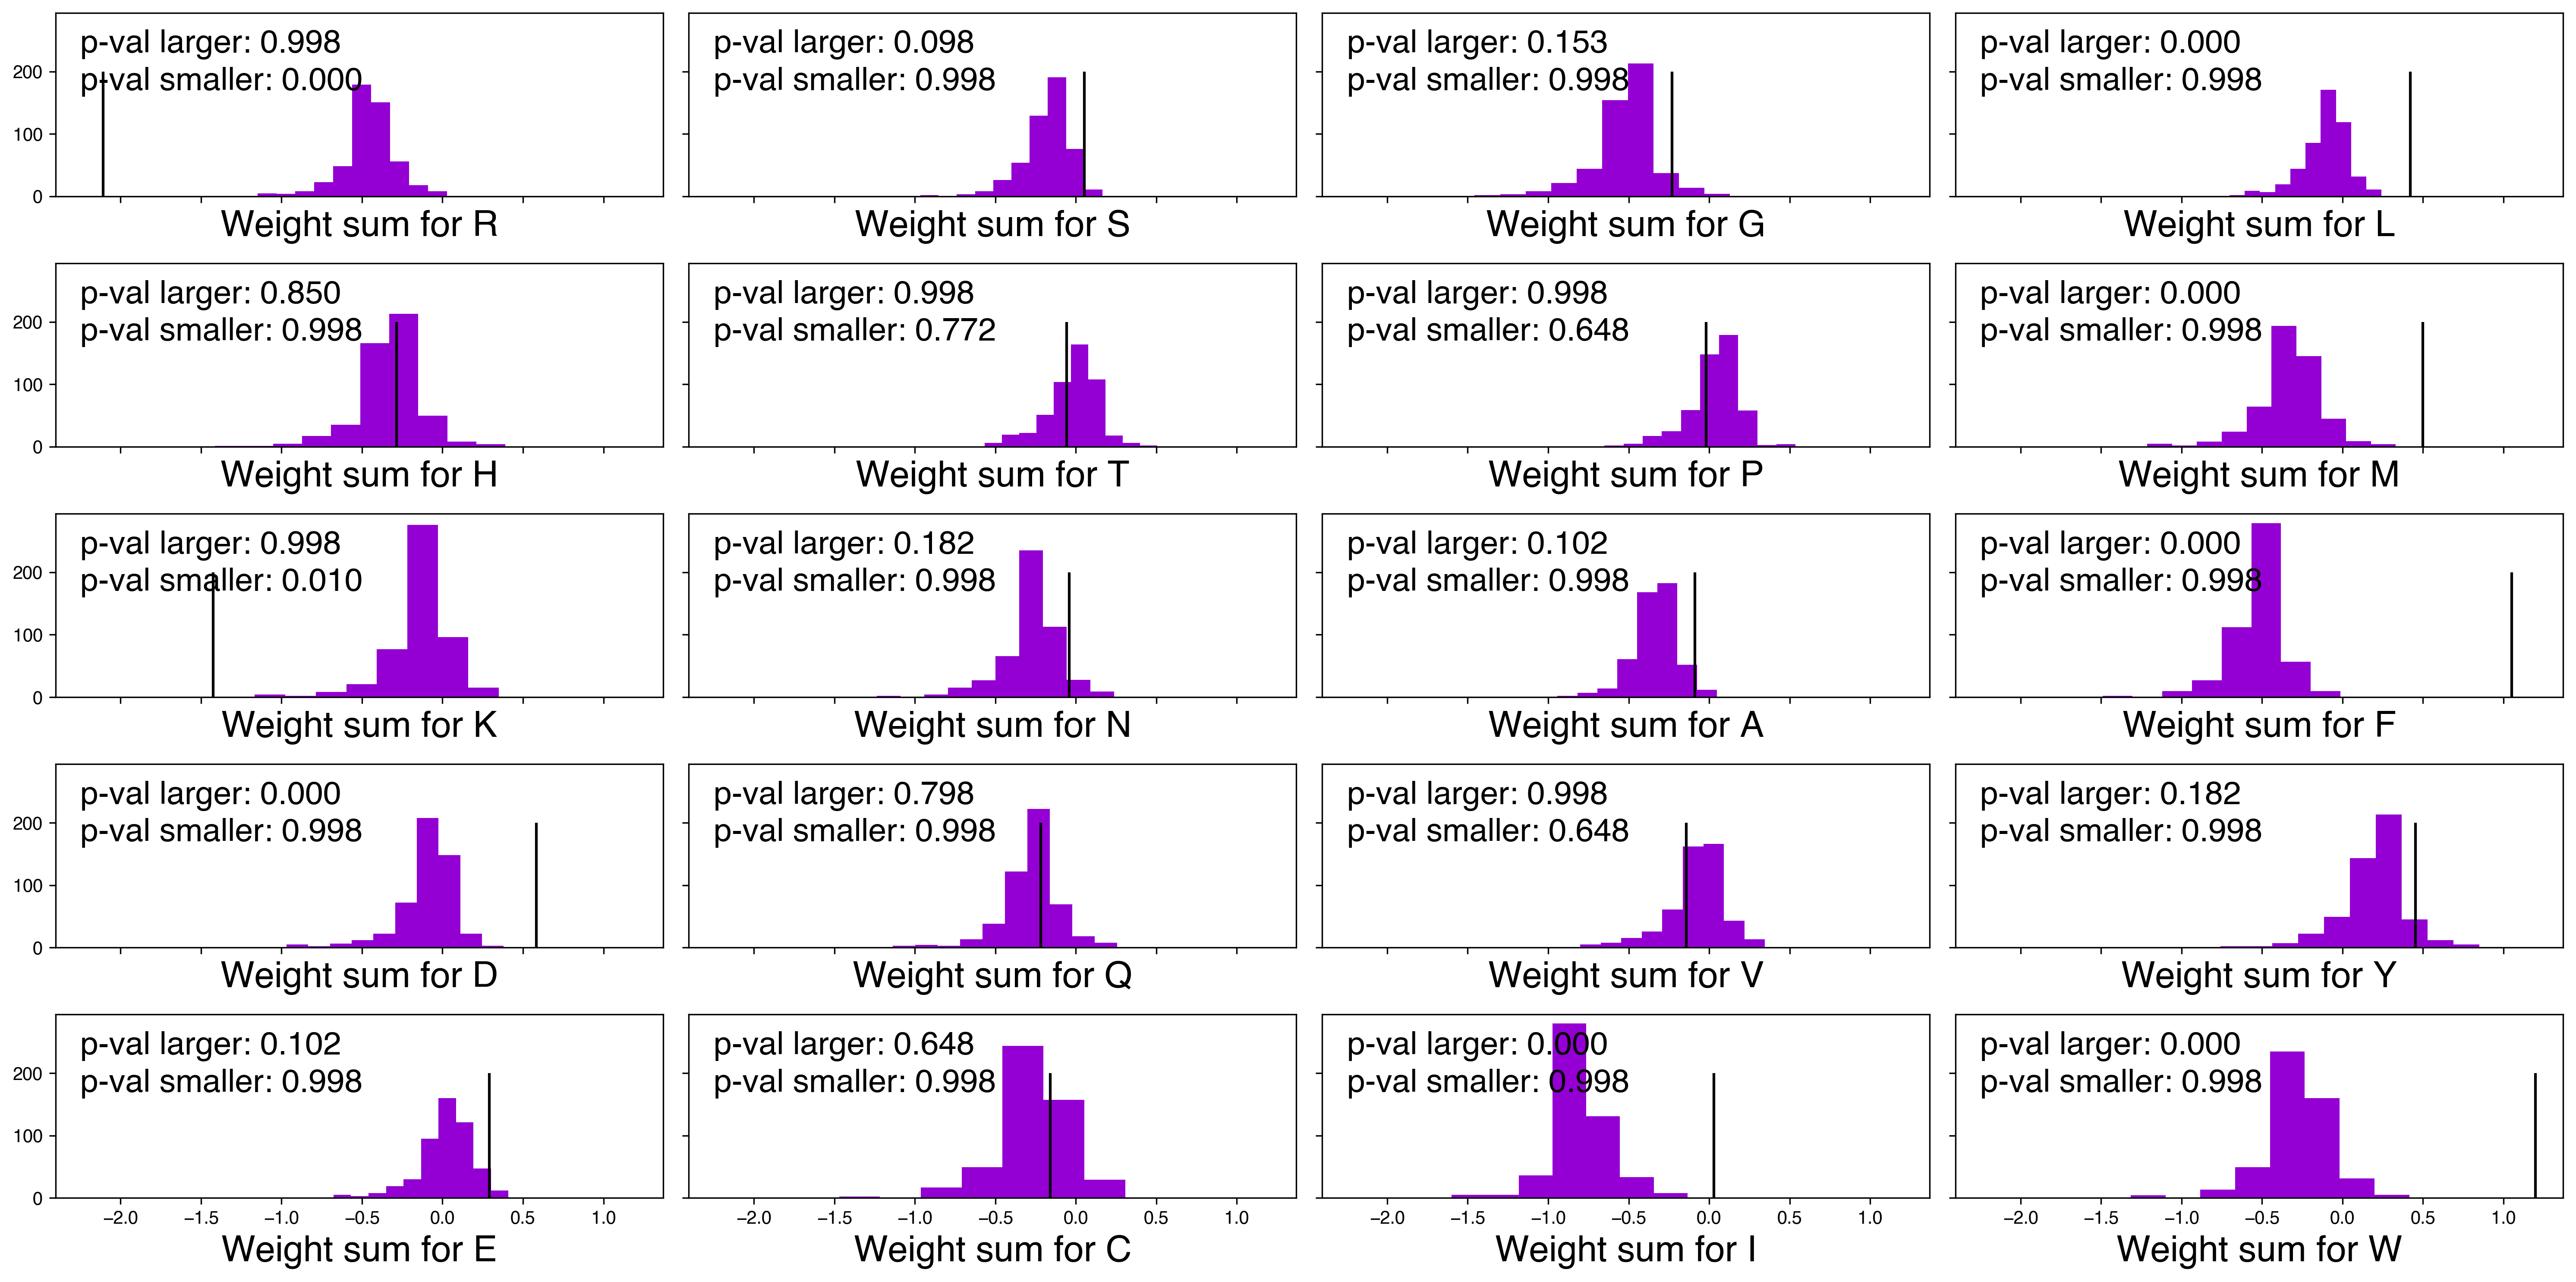

In [293]:
make_histogram(shuffle_test_stat_arr, real_test_stat_arr, adjusted_p_val_conv_sum[:20], adjusted_p_val_conv_sum[20:], 5, 4)
plt.savefig("figures/for_revision/simple_act_k5_conv_sum_pvals.pdf", format='pdf', bbox_inches='tight')
# plt.savefig("figures/for_revision/simple_act_k5_conv_sum_pvals.png", format='png', bbox_inches='tight')


In [101]:
# make_histogram_linear(shuffle_linear_arr, real_linear_arr ,adjusted_p_val_linear, 6, 6)

In [110]:
# make_histogram_conv_weights(shuffle_conv_arr, real_conv_arr, adjusted_p_val_conv)
# plt.savefig("figures/for_revision/simple_act_k5_conv_pvals.pdf", format='pdf', bbox_inches='tight')
# plt.savefig("figures/for_revision/simple_act_k5_conv_pvals.png", format='png', bbox_inches='tight')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


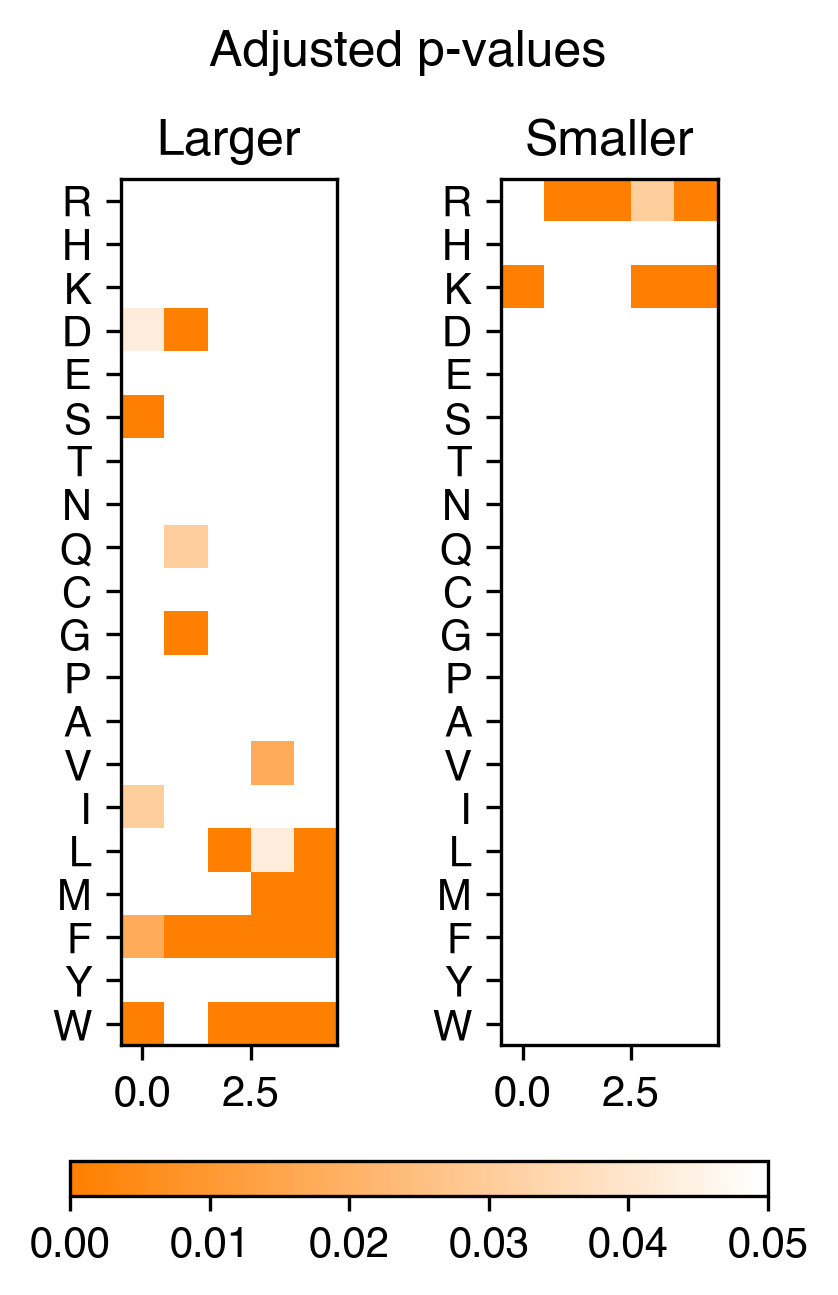

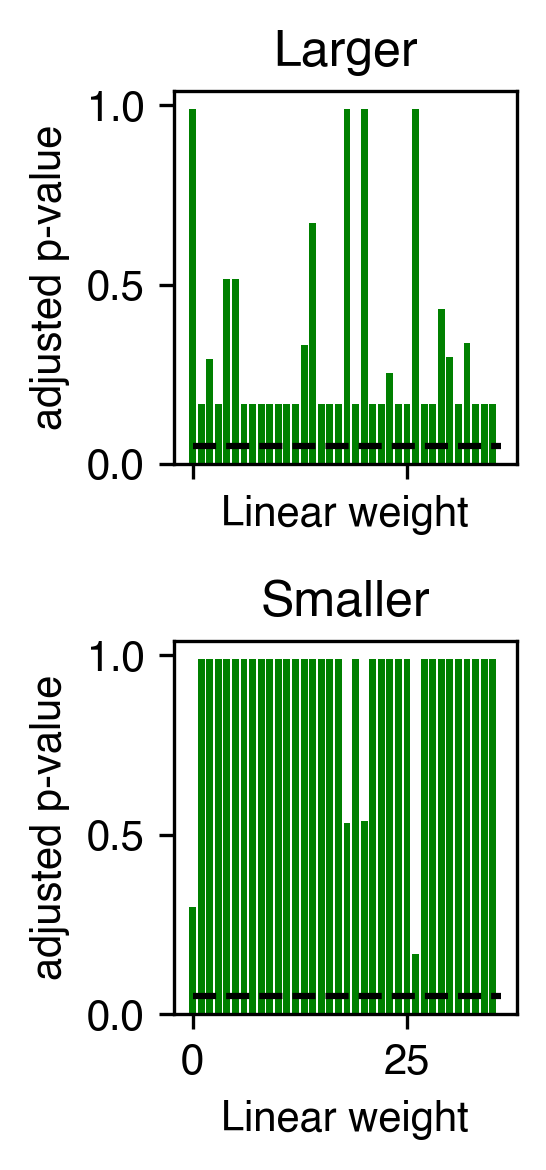

In [294]:
# This is setting up our colors for the plots

# Colors for convolutional filter
colors = [(1, 0.5, 0), (1, 1, 1)]  # Yellow, White
# colors = [(1, 0, 0), (1, 1, 1)]  # Yellow, White
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any

# Colors for AA labels
colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}

fig, axs = plt.subplots(1, 2, figsize=(3, 5))
im = axs[0].imshow(adjusted_p_val_conv_greater.squeeze(0).T, cmap=custom_cmap, vmin=0, vmax=0.05)
axs[0].set_title("Larger")
# axs[0].set_colorbar()

axs[1].imshow(adjusted_p_val_conv_less.squeeze(0).T, cmap=custom_cmap, vmin=0, vmax=0.05)
axs[1].set_title("Smaller")
# axs[1].colorbar()
fig.suptitle("Adjusted p-values")
fig.colorbar(im, ax=axs, orientation="horizontal",pad=0.1)

axs[0].set_yticks(range(0, 20), orig_aa_order)
axs[1].set_yticks(range(0, 20), orig_aa_order)

plt.savefig("figures/for_revision/simple_act_k5_conv_position_pvals.pdf", format='pdf', bbox_inches='tight', dpi=1000)

fig, axs = plt.subplots(2, 1, figsize=(2, 4), sharex=True)
axs[0].bar(x=range(0,36), height=adjusted_p_val_linear_greater, color='green')
axs[0].set_xlabel("Linear weight")
axs[0].set_ylabel("adjusted p-value")
axs[0].hlines(0.05, 0, 36, color='black', linestyles='--')
axs[0].set_title("Larger")

axs[1].bar(x=range(0,36), height=adjusted_p_val_linear_less, color='green')
axs[1].set_xlabel("Linear weight")
axs[1].set_ylabel("adjusted p-value")
axs[1].hlines(0.05, 0, 36, color='black', linestyles='--')
axs[1].set_title("Smaller")

fig.tight_layout()

plt.savefig("figures/for_revision/simple_act_k5_linear_position_pvals.pdf", format='pdf', bbox_inches='tight', dpi=1000)

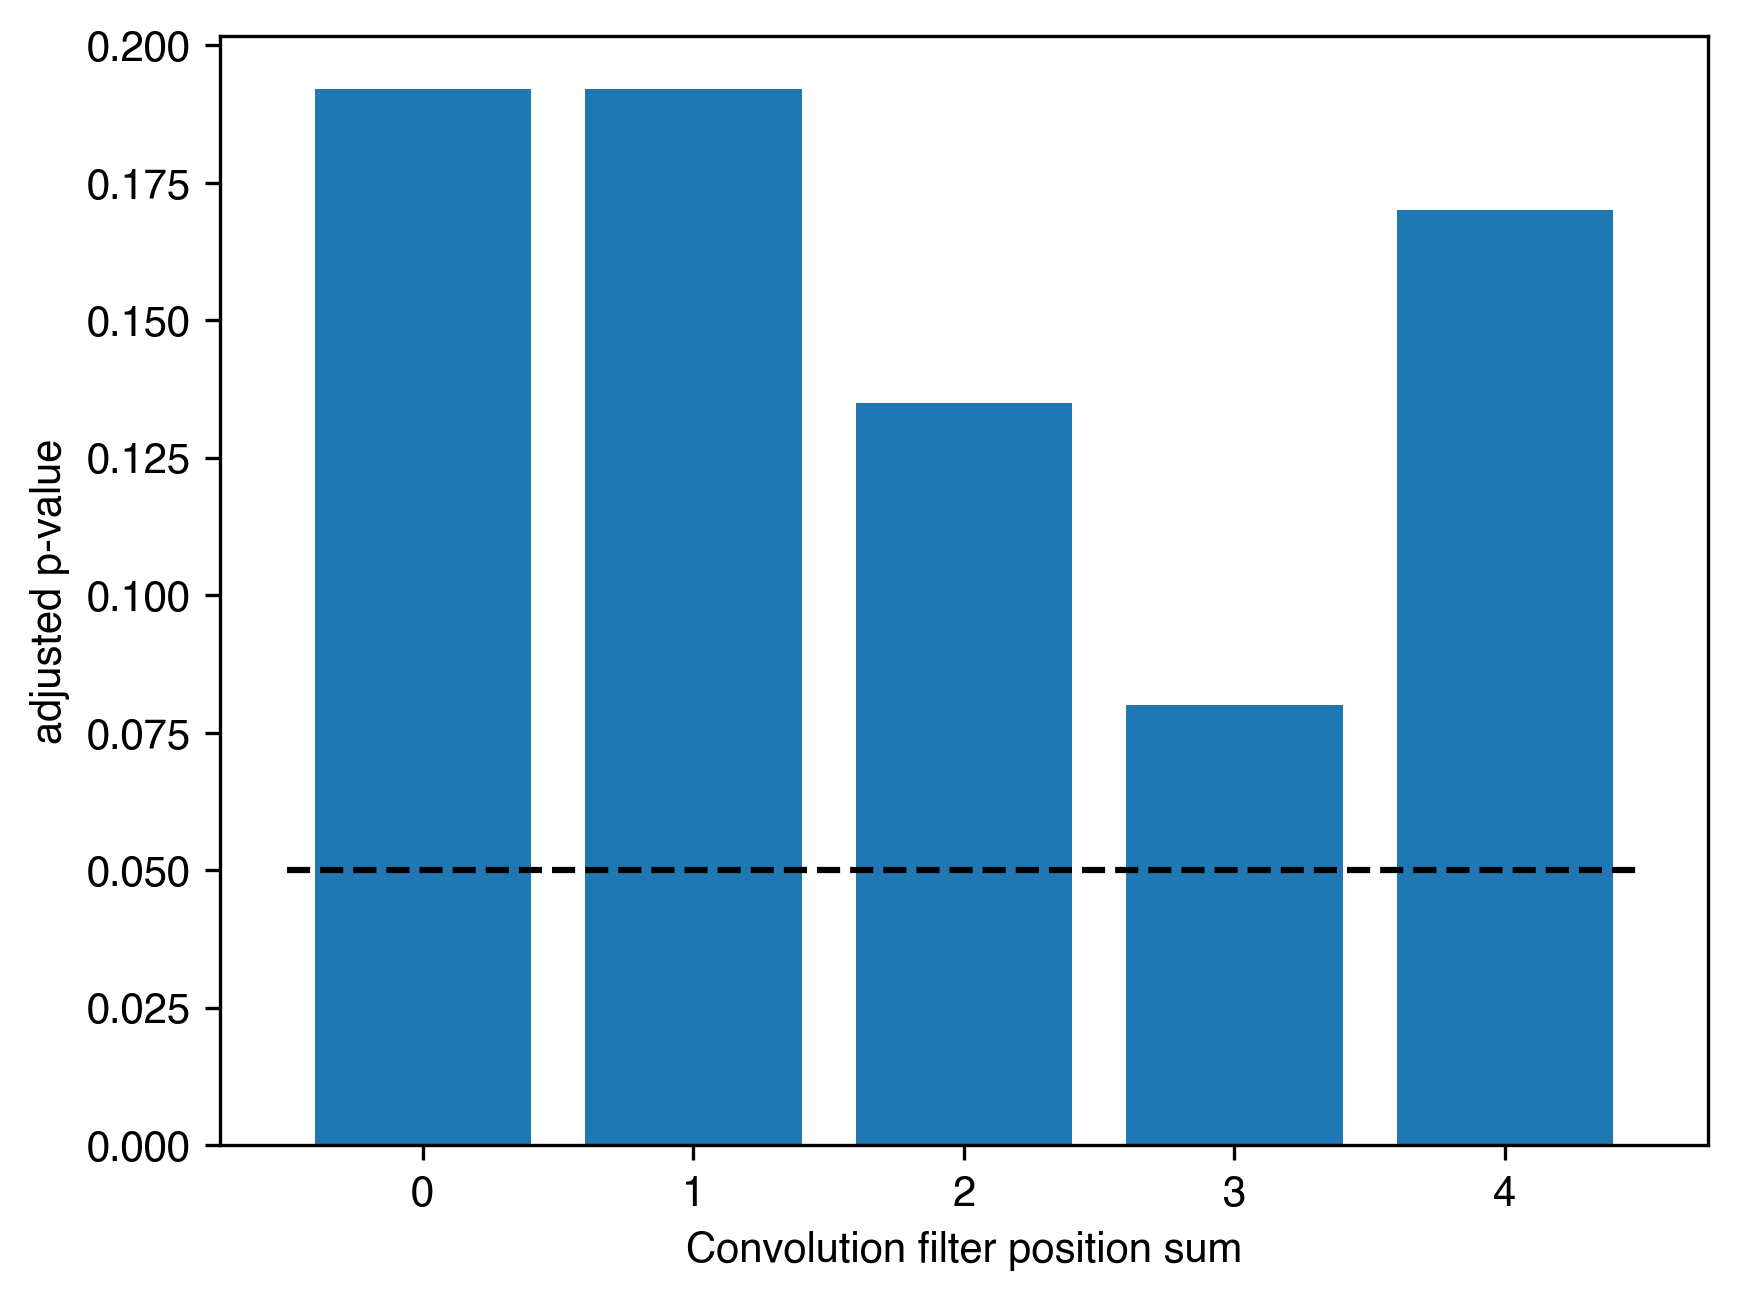

In [62]:
# Look at vertical sums

plt.bar(x=range(5), height=adjusted_p_val_conv_sum_vertical)
plt.xlabel("Convolution filter position sum")
plt.ylabel("adjusted p-value")
plt.hlines(0.05, -0.5, 4.5, color='black', linestyles='--')
plt.show()

# Results for Simple act k=30

In [295]:
# FOR k = 30

simple_act_k30_seed = simple_act_best_model[simple_act_best_model['kernel_size'] == 30].iloc[0]['seed']
simple_act_comparison_subset_30 = shuffled_results_act[(shuffled_results_act['seed'] == simple_act_k30_seed) & (shuffled_results_act['kernel_size'] == 30)].drop_duplicates()
simple_act_comparison_subset_30

# This can be used to change the order in which the AAs appear
orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

# Read in the weights from the various models
real_conv_arr, real_linear_arr = get_weights_array(simple_act_best_model[simple_act_best_model['seed'] == simple_act_k30_seed], k_size=30, num_shuffles=1, num_seeds=1, two_state=False)
# shuffle_conv_arr, shuffle_linear_arr = get_weights_array(simple_act_comparison_subset_30, k_size=30, num_shuffles=500, num_seeds=1, two_state=False)
 
# np.save(f"saved_weights/simple_act_k30_seed{simple_act_k30_seed}_shuffle_conv_arr.npy", shuffle_conv_arr)
# np.save(f"saved_weights/simple_act_k30_seed{simple_act_k30_seed}_shuffle_linear_arr.npy", shuffle_linear_arr)

shuffle_conv_arr = np.load(f"saved_weights/simple_act_k30_seed{simple_act_k30_seed}_shuffle_conv_arr.npy")
shuffle_linear_arr = np.load(f"saved_weights/simple_act_k30_seed{simple_act_k30_seed}_shuffle_linear_arr.npy")

# Calculate the test stat (in this case the weight sum)
shuffle_test_stat_arr = shuffle_conv_arr.sum(axis=2) 
real_test_stat_arr = real_conv_arr.sum(axis=2)

# Calculate p-value for weight sum
print("Conv sum p-values")
p_val_overall_conv_sum = (np.abs(shuffle_test_stat_arr) > np.abs(real_test_stat_arr)).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr.shape[0] + 1)
p_val_greater_conv_sum = (shuffle_test_stat_arr > real_test_stat_arr).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr.shape[0] + 1)
p_val_less_conv_sum = (shuffle_test_stat_arr < real_test_stat_arr).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr.shape[0] + 1)

reject, adjusted_p_val_conv_sum, _, _ = smt.multipletests(np.concatenate([p_val_greater_conv_sum, p_val_less_conv_sum]), alpha=0.05, method='fdr_bh')

for aa, val1, val2 in zip(orig_aa_order, adjusted_p_val_conv_sum[:20], adjusted_p_val_conv_sum[20:]):
    print(aa, ":", val1, val2)

# Calculate p-value for vertical weight sum
print("Conv sum p-values")
p_val_overall_conv_sum_vertical = (np.abs(shuffle_test_stat_vertical_arr) > np.abs(real_test_stat_vertical_arr)).sum(axis=0).sum(axis=0) / shuffle_test_stat_vertical_arr.shape[0]
reject, adjusted_p_val_conv_sum_vertical, _, _ = smt.multipletests(p_val_overall_conv_sum_vertical, alpha=0.05, method='fdr_bh')

# Calculate p-value for linear weights
print("Linear weight p-values")
# p_val_overall_linear = (np.abs(shuffle_linear_arr) > np.abs(real_linear_arr)).sum(axis=0).sum(axis=0) / shuffle_linear_arr.shape[0]
p_val_greater_linear = (shuffle_linear_arr > real_linear_arr).sum(axis=0).sum(axis=0) / shuffle_linear_arr.shape[0]
p_val_less_linear = (shuffle_linear_arr < real_linear_arr).sum(axis=0).sum(axis=0) / shuffle_linear_arr.shape[0]
reject, adjusted_p_val_linear, _, _ = smt.multipletests(np.concatenate([p_val_greater_linear, p_val_less_linear]), alpha=0.05, method='fdr_bh')
adjusted_p_val_linear_greater = adjusted_p_val_linear[:len(p_val_greater_linear)]
adjusted_p_val_linear_less = adjusted_p_val_linear[len(p_val_greater_linear):]

for i, val in enumerate(adjusted_p_val_linear):
    print(i, ":", val)

# Calculate p-value for conv weights individually
print("Conv weight p-values")
# p_val_overall_conv = (np.abs(shuffle_conv_arr) > np.abs(real_conv_arr)).sum(axis=0) / shuffle_conv_arr.shape[0]
p_val_pos_conv = (shuffle_conv_arr > real_conv_arr).sum(axis=0) / shuffle_conv_arr.shape[0]
p_val_neg_conv = (shuffle_conv_arr < real_conv_arr).sum(axis=0) / shuffle_conv_arr.shape[0]
orig_shape = p_val_pos_conv.shape
reject, adjusted_p_val_conv, _, _ = smt.multipletests(np.concatenate([p_val_pos_conv.ravel(), p_val_neg_conv.ravel()]), alpha=0.05, method='fdr_bh')

adjusted_p_val_conv_greater = adjusted_p_val_conv[:(p_val_neg_conv.size)].reshape(orig_shape)
adjusted_p_val_conv_less = adjusted_p_val_conv[(p_val_neg_conv.size):].reshape(orig_shape)

100%|██████████| 1/1 [00:00<00:00, 389.70it/s]


Conv sum p-values
R : 0.998003992015968 0.0
H : 0.998003992015968 0.05806568680820177
K : 0.998003992015968 0.0
D : 0.0 0.998003992015968
E : 0.0 0.998003992015968
S : 0.059880239520958084 0.998003992015968
T : 0.08598188238906801 0.998003992015968
N : 0.3725881570192947 0.998003992015968
Q : 0.998003992015968 0.27239638370318187
C : 0.998003992015968 0.09124607927003137
G : 0.998003992015968 0.21290751829673984
P : 0.05806568680820177 0.998003992015968
A : 0.27239638370318187 0.998003992015968
V : 0.7984031936127745 0.998003992015968
I : 0.961885752304914 0.961885752304914
L : 0.0 0.998003992015968
M : 0.0 0.998003992015968
F : 0.0 0.998003992015968
Y : 0.0 0.998003992015968
W : 0.0 0.998003992015968
Conv sum p-values
Linear weight p-values
0 : 0.0616
1 : 0.05377777777777777
2 : 0.0
3 : 1.0
4 : 0.0264
5 : 0.03142857142857143
6 : 0.022
7 : 1.0
8 : 1.0
9 : 0.022
10 : 0.03142857142857143
11 : 1.0
12 : 1.0
13 : 1.0
14 : 0.468
15 : 1.0
16 : 1.0
17 : 1.0
18 : 0.0
19 : 0.05377777777777777
20

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


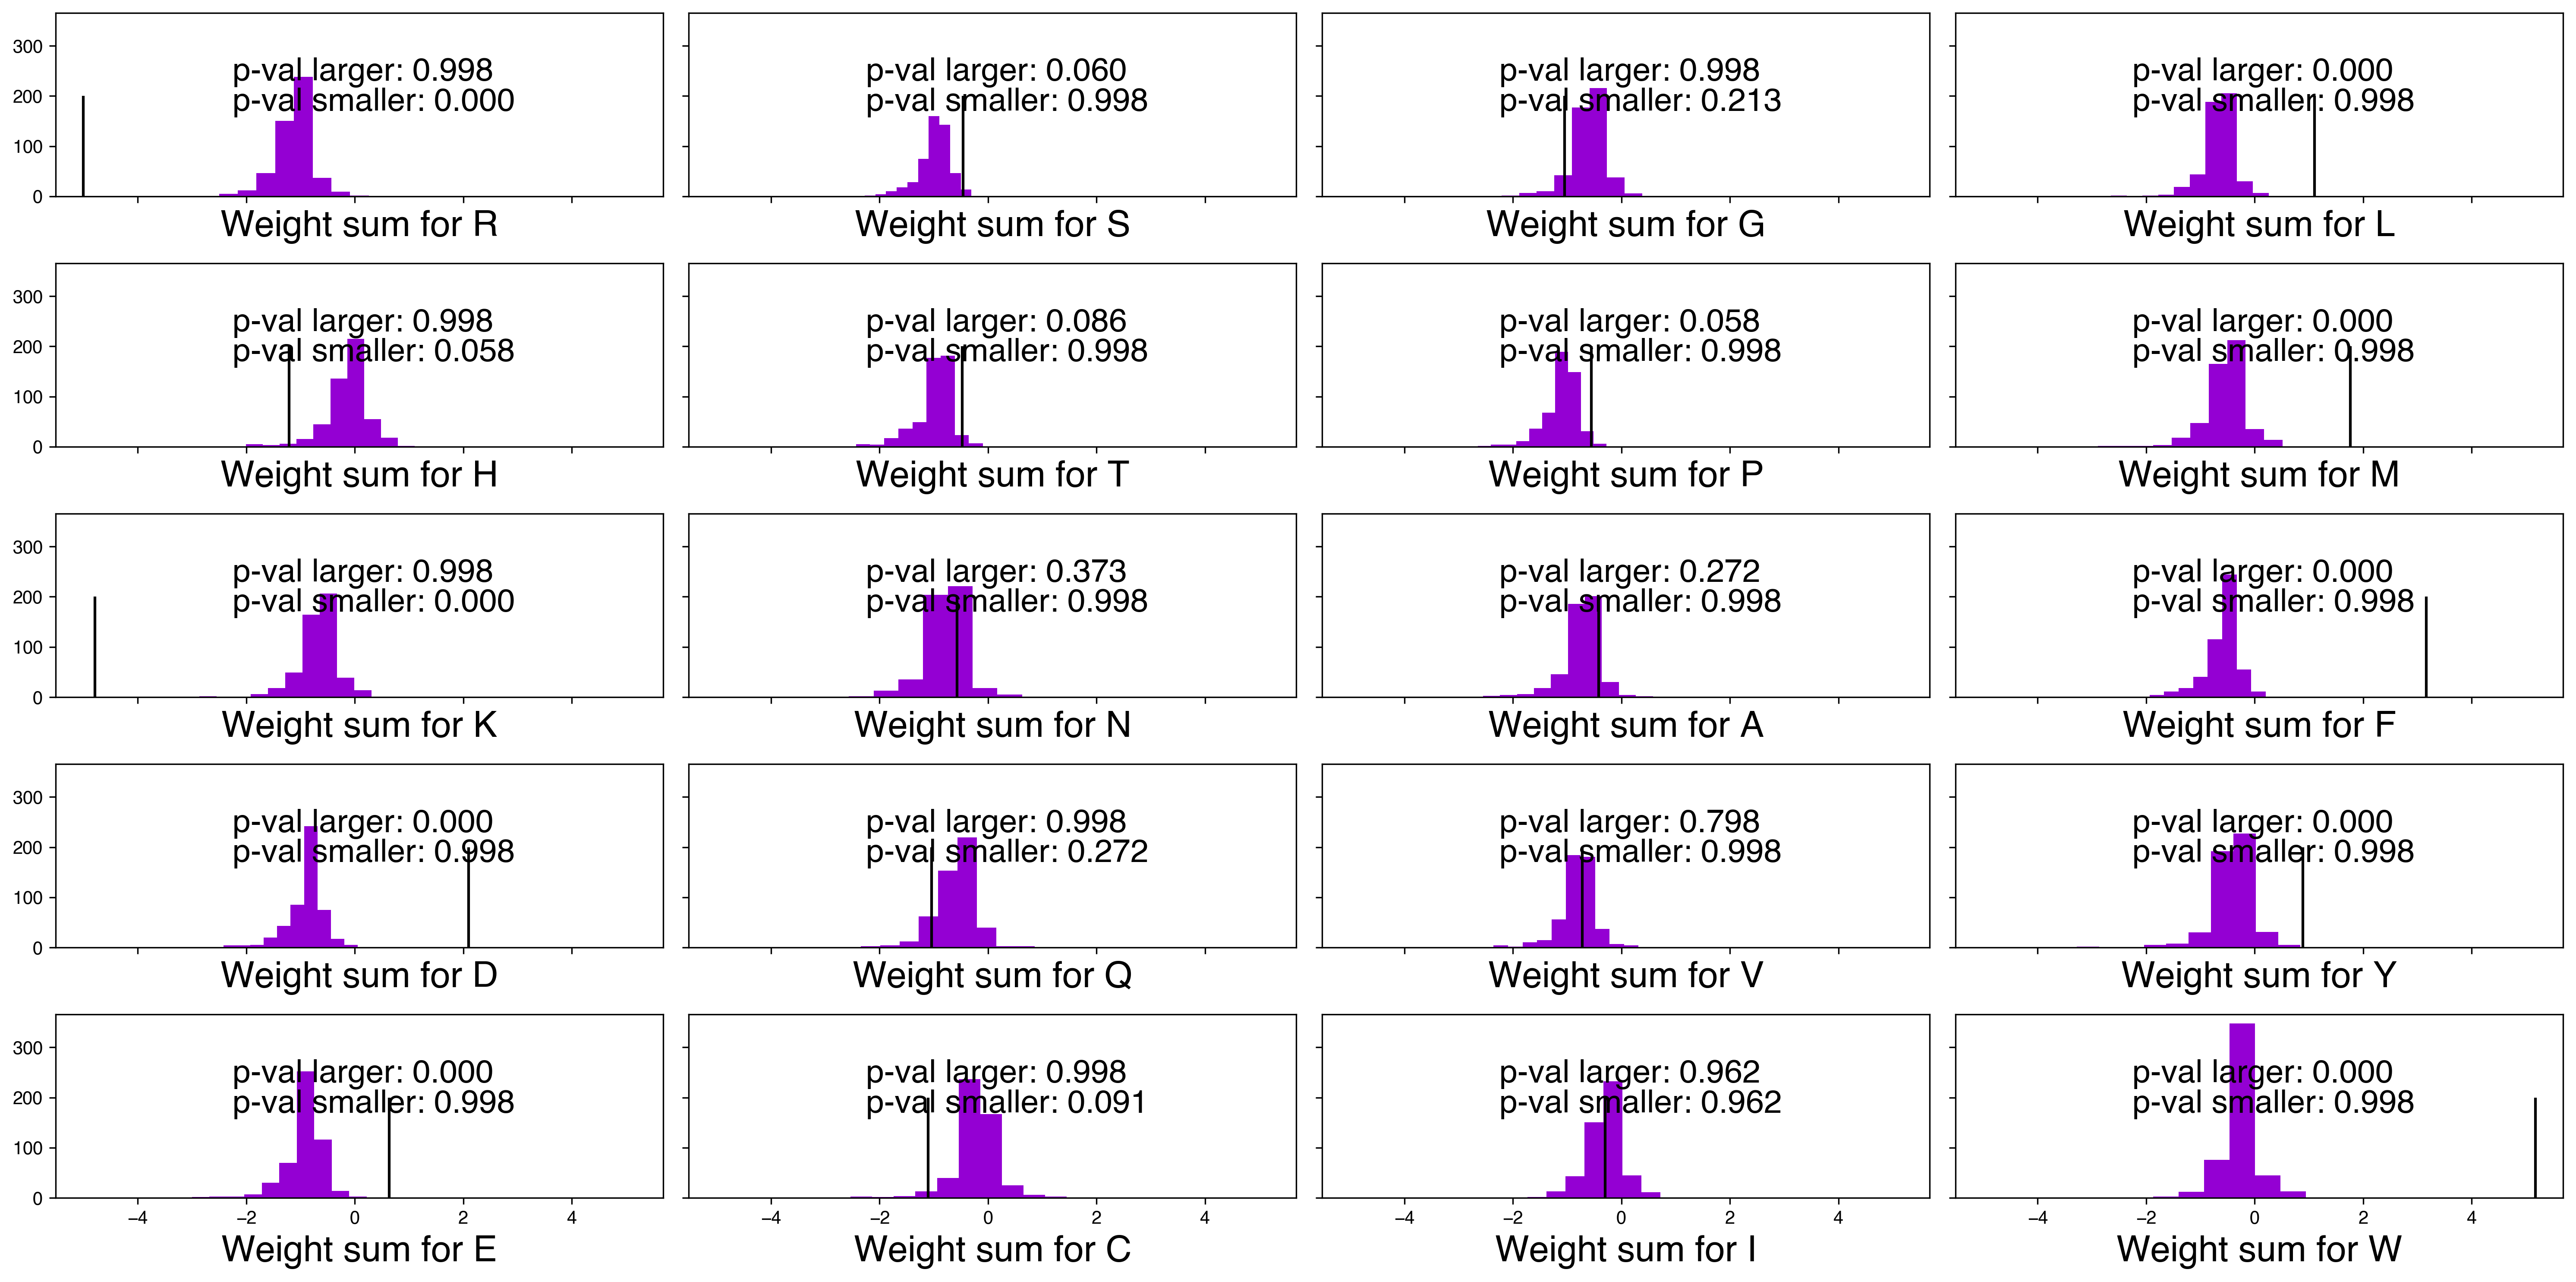

In [298]:
make_histogram(shuffle_test_stat_arr, real_test_stat_arr, adjusted_p_val_conv_sum[:20], adjusted_p_val_conv_sum[20:], 5, 4)
plt.savefig("figures/for_revision/simple_act_k30_conv_sum_pvals.pdf", format='pdf', bbox_inches='tight')
# plt.savefig("figures/for_revision/simple_act_k5_conv_sum_pvals.png", format='png', bbox_inches='tight')


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


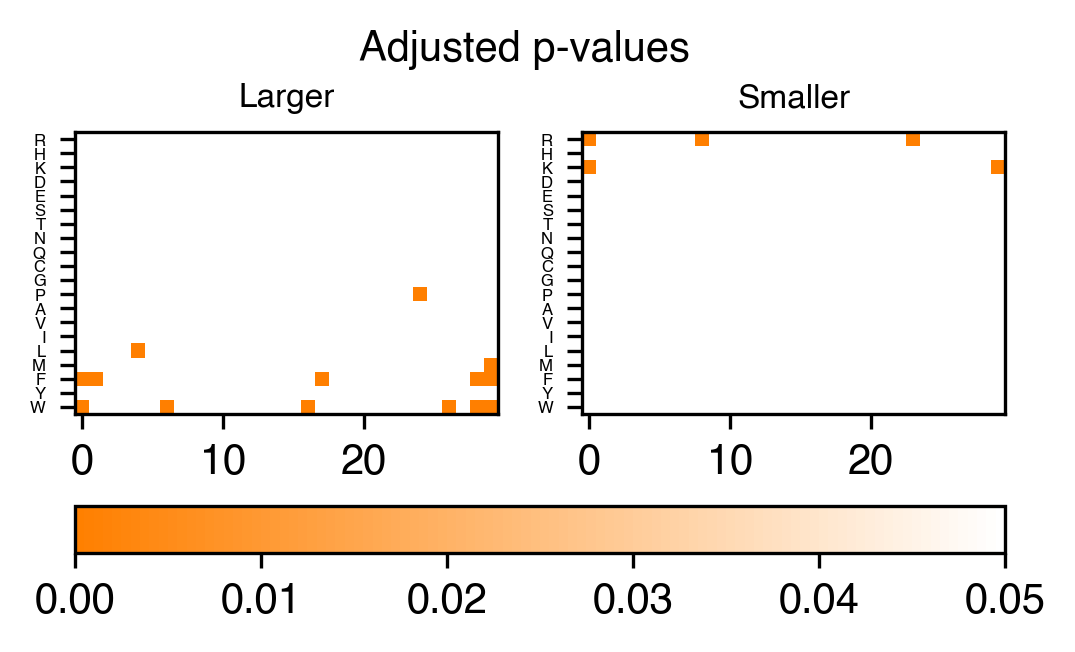

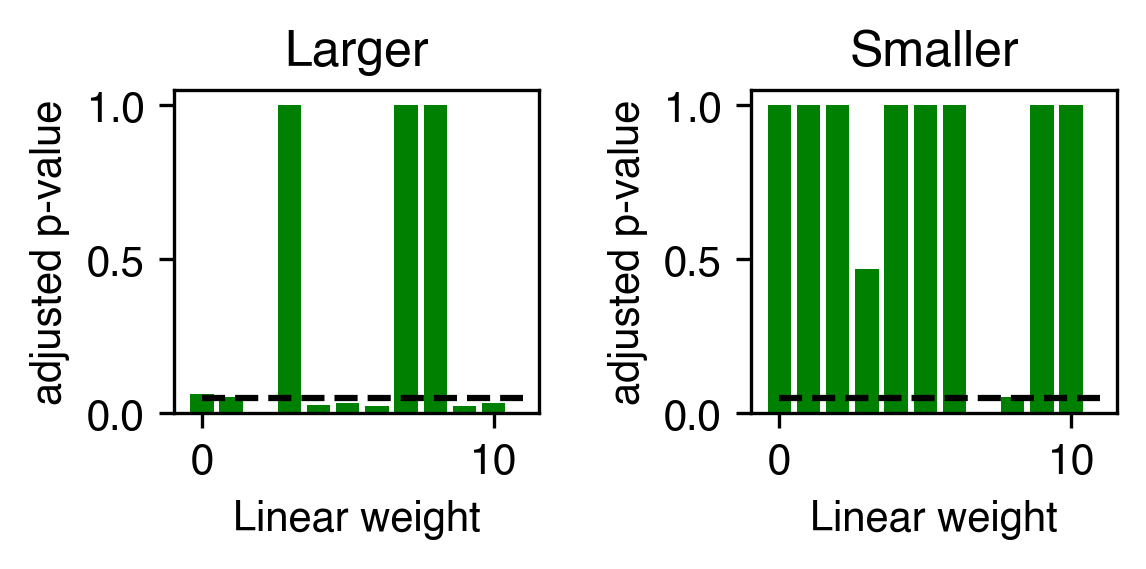

In [302]:
# This is setting up our colors for the plots

# Colors for convolutional filter
colors = [(1, 0.5, 0), (1, 1, 1)]  # Yellow, White
# colors = [(1, 0, 0), (1, 1, 1)]  # Yellow, White
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any

# Colors for AA labels
colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}

fig, axs = plt.subplots(1, 2, figsize=(4, 2))
im = axs[0].imshow(adjusted_p_val_conv_greater.squeeze(0).T, cmap=custom_cmap, vmin=0, vmax=0.05)
axs[0].set_title("Larger", fontsize=8)
# axs[0].set_colorbar()

axs[1].imshow(adjusted_p_val_conv_less.squeeze(0).T, cmap=custom_cmap, vmin=0, vmax=0.05)
axs[1].set_title("Smaller", fontsize=8)
# axs[1].colorbar()
fig.suptitle("Adjusted p-values", fontsize=10, y=1.02)

axs[0].set_yticks(range(0, 20), orig_aa_order, fontsize=4)
axs[1].set_yticks(range(0, 20), orig_aa_order, fontsize=4)

fig.colorbar(im, ax=axs, orientation="horizontal",pad=0.2)

plt.savefig("figures/for_revision/simple_act_k30_conv_position_pvals.pdf", format='pdf', bbox_inches='tight', dpi=1000)

fig, axs = plt.subplots(1, 2, figsize=(4, 2), sharex=True)
axs[0].bar(x=range(0,11), height=adjusted_p_val_linear_greater, color='green')
axs[0].set_xlabel("Linear weight")
axs[0].set_ylabel("adjusted p-value")
axs[0].hlines(0.05, 0, 11, color='black', linestyles='--')
axs[0].set_title("Larger")

axs[1].bar(x=range(11), height=adjusted_p_val_linear_less, color='green')
axs[1].set_xlabel("Linear weight")
axs[1].set_ylabel("adjusted p-value")
axs[1].hlines(0.05, 0, 11, color='black', linestyles='--')
axs[1].set_title("Smaller")

fig.tight_layout()

plt.savefig("figures/for_revision/simple_act_k30_linear_position_pvals.pdf", format='pdf', bbox_inches='tight', dpi=1000)

# Results for simple abund k=20

In [304]:
# For simple act model - get size and seed to compare, and then get corresponding shuffle results
simple_abund_best_model = get_best_model(simple_abund_model_results, spearman_abund=True, pearson_abund=True, spearman_act=False, pearson_act=False)
simple_abund_seed = simple_abund_best_model.loc[0, 'seed']
simple_abund_k = simple_abund_best_model.loc[0, 'kernel_size']

# comparison_subset = shuffled_results_act[(shuffled_results_act['seed'] == 3297031) & (shuffled_results_act['kernel_size'] == 5)].drop_duplicates()
simple_abund_comparison_subset = shuffled_results_abund[(shuffled_results_abund['seed'] == simple_abund_seed) & (shuffled_results_abund['kernel_size'] == simple_abund_k)].drop_duplicates()
simple_abund_comparison_subset

,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,spearman_abund_val,...,pearson_act_val,pearson_abund_train,pearson_act_train,K1_negative,K2_negative,abund_negative,relu,total_params,shuffle_number,seed
17499,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,20,NaN,NaN,0.5,NaN,0.006954,NaN,0.120898,...,NaN,0.116873,NaN,NaN,NaN,NaN,NaN,423,0,830654943
17500,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,20,NaN,NaN,0.5,NaN,-0.012251,NaN,-0.042747,...,NaN,0.153340,NaN,NaN,NaN,NaN,NaN,423,1,830654943
17501,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,20,NaN,NaN,0.5,NaN,-0.045019,NaN,-0.002833,...,NaN,0.160889,NaN,NaN,NaN,NaN,NaN,423,2,830654943
17502,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,20,NaN,NaN,0.5,NaN,-0.032162,NaN,-0.049115,...,NaN,0.139025,NaN,NaN,NaN,NaN,NaN,423,3,830654943
17503,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,20,NaN,NaN,0.5,NaN,-0.005497,NaN,-0.019374,...,NaN,0.129576,NaN,NaN,NaN,NaN,NaN,423,4,830654943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18694,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,20,NaN,NaN,0.5,NaN,0.027051,NaN,0.040108,...,NaN,0.124101,NaN,NaN,NaN,NaN,NaN,423,495,830654943
18695,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,20,NaN,NaN,0.5,NaN,-0.005009,NaN,0.059066,...,NaN,0.043535,NaN,NaN,NaN,NaN,NaN,423,496,830654943
18696,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,20,NaN,NaN,0.5,NaN,0.018075,NaN,0.012825,...,NaN,0.115266,NaN,NaN,NaN,NaN,NaN,423,497,830654943
18697,../../model_data/simple_abundmodel_b10_e200_L0...,simple_abund,20,NaN,NaN,0.5,NaN,0.022460,NaN,-0.000900,...,NaN,0.079251,NaN,NaN,NaN,NaN,NaN,423,498,830654943


In [309]:
# This can be used to change the order in which the AAs appear
orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

# Read in the weights from the various models
real_conv_arr, real_linear_arr = get_weights_array(simple_abund_best_model[simple_abund_best_model['seed'] == simple_abund_seed], k_size=simple_abund_k, num_shuffles=1, num_seeds=1, two_state=False)
# shuffle_conv_arr, shuffle_linear_arr = get_weights_array(simple_abund_comparison_subset, k_size=simple_abund_k, num_shuffles=500, num_seeds=1, two_state=False)
 
# np.save(f"saved_weights/simple_abund_k{simple_abund_k}_seed{simple_abund_seed}_shuffle_conv_arr.npy", shuffle_conv_arr)
# np.save(f"saved_weights/simple_abund_k{simple_abund_k}_seed{simple_abund_seed}_shuffle_linear_arr.npy", shuffle_linear_arr)

shuffle_conv_arr = np.load(f"saved_weights/simple_abund_k{simple_abund_k}_seed{simple_abund_seed}_shuffle_conv_arr.npy")
shuffle_linear_arr = np.load(f"saved_weights/simple_abund_k{simple_abund_k}_seed{simple_abund_seed}_shuffle_linear_arr.npy")

# Calculate the test stat (in this case the weight sum)
shuffle_test_stat_arr = shuffle_conv_arr.sum(axis=2) 
real_test_stat_arr = real_conv_arr.sum(axis=2)


# Calculate the test stat (in this case the position sum)
shuffle_test_stat_vertical_arr = np.abs(shuffle_conv_arr).sum(axis=3) 
real_test_stat_vertical_arr = np.abs(real_conv_arr).sum(axis=3)

# Calculate p-value for weight sum
print("Conv sum p-values")
p_val_overall_conv_sum = (np.abs(shuffle_test_stat_arr) > np.abs(real_test_stat_arr)).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr.shape[0] + 1)
p_val_greater_conv_sum = (shuffle_test_stat_arr > real_test_stat_arr).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr.shape[0] + 1)
p_val_less_conv_sum = (shuffle_test_stat_arr < real_test_stat_arr).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr.shape[0] + 1)

reject, adjusted_p_val_conv_sum, _, _ = smt.multipletests(np.concatenate([p_val_greater_conv_sum, p_val_less_conv_sum]), alpha=0.05, method='fdr_bh')

for aa, val1, val2 in zip(orig_aa_order, adjusted_p_val_conv_sum[:20], adjusted_p_val_conv_sum[20:]):
    print(aa, ":", val1, val2)

# Calculate p-value for vertical weight sum
print("Conv sum p-values")
p_val_overall_conv_sum_vertical = (np.abs(shuffle_test_stat_vertical_arr) > np.abs(real_test_stat_vertical_arr)).sum(axis=0).sum(axis=0) / shuffle_test_stat_vertical_arr.shape[0]
reject, adjusted_p_val_conv_sum_vertical, _, _ = smt.multipletests(p_val_overall_conv_sum_vertical, alpha=0.05, method='fdr_bh')

# Calculate p-value for linear weights
print("Linear weight p-values")
# p_val_overall_linear = (np.abs(shuffle_linear_arr) > np.abs(real_linear_arr)).sum(axis=0).sum(axis=0) / shuffle_linear_arr.shape[0]
p_val_greater_linear = (shuffle_linear_arr > real_linear_arr).sum(axis=0).sum(axis=0) / shuffle_linear_arr.shape[0]
p_val_less_linear = (shuffle_linear_arr < real_linear_arr).sum(axis=0).sum(axis=0) / shuffle_linear_arr.shape[0]
reject, adjusted_p_val_linear, _, _ = smt.multipletests(np.concatenate([p_val_greater_linear, p_val_less_linear]), alpha=0.05, method='fdr_bh')
adjusted_p_val_linear_greater = adjusted_p_val_linear[:len(p_val_greater_linear)]
adjusted_p_val_linear_less = adjusted_p_val_linear[len(p_val_greater_linear):]

for i, val in enumerate(adjusted_p_val_linear):
    print(i, ":", val)

# Calculate p-value for conv weights individually
print("Conv weight p-values")
# p_val_overall_conv = (np.abs(shuffle_conv_arr) > np.abs(real_conv_arr)).sum(axis=0) / shuffle_conv_arr.shape[0]
p_val_pos_conv = (shuffle_conv_arr > real_conv_arr).sum(axis=0) / shuffle_conv_arr.shape[0]
p_val_neg_conv = (shuffle_conv_arr < real_conv_arr).sum(axis=0) / shuffle_conv_arr.shape[0]
orig_shape = p_val_pos_conv.shape
reject, adjusted_p_val_conv, _, _ = smt.multipletests(np.concatenate([p_val_pos_conv.ravel(), p_val_neg_conv.ravel()]), alpha=0.05, method='fdr_bh')

adjusted_p_val_conv_greater = adjusted_p_val_conv[:(p_val_neg_conv.size)].reshape(orig_shape)
adjusted_p_val_conv_less = adjusted_p_val_conv[(p_val_neg_conv.size):].reshape(orig_shape)

100%|██████████| 1/1 [00:00<00:00, 604.98it/s]

Conv sum p-values
R : 0.0 0.998003992015968
H : 0.008404244143292362 0.998003992015968
K : 0.0 0.998003992015968
D : 0.0 0.998003992015968
E : 0.0 0.998003992015968
S : 0.0 0.998003992015968
T : 0.0 0.998003992015968
N : 0.0 0.998003992015968
Q : 0.0 0.998003992015968
C : 0.998003992015968 0.0
G : 0.0 0.998003992015968
P : 0.0 0.998003992015968
A : 0.19161676646706588 0.998003992015968
V : 0.998003992015968 0.0
I : 0.998003992015968 0.0
L : 0.998003992015968 0.0
M : 0.998003992015968 0.008404244143292362
F : 0.998003992015968 0.0
Y : 0.998003992015968 0.00469648937419279
W : 0.998003992015968 0.0
Conv sum p-values
Linear weight p-values
0 : 1.0
1 : 1.0
2 : 0.26492307692307693
3 : 0.6587368421052632
4 : 1.0
5 : 0.33075000000000004
6 : 1.0
7 : 0.44333333333333336
8 : 1.0
9 : 1.0
10 : 0.952
11 : 1.0
12 : 1.0
13 : 1.0
14 : 1.0
15 : 1.0
16 : 0.28800000000000003
17 : 0.07350000000000001
18 : 1.0
19 : 0.014
20 : 1.0
21 : 0.014
22 : 0.16036363636363637
23 : 1.0
24 : 1.0
25 : 0.0
26 : 1.0
27 : 

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


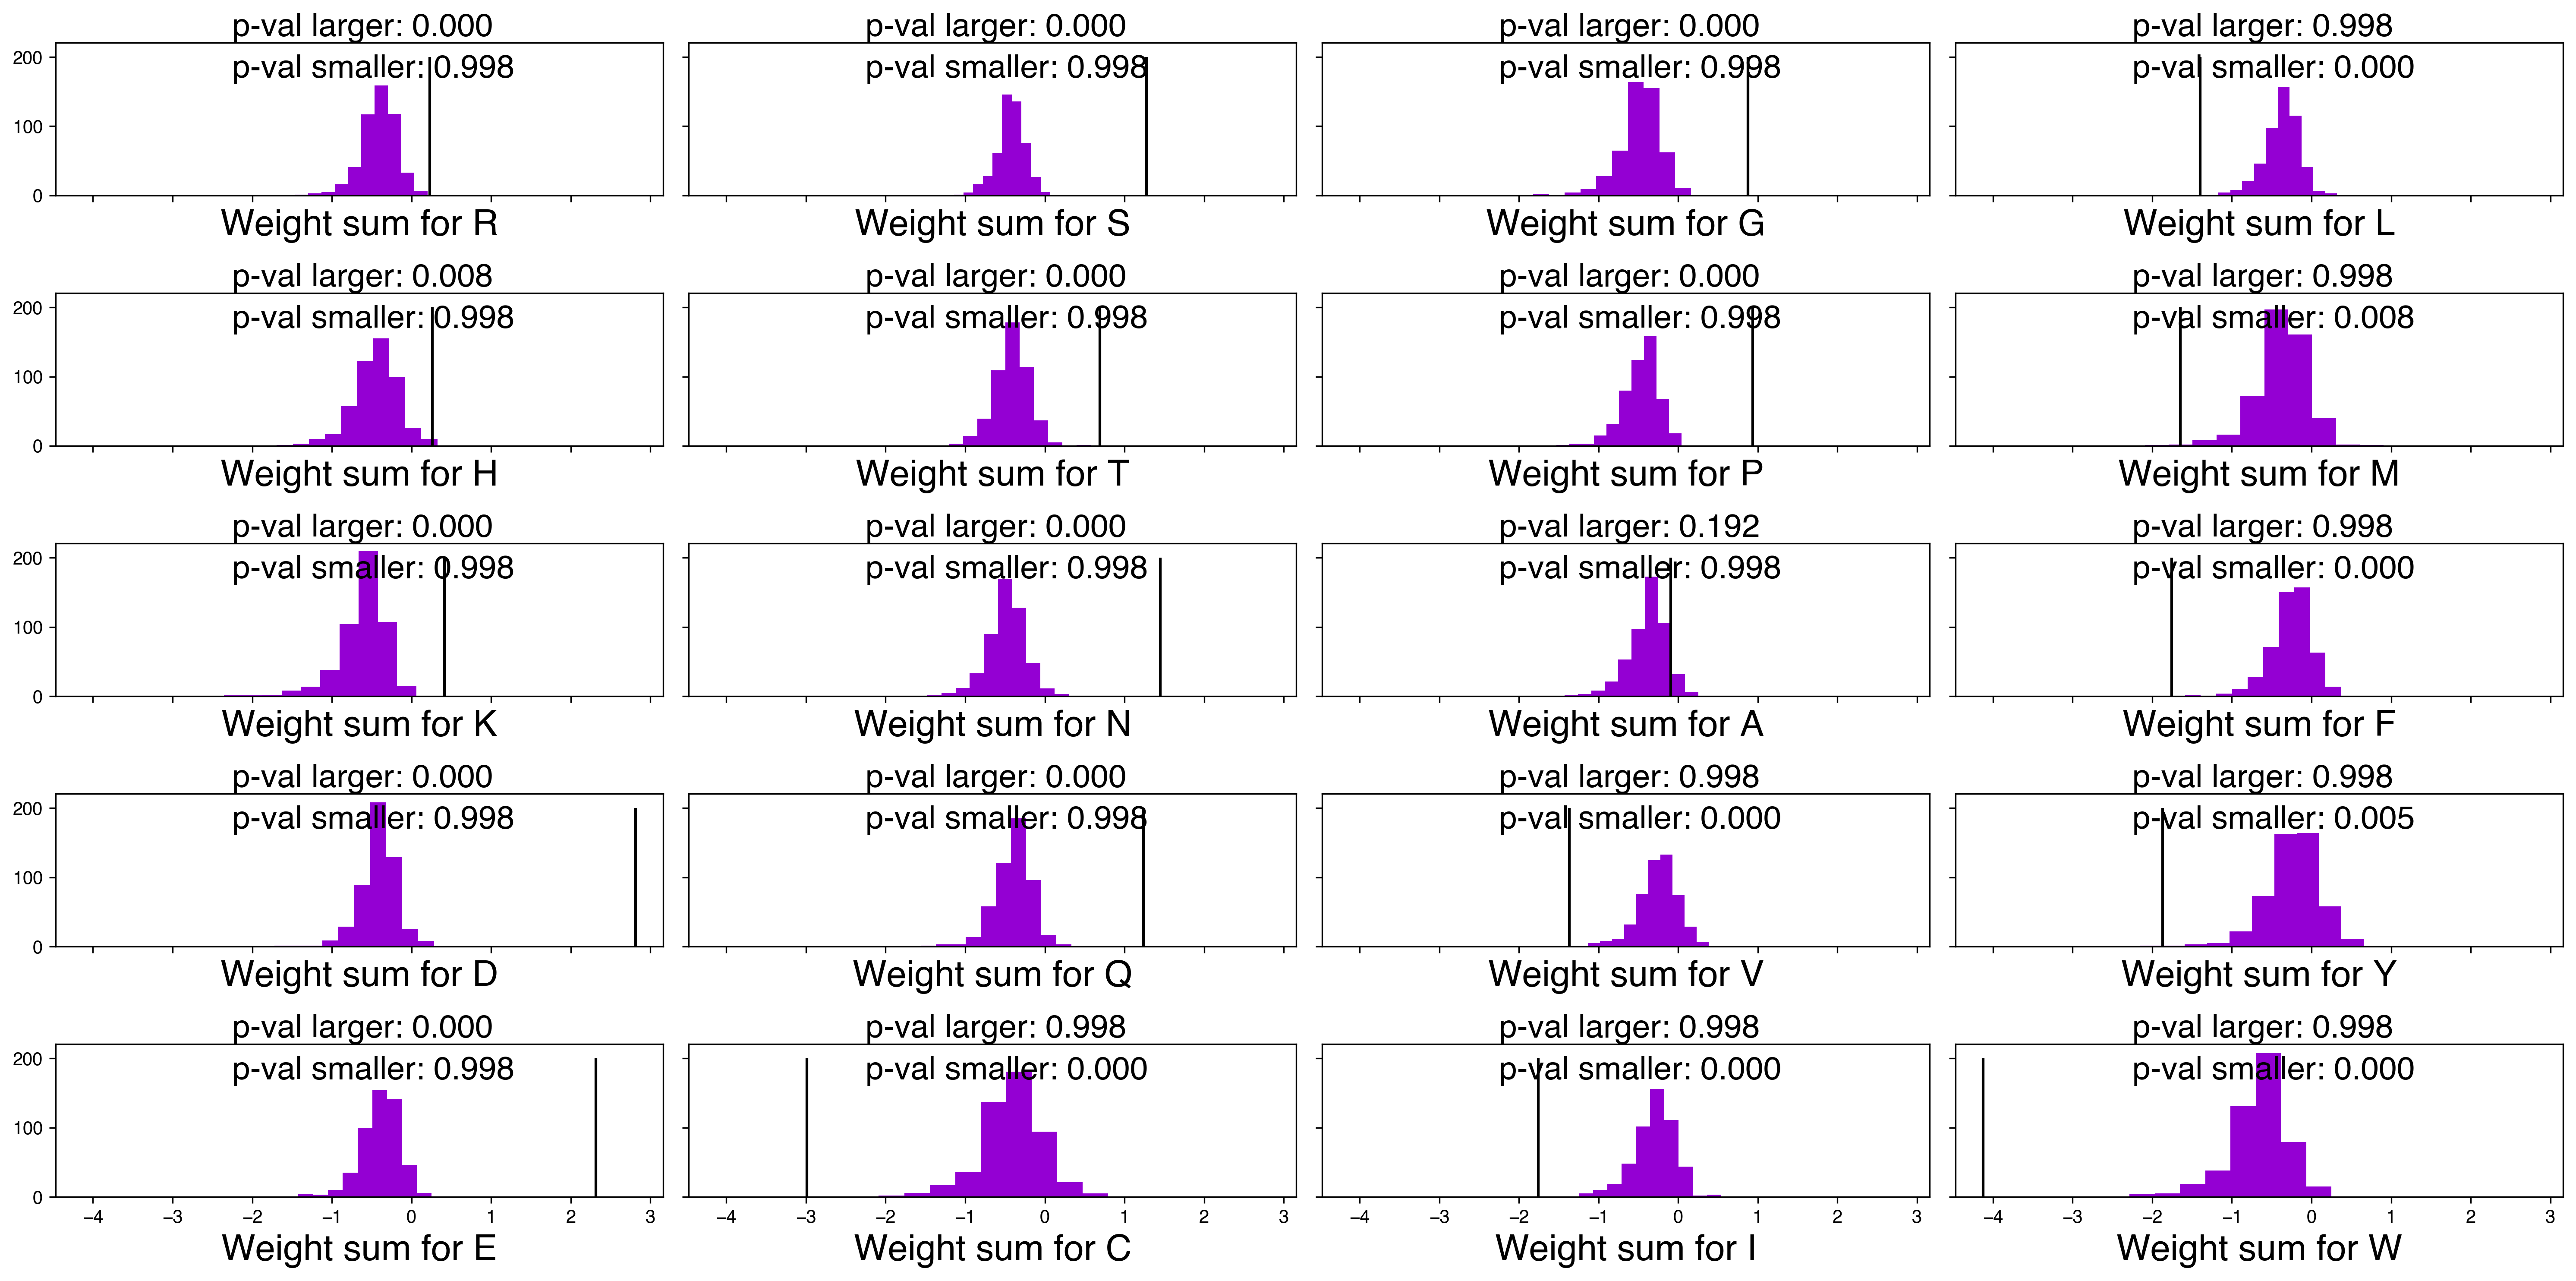

In [ ]:
make_histogram(shuffle_test_stat_arr, real_test_stat_arr, adjusted_p_val_conv_sum[:20], adjusted_p_val_conv_sum[20:], 5, 4)

plt.savefig("figures/for_revision/simple_abund_k20_conv_sum_pvals.pdf", format='pdf', bbox_inches='tight')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


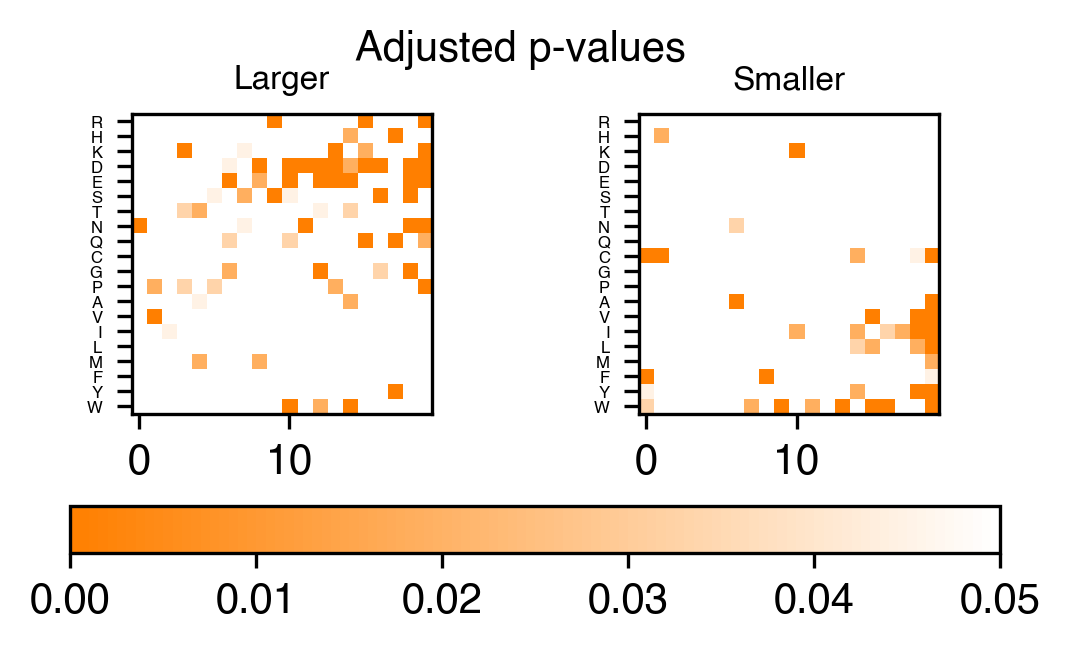

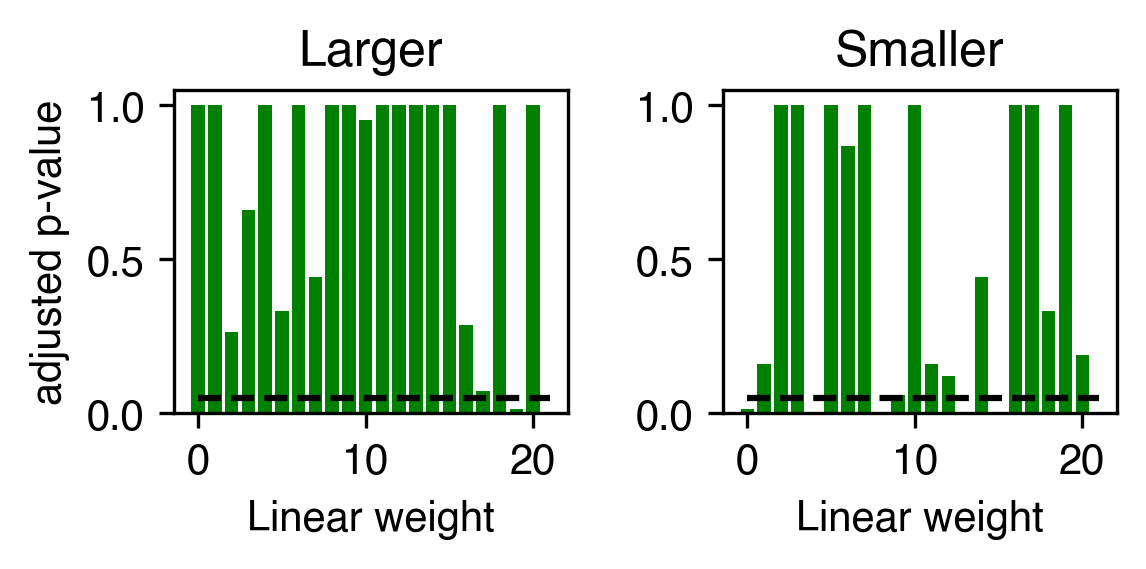

In [312]:
# This is setting up our colors for the plots

# Colors for convolutional filter 
colors = [(1, 0.5, 0), (1, 1, 1)]  # Yellow, White
# colors = [(1, 0, 0), (1, 1, 1)]  # Yellow, White
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any

# Colors for AA labels
colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}

fig, axs = plt.subplots(1, 2, figsize=(4, 2))
im = axs[0].imshow(adjusted_p_val_conv_greater.squeeze(0).T, cmap=custom_cmap, vmin=0, vmax=0.05)
axs[0].set_title("Larger", fontsize=8)
# axs[0].set_colorbar()

axs[1].imshow(adjusted_p_val_conv_less.squeeze(0).T, cmap=custom_cmap, vmin=0, vmax=0.05)
axs[1].set_title("Smaller", fontsize=8)
# axs[1].colorbar()
fig.suptitle("Adjusted p-values", fontsize=10, y=1.02)

axs[0].set_yticks(range(0, 20), orig_aa_order, fontsize=4)
axs[1].set_yticks(range(0, 20), orig_aa_order, fontsize=4)

fig.colorbar(im, ax=axs, orientation="horizontal",pad=0.2)

plt.savefig("figures/for_revision/simple_abund_k20_conv_position_pvals.pdf", format='pdf', bbox_inches='tight', dpi=1000)

fig, axs = plt.subplots(1, 2, figsize=(4, 2), sharex=True)
axs[0].bar(x=range(0,21), height=adjusted_p_val_linear_greater, color='green')
axs[0].set_xlabel("Linear weight")
axs[0].set_ylabel("adjusted p-value")
axs[0].hlines(0.05, 0, 21, color='black', linestyles='--')
axs[0].set_title("Larger")

axs[1].bar(x=range(21), height=adjusted_p_val_linear_less, color='green')
axs[1].set_xlabel("Linear weight")
# axs[1].set_ylabel("adjusted p-value")
axs[1].hlines(0.05, 0, 21, color='black', linestyles='--')
axs[1].set_title("Smaller")

fig.tight_layout()

plt.savefig("figures/for_revision/simple_abund_k20_linear_position_pvals.pdf", format='pdf', bbox_inches='tight', dpi=1000)

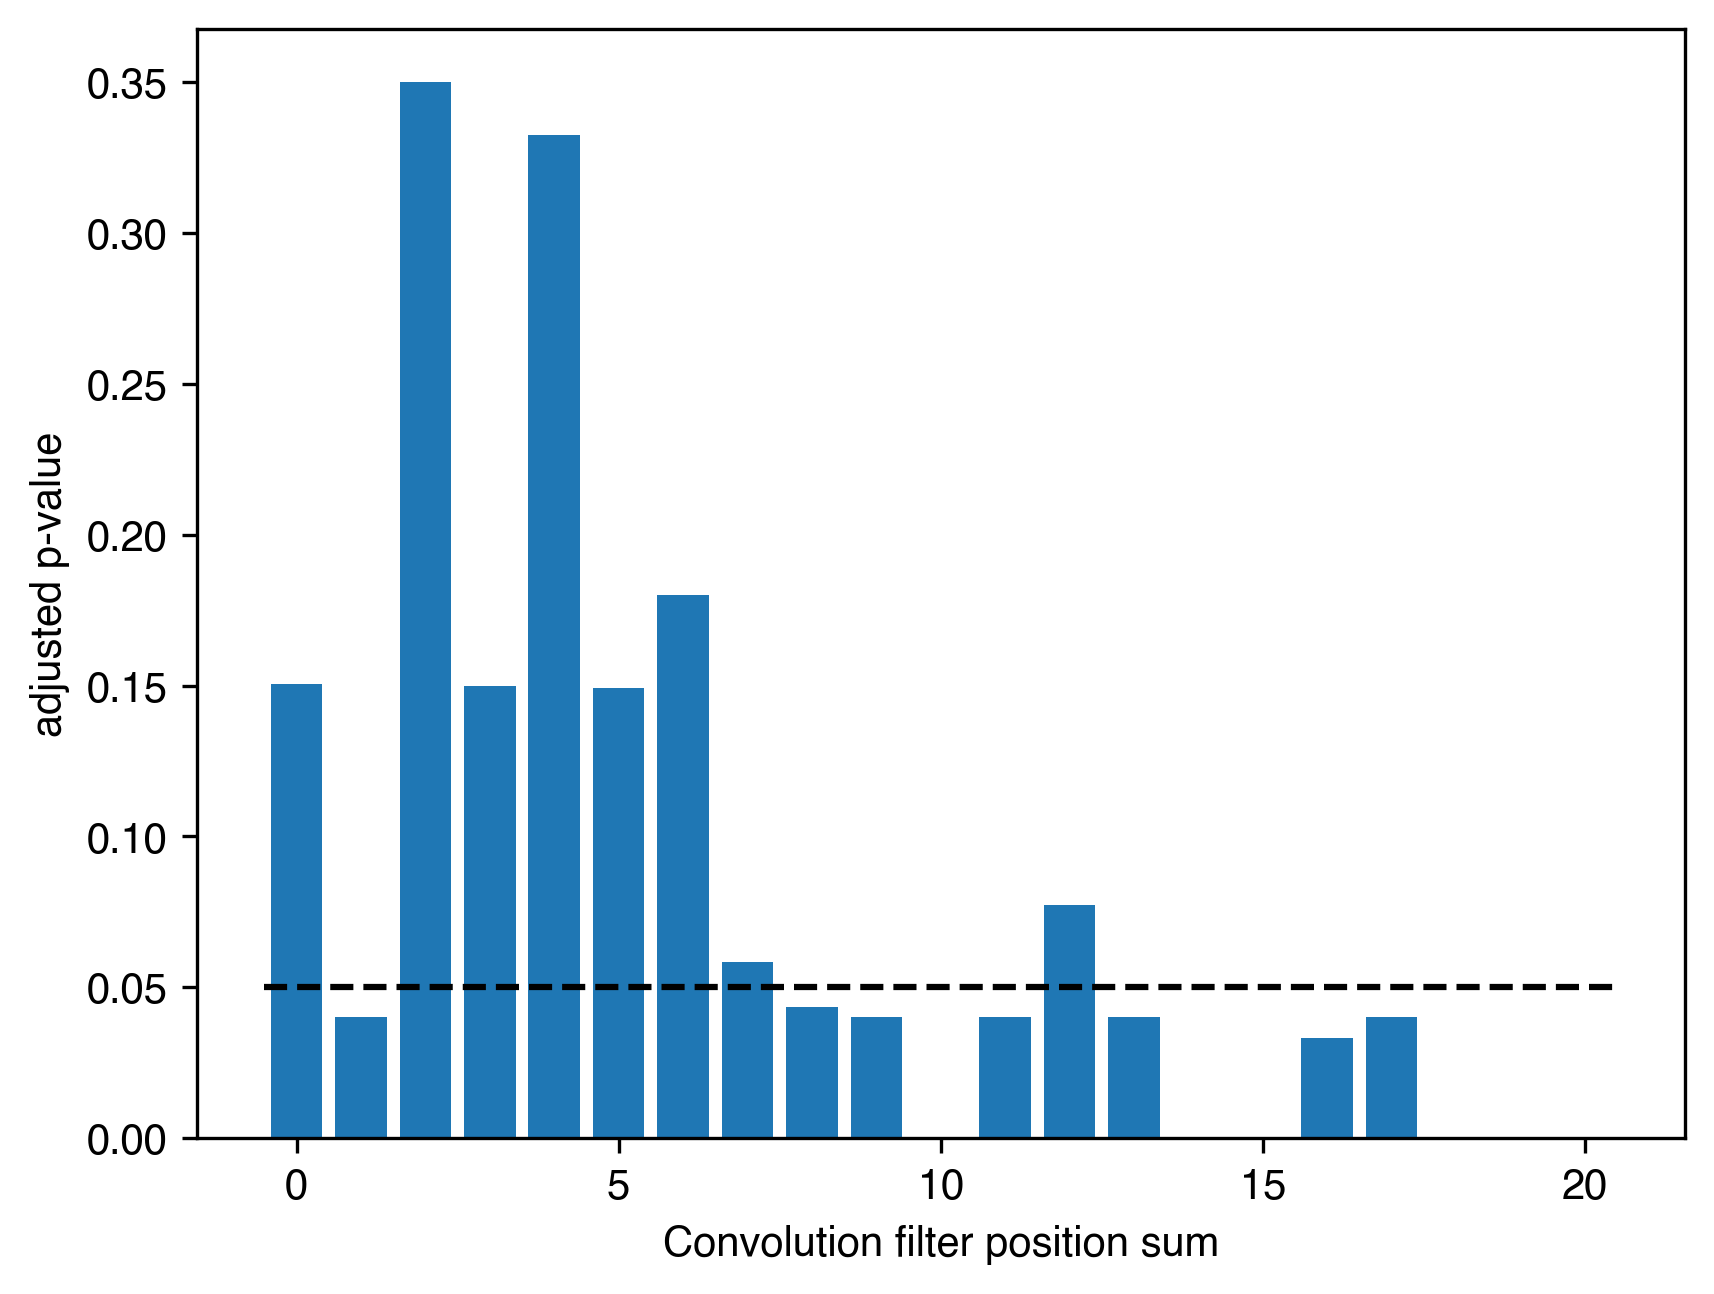

In [176]:
# Look at vertical sums
plt.bar(x=range(20), height=adjusted_p_val_conv_sum_vertical)
plt.xlabel("Convolution filter position sum")
plt.ylabel("adjusted p-value")
plt.hlines(0.05, -0.5, 20.5, color='black', linestyles='--')
plt.show()

# Results for abund k=30

In [313]:
# FOR k = 30
simple_abund_k30_seed = simple_abund_best_model[simple_abund_best_model['kernel_size'] == 30].iloc[0]['seed']
simple_abund_comparison_subset_30 = shuffled_results_abund[(shuffled_results_abund['seed'] == simple_abund_k30_seed) & (shuffled_results_abund['kernel_size'] == 30)].drop_duplicates()
simple_abund_comparison_subset_30

# This can be used to change the order in which the AAs appear
orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

# Read in the weights from the various models
real_conv_arr, real_linear_arr = get_weights_array(simple_abund_best_model[simple_abund_best_model['seed'] == simple_abund_k30_seed], k_size=30, num_shuffles=1, num_seeds=1, two_state=False)
# shuffle_conv_arr, shuffle_linear_arr = get_weights_array(simple_abund_comparison_subset_30, k_size=30, num_shuffles=500, num_seeds=1, two_state=False)
 
# np.save(f"saved_weights/simple_abund_k30_seed{simple_abund_k30_seed}_shuffle_conv_arr.npy", shuffle_conv_arr)
# np.save(f"saved_weights/simple_abund_k30_seed{simple_abund_k30_seed}_shuffle_linear_arr.npy", shuffle_linear_arr)

shuffle_conv_arr = np.load(f"saved_weights/simple_abund_k30_seed{simple_abund_k30_seed}_shuffle_conv_arr.npy")
shuffle_linear_arr = np.load(f"saved_weights/simple_abund_k30_seed{simple_abund_k30_seed}_shuffle_linear_arr.npy")

# Calculate the test stat (in this case the weight sum)
shuffle_test_stat_arr = shuffle_conv_arr.sum(axis=2) 
real_test_stat_arr = real_conv_arr.sum(axis=2)

# Calculate p-value for weight sum
print("Conv sum p-values")
p_val_overall_conv_sum = (np.abs(shuffle_test_stat_arr) > np.abs(real_test_stat_arr)).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr.shape[0] + 1)
p_val_greater_conv_sum = (shuffle_test_stat_arr > real_test_stat_arr).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr.shape[0] + 1)
p_val_less_conv_sum = (shuffle_test_stat_arr < real_test_stat_arr).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr.shape[0] + 1)

reject, adjusted_p_val_conv_sum, _, _ = smt.multipletests(np.concatenate([p_val_greater_conv_sum, p_val_less_conv_sum]), alpha=0.05, method='fdr_bh')

for aa, val1, val2 in zip(orig_aa_order, adjusted_p_val_conv_sum[:20], adjusted_p_val_conv_sum[20:]):
    print(aa, ":", val1, val2)

# Calculate p-value for vertical weight sum
print("Conv sum p-values")
p_val_overall_conv_sum_vertical = (np.abs(shuffle_test_stat_vertical_arr) > np.abs(real_test_stat_vertical_arr)).sum(axis=0).sum(axis=0) / shuffle_test_stat_vertical_arr.shape[0]
reject, adjusted_p_val_conv_sum_vertical, _, _ = smt.multipletests(p_val_overall_conv_sum_vertical, alpha=0.05, method='fdr_bh')

# Calculate p-value for linear weights
print("Linear weight p-values")
# p_val_overall_linear = (np.abs(shuffle_linear_arr) > np.abs(real_linear_arr)).sum(axis=0).sum(axis=0) / shuffle_linear_arr.shape[0]
p_val_greater_linear = (shuffle_linear_arr > real_linear_arr).sum(axis=0).sum(axis=0) / shuffle_linear_arr.shape[0]
p_val_less_linear = (shuffle_linear_arr < real_linear_arr).sum(axis=0).sum(axis=0) / shuffle_linear_arr.shape[0]
reject, adjusted_p_val_linear, _, _ = smt.multipletests(np.concatenate([p_val_greater_linear, p_val_less_linear]), alpha=0.05, method='fdr_bh')
adjusted_p_val_linear_greater = adjusted_p_val_linear[:len(p_val_greater_linear)]
adjusted_p_val_linear_less = adjusted_p_val_linear[len(p_val_greater_linear):]

for i, val in enumerate(adjusted_p_val_linear):
    print(i, ":", val)

# Calculate p-value for conv weights individually
print("Conv weight p-values")
# p_val_overall_conv = (np.abs(shuffle_conv_arr) > np.abs(real_conv_arr)).sum(axis=0) / shuffle_conv_arr.shape[0]
p_val_pos_conv = (shuffle_conv_arr > real_conv_arr).sum(axis=0) / shuffle_conv_arr.shape[0]
p_val_neg_conv = (shuffle_conv_arr < real_conv_arr).sum(axis=0) / shuffle_conv_arr.shape[0]
orig_shape = p_val_pos_conv.shape
reject, adjusted_p_val_conv, _, _ = smt.multipletests(np.concatenate([p_val_pos_conv.ravel(), p_val_neg_conv.ravel()]), alpha=0.05, method='fdr_bh')

adjusted_p_val_conv_greater = adjusted_p_val_conv[:(p_val_neg_conv.size)].reshape(orig_shape)
adjusted_p_val_conv_less = adjusted_p_val_conv[(p_val_neg_conv.size):].reshape(orig_shape)

100%|██████████| 1/1 [00:00<00:00, 338.63it/s]

Conv sum p-values
R : 0.17964071856287425 0.998003992015968
H : 0.046223342788107996 0.998003992015968
K : 0.0 0.998003992015968
D : 0.0 0.998003992015968
E : 0.0 0.998003992015968
S : 0.0 0.998003992015968
T : 0.009980039920159679 0.998003992015968
N : 0.0 0.998003992015968
Q : 0.0 0.998003992015968
C : 0.998003992015968 0.0
G : 0.0 0.998003992015968
P : 0.0 0.998003992015968
A : 0.009980039920159679 0.998003992015968
V : 0.998003992015968 0.022177866489243733
I : 0.998003992015968 0.0
L : 0.998003992015968 0.022177866489243733
M : 0.998003992015968 0.009980039920159679
F : 0.998003992015968 0.0
Y : 0.998003992015968 0.0
W : 0.998003992015968 0.0
Conv sum p-values
Linear weight p-values
0 : 1.0
1 : 1.0
2 : 0.132
3 : 1.0
4 : 0.272
5 : 0.2508
6 : 0.2508
7 : 0.044000000000000004
8 : 0.022
9 : 0.0
10 : 0.132
11 : 0.132
12 : 0.0
13 : 1.0
14 : 0.0
15 : 1.0
16 : 1.0
17 : 1.0
18 : 1.0
19 : 1.0
20 : 1.0
21 : 1.0
Conv weight p-values


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


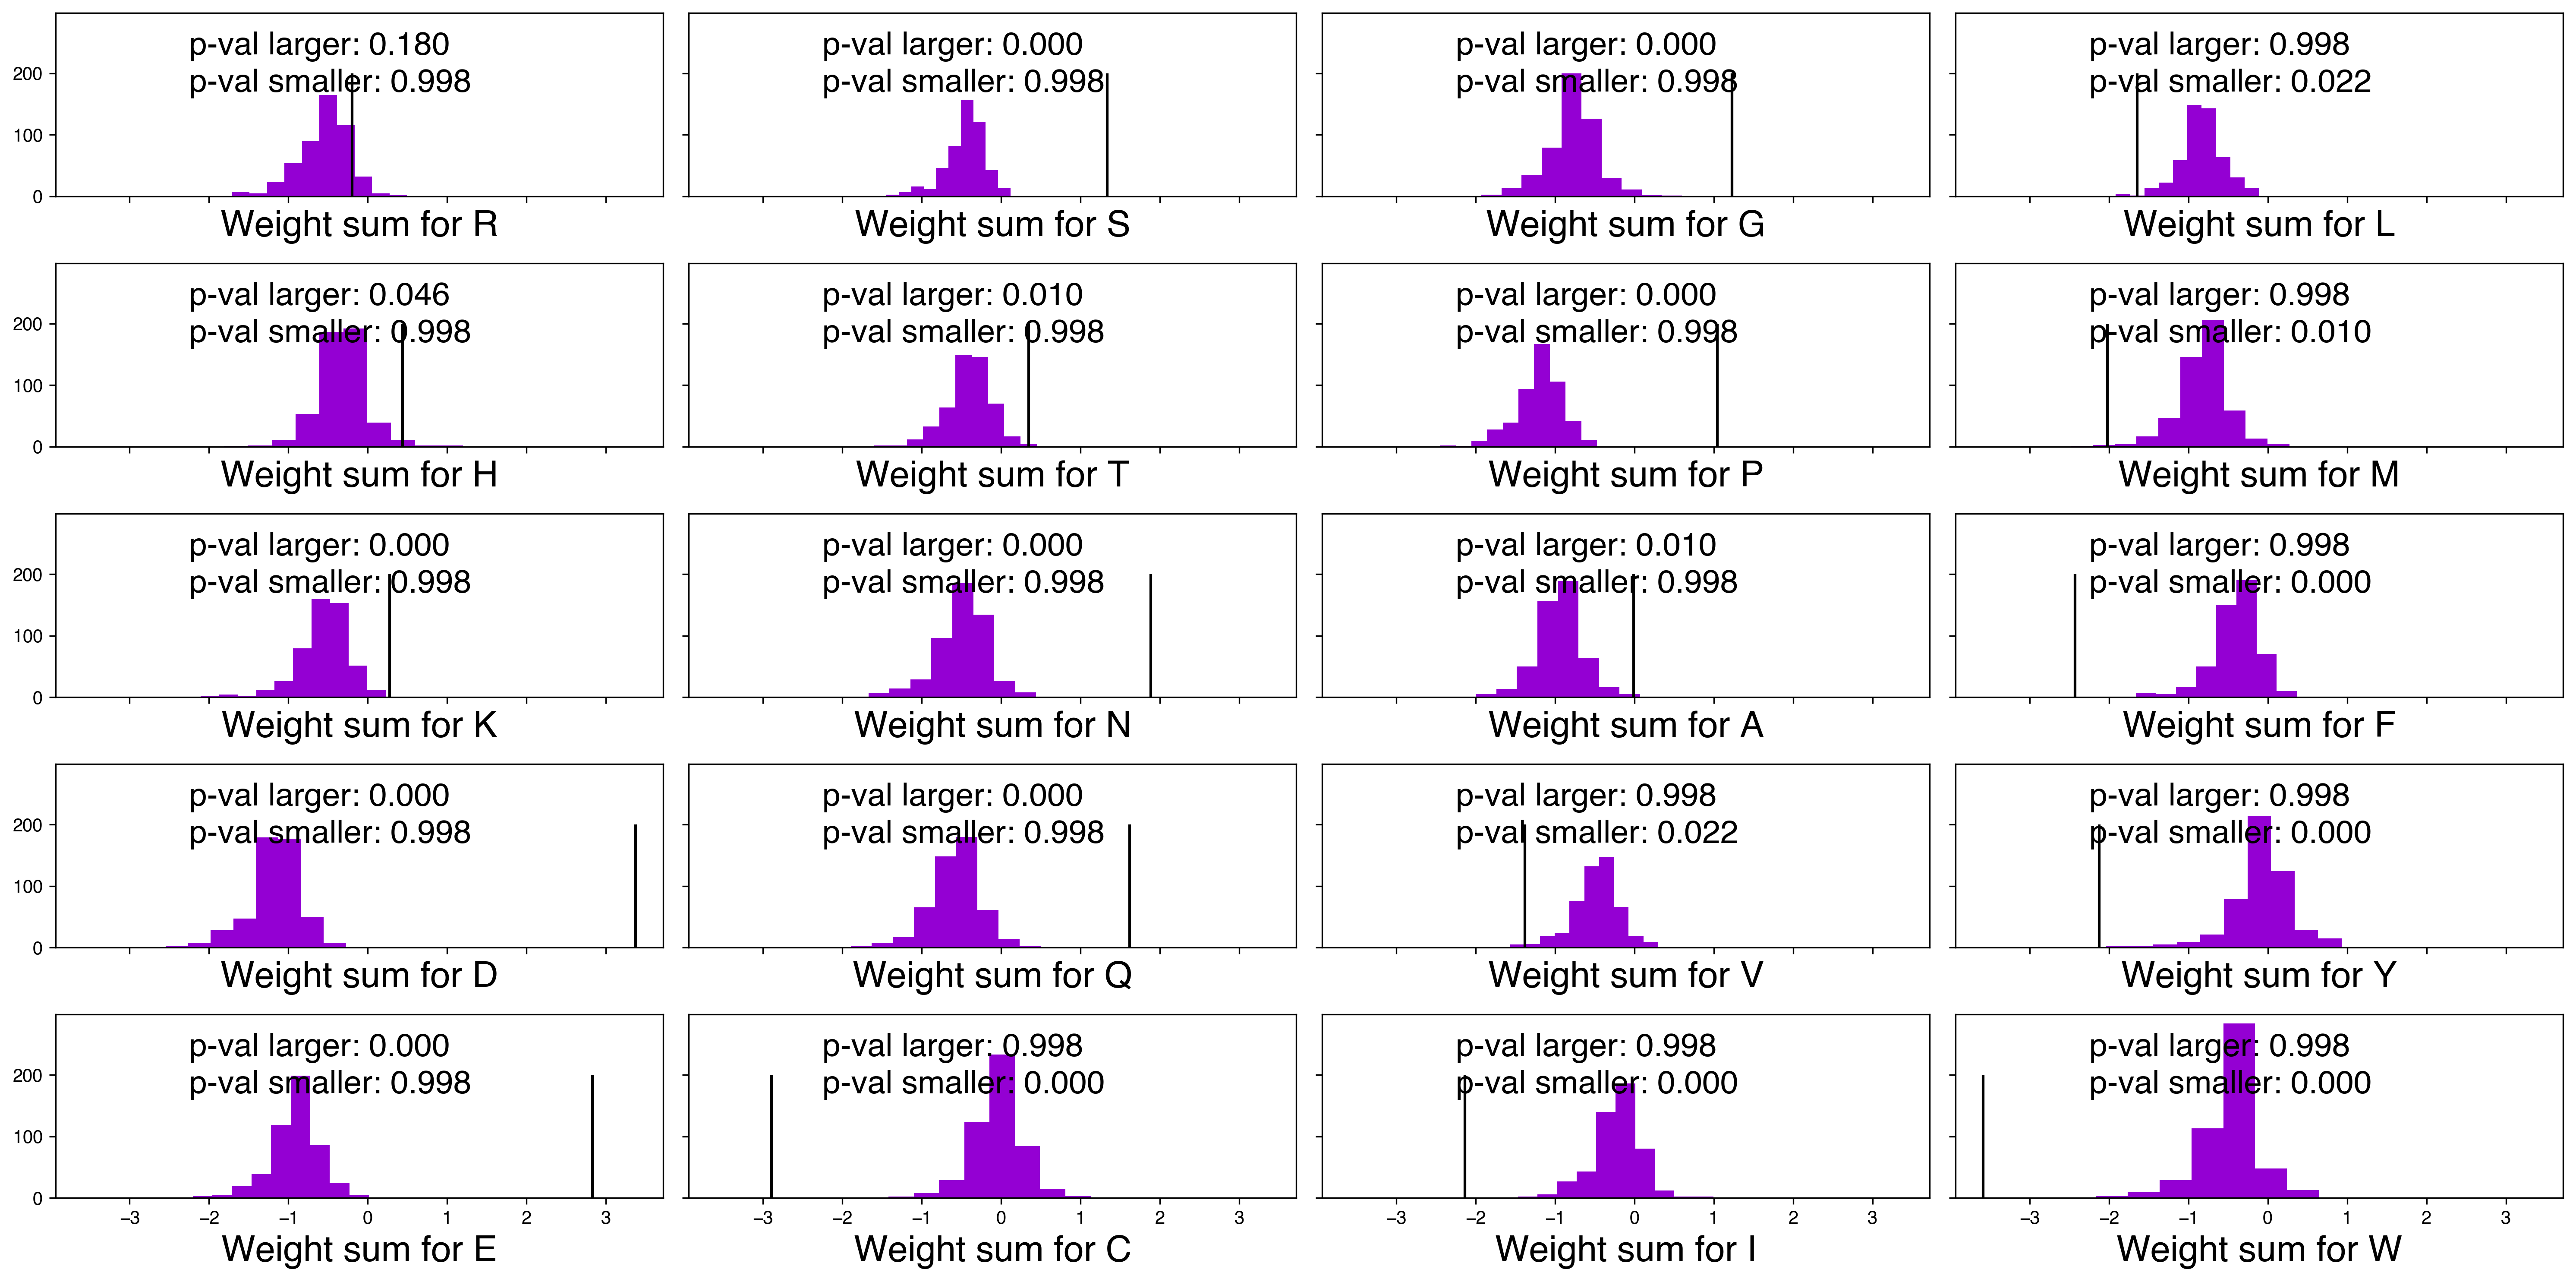

In [315]:
make_histogram(shuffle_test_stat_arr, real_test_stat_arr, adjusted_p_val_conv_sum[:20], adjusted_p_val_conv_sum[20:], 5, 4)

plt.savefig("figures/for_revision/simple_abund_k30_conv_sum_pvals.pdf", format='pdf', bbox_inches='tight')
# plt.savefig("figures/for_revision/simple_abund_k30_conv_sum_pvals.png", format='png', bbox_inches='tight')


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


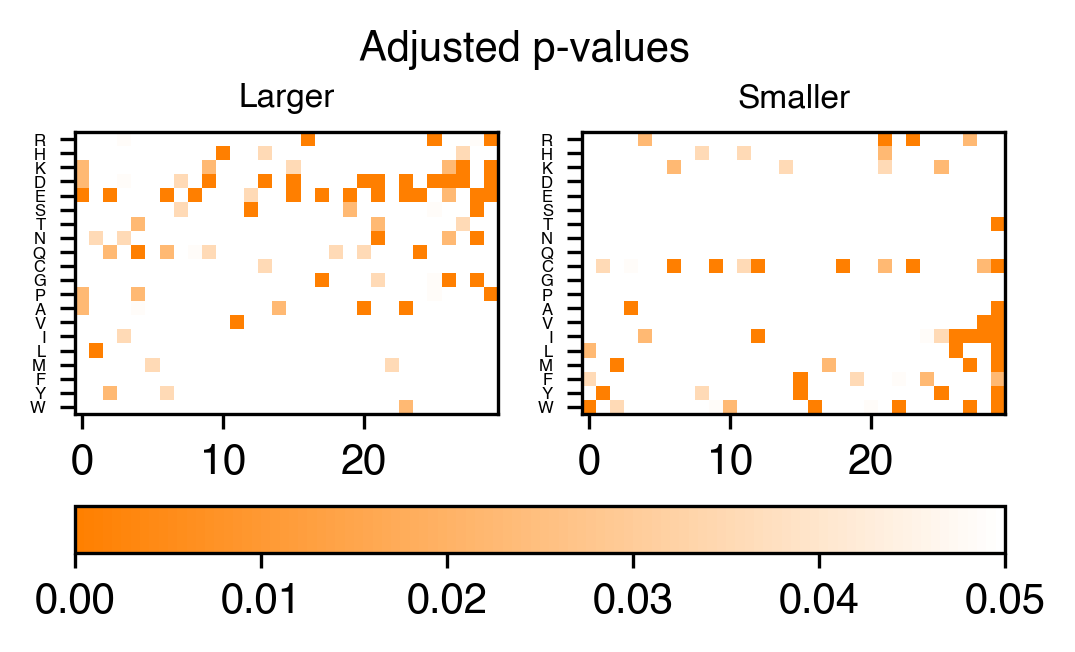

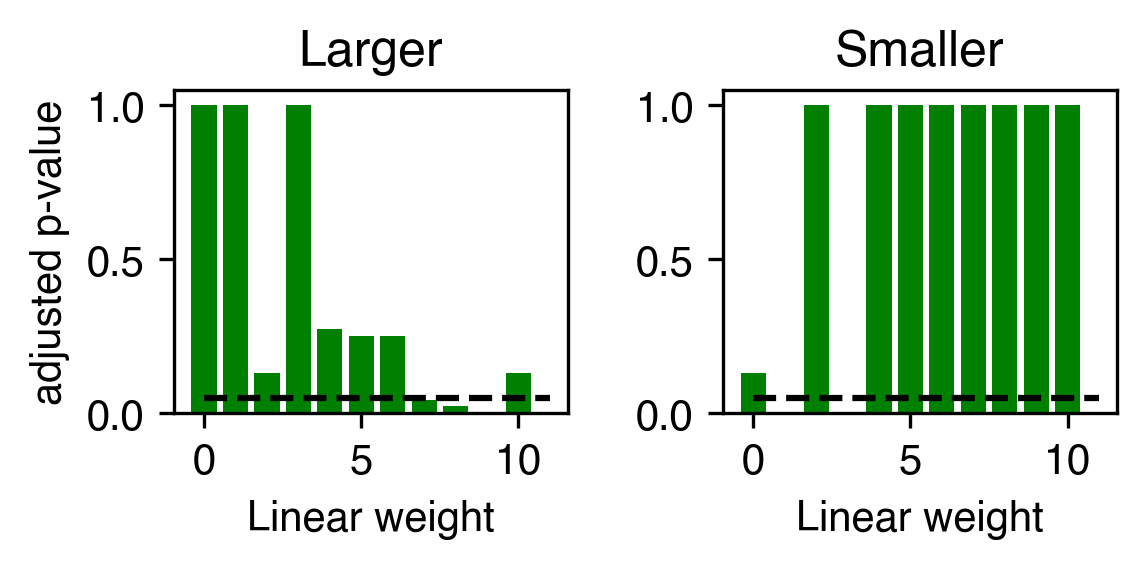

In [316]:
# This is setting up our colors for the plots

# Colors for convolutional filter
colors = [(1, 0.5, 0), (1, 1, 1)]  # Yellow, White
# colors = [(1, 0, 0), (1, 1, 1)]  # Yellow, White
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any

# Colors for AA labels
colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}

fig, axs = plt.subplots(1, 2, figsize=(4, 2))
im = axs[0].imshow(adjusted_p_val_conv_greater.squeeze(0).T, cmap=custom_cmap, vmin=0, vmax=0.05)
axs[0].set_title("Larger", fontsize=8)
# axs[0].set_colorbar()

axs[1].imshow(adjusted_p_val_conv_less.squeeze(0).T, cmap=custom_cmap, vmin=0, vmax=0.05)
axs[1].set_title("Smaller", fontsize=8)
# axs[1].colorbar()
fig.suptitle("Adjusted p-values", fontsize=10, y=1.02)

axs[0].set_yticks(range(0, 20), orig_aa_order, fontsize=4)
axs[1].set_yticks(range(0, 20), orig_aa_order, fontsize=4)

fig.colorbar(im, ax=axs, orientation="horizontal",pad=0.2)

plt.savefig("figures/for_revision/simple_abund_k30_conv_position_pvals.pdf", format='pdf', bbox_inches='tight', dpi=1000)

fig, axs = plt.subplots(1, 2, figsize=(4, 2), sharex=True)
axs[0].bar(x=range(0,11), height=adjusted_p_val_linear_greater, color='green')
axs[0].set_xlabel("Linear weight")
axs[0].set_ylabel("adjusted p-value")
axs[0].hlines(0.05, 0, 11, color='black', linestyles='--')
axs[0].set_title("Larger")

axs[1].bar(x=range(11), height=adjusted_p_val_linear_less, color='green')
axs[1].set_xlabel("Linear weight")
# axs[1].set_ylabel("adjusted p-value")
axs[1].hlines(0.05, 0, 11, color='black', linestyles='--')
axs[1].set_title("Smaller")

fig.tight_layout()

plt.savefig("figures/for_revision/simple_abund_k30_linear_position_pvals.pdf", format='pdf', bbox_inches='tight', dpi=1000)

# Results for two-state k=40

In [348]:
# For two state model - get size and seed to compare, and then get corresponding shuffle results

two_state_best_model = get_best_model(two_model_results, spearman_abund=True, spearman_act=True, pearson_act=True)
two_state_best_model = two_state_best_model[two_state_best_model["activity_fun"] == "Hill"].reset_index(drop=True)
two_state_seed = two_state_best_model.loc[0, 'seed']
two_state_k = two_state_best_model.loc[0, 'kernel_size']
two_state_ak = two_state_best_model.loc[0, 'abund_k']

two_state_comparison_subset = shuffled_results_two_state[(shuffled_results_two_state['seed'] == two_state_seed) & (shuffled_results_two_state['kernel_size'] == two_state_k) & (shuffled_results_two_state['abund_k'] == two_state_ak)].drop_duplicates()
two_state_comparison_subset

,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,spearman_abund_val,...,pearson_abund_train,pearson_act_train,K1_negative,K2_negative,abund_negative,relu,total_params,shuffle_number,seed,abund_k
58,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,-0.020468,0.004085,-0.066845,...,0.184680,-0.017784,False,NaN,False,False,1418,1,1298091,30
118,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,-0.037930,-0.016927,0.029729,...,0.193410,0.009739,False,NaN,False,False,1418,2,1298091,30
178,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,-0.029985,-0.010762,-0.013276,...,0.178939,-0.011435,False,NaN,False,False,1418,3,1298091,30
238,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,-0.003084,-0.003174,0.005400,...,0.191142,-0.019739,False,NaN,False,False,1418,4,1298091,30
298,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,-0.013627,0.003906,0.029206,...,0.186103,-0.012608,False,NaN,False,False,1418,5,1298091,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11636,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,-0.022897,0.020234,0.036991,...,0.192070,0.004675,False,NaN,False,False,1418,495,1298091,30
11637,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,-0.001354,-0.031324,0.059733,...,0.177131,0.124859,False,NaN,False,False,1418,496,1298091,30
11638,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,0.025257,0.012048,-0.005975,...,0.200136,-0.008289,False,NaN,False,False,1418,497,1298091,30
11639,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,-0.009563,0.017834,-0.056499,...,0.181872,0.144311,False,NaN,False,False,1418,498,1298091,30


In [351]:
# This can be used to change the order in which the AAs appear
orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

two_state_best_model_row = two_state_best_model[(two_state_best_model['seed'] == two_state_seed) & (two_state_best_model['kernel_size'] == two_state_k)  & (two_state_best_model['abund_k'] == two_state_ak) & (two_state_best_model['hill_value'] == 1)] 

# Read in the weights from the various models
real_conv_arr, real_linear_arr = get_weights_array(two_state_best_model_row, k_size=two_state_k, num_shuffles=1, num_seeds=1, two_state=True)
shuffle_conv_arr, shuffle_linear_arr = get_weights_array(two_state_comparison_subset, k_size=two_state_k, num_shuffles=500, num_seeds=1, two_state=True)
 
np.save(f"saved_weights/two_state_k{two_state_k}_seed{two_state_seed}_shuffle_conv_arr.npy", shuffle_conv_arr)
np.save(f"saved_weights/two_state_k{two_state_k}_seed{two_state_seed}_shuffle_linear_arr.npy", shuffle_linear_arr)

# shuffle_conv_arr = np.load(f"saved_weights/two_state_k{two_state_k}_seed{two_state_seed}_shuffle_conv_arr.npy")
# shuffle_linear_arr = np.load(f"saved_weights/two_state_k{two_state_k}_seed{two_state_seed}_shuffle_linear_arr.npy")

# Calculate the test stat (in this case the weight sum)
shuffle_test_stat_arr = shuffle_conv_arr.sum(axis=2) 
real_test_stat_arr = real_conv_arr.sum(axis=2)

# Calculate p-value for weight sum
print("Conv sum p-values")
p_val_overall_conv_sum = (np.abs(shuffle_test_stat_arr) > np.abs(real_test_stat_arr)).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr.shape[0] + 1)
p_val_greater_conv_sum = (shuffle_test_stat_arr > real_test_stat_arr).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr.shape[0] + 1)
p_val_less_conv_sum = (shuffle_test_stat_arr < real_test_stat_arr).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr.shape[0] + 1)

reject, adjusted_p_val_conv_sum, _, _ = smt.multipletests(np.concatenate([p_val_greater_conv_sum, p_val_less_conv_sum]), alpha=0.05, method='fdr_bh')

for aa, val1, val2 in zip(orig_aa_order, adjusted_p_val_conv_sum[:20], adjusted_p_val_conv_sum[20:]):
    print(aa, ":", val1, val2)

# Calculate p-value for vertical weight sum
print("Conv sum p-values")
p_val_overall_conv_sum_vertical = (np.abs(shuffle_test_stat_vertical_arr) > np.abs(real_test_stat_vertical_arr)).sum(axis=0).sum(axis=0) / shuffle_test_stat_vertical_arr.shape[0]
reject, adjusted_p_val_conv_sum_vertical, _, _ = smt.multipletests(p_val_overall_conv_sum_vertical, alpha=0.05, method='fdr_bh')

# Calculate p-value for linear weights
print("Linear weight p-values")
# p_val_overall_linear = (np.abs(shuffle_linear_arr) > np.abs(real_linear_arr)).sum(axis=0).sum(axis=0) / shuffle_linear_arr.shape[0]
p_val_greater_linear = (shuffle_linear_arr > real_linear_arr).sum(axis=0).sum(axis=0) / shuffle_linear_arr.shape[0]
p_val_less_linear = (shuffle_linear_arr < real_linear_arr).sum(axis=0).sum(axis=0) / shuffle_linear_arr.shape[0]
reject, adjusted_p_val_linear, _, _ = smt.multipletests(np.concatenate([p_val_greater_linear, p_val_less_linear]), alpha=0.05, method='fdr_bh')
adjusted_p_val_linear_greater = adjusted_p_val_linear[:len(p_val_greater_linear)]
adjusted_p_val_linear_less = adjusted_p_val_linear[len(p_val_greater_linear):]

for i, val in enumerate(adjusted_p_val_linear):
    print(i, ":", val)

# Calculate p-value for conv weights individually
print("Conv weight p-values")
# p_val_overall_conv = (np.abs(shuffle_conv_arr) > np.abs(real_conv_arr)).sum(axis=0) / shuffle_conv_arr.shape[0]
p_val_pos_conv = (shuffle_conv_arr > real_conv_arr).sum(axis=0) / shuffle_conv_arr.shape[0]
p_val_neg_conv = (shuffle_conv_arr < real_conv_arr).sum(axis=0) / shuffle_conv_arr.shape[0]
orig_shape = p_val_pos_conv.shape
reject, adjusted_p_val_conv, _, _ = smt.multipletests(np.concatenate([p_val_pos_conv.ravel(), p_val_neg_conv.ravel()]), alpha=0.05, method='fdr_bh')

adjusted_p_val_conv_greater = adjusted_p_val_conv[:(p_val_neg_conv.size)].reshape(orig_shape)
adjusted_p_val_conv_less = adjusted_p_val_conv[(p_val_neg_conv.size):].reshape(orig_shape)

100%|██████████| 500/500 [01:13<00:00,  6.83it/s]  

Conv sum p-values
R : 0.0 0.998003992015968
H : 0.0 0.998003992015968
K : 0.0 0.998003992015968
D : 0.0 0.998003992015968
E : 0.0 0.998003992015968
S : 0.0 0.998003992015968
T : 0.0 0.998003992015968
N : 0.0 0.998003992015968
Q : 0.0 0.998003992015968
C : 0.003992015968063872 0.998003992015968
G : 0.0 0.998003992015968
P : 0.0 0.998003992015968
A : 0.0 0.998003992015968
V : 0.0 0.998003992015968
I : 0.998003992015968 0.003992015968063872
L : 0.998003992015968 0.0
M : 0.998003992015968 0.0
F : 0.998003992015968 0.0
Y : 0.998003992015968 0.0
W : 0.998003992015968 0.0
Conv sum p-values
Linear weight p-values
0 : 1.0
1 : 0.0
Conv weight p-values


In [353]:
shuffle_conv_arr.shape

(500, 1, 40, 20)

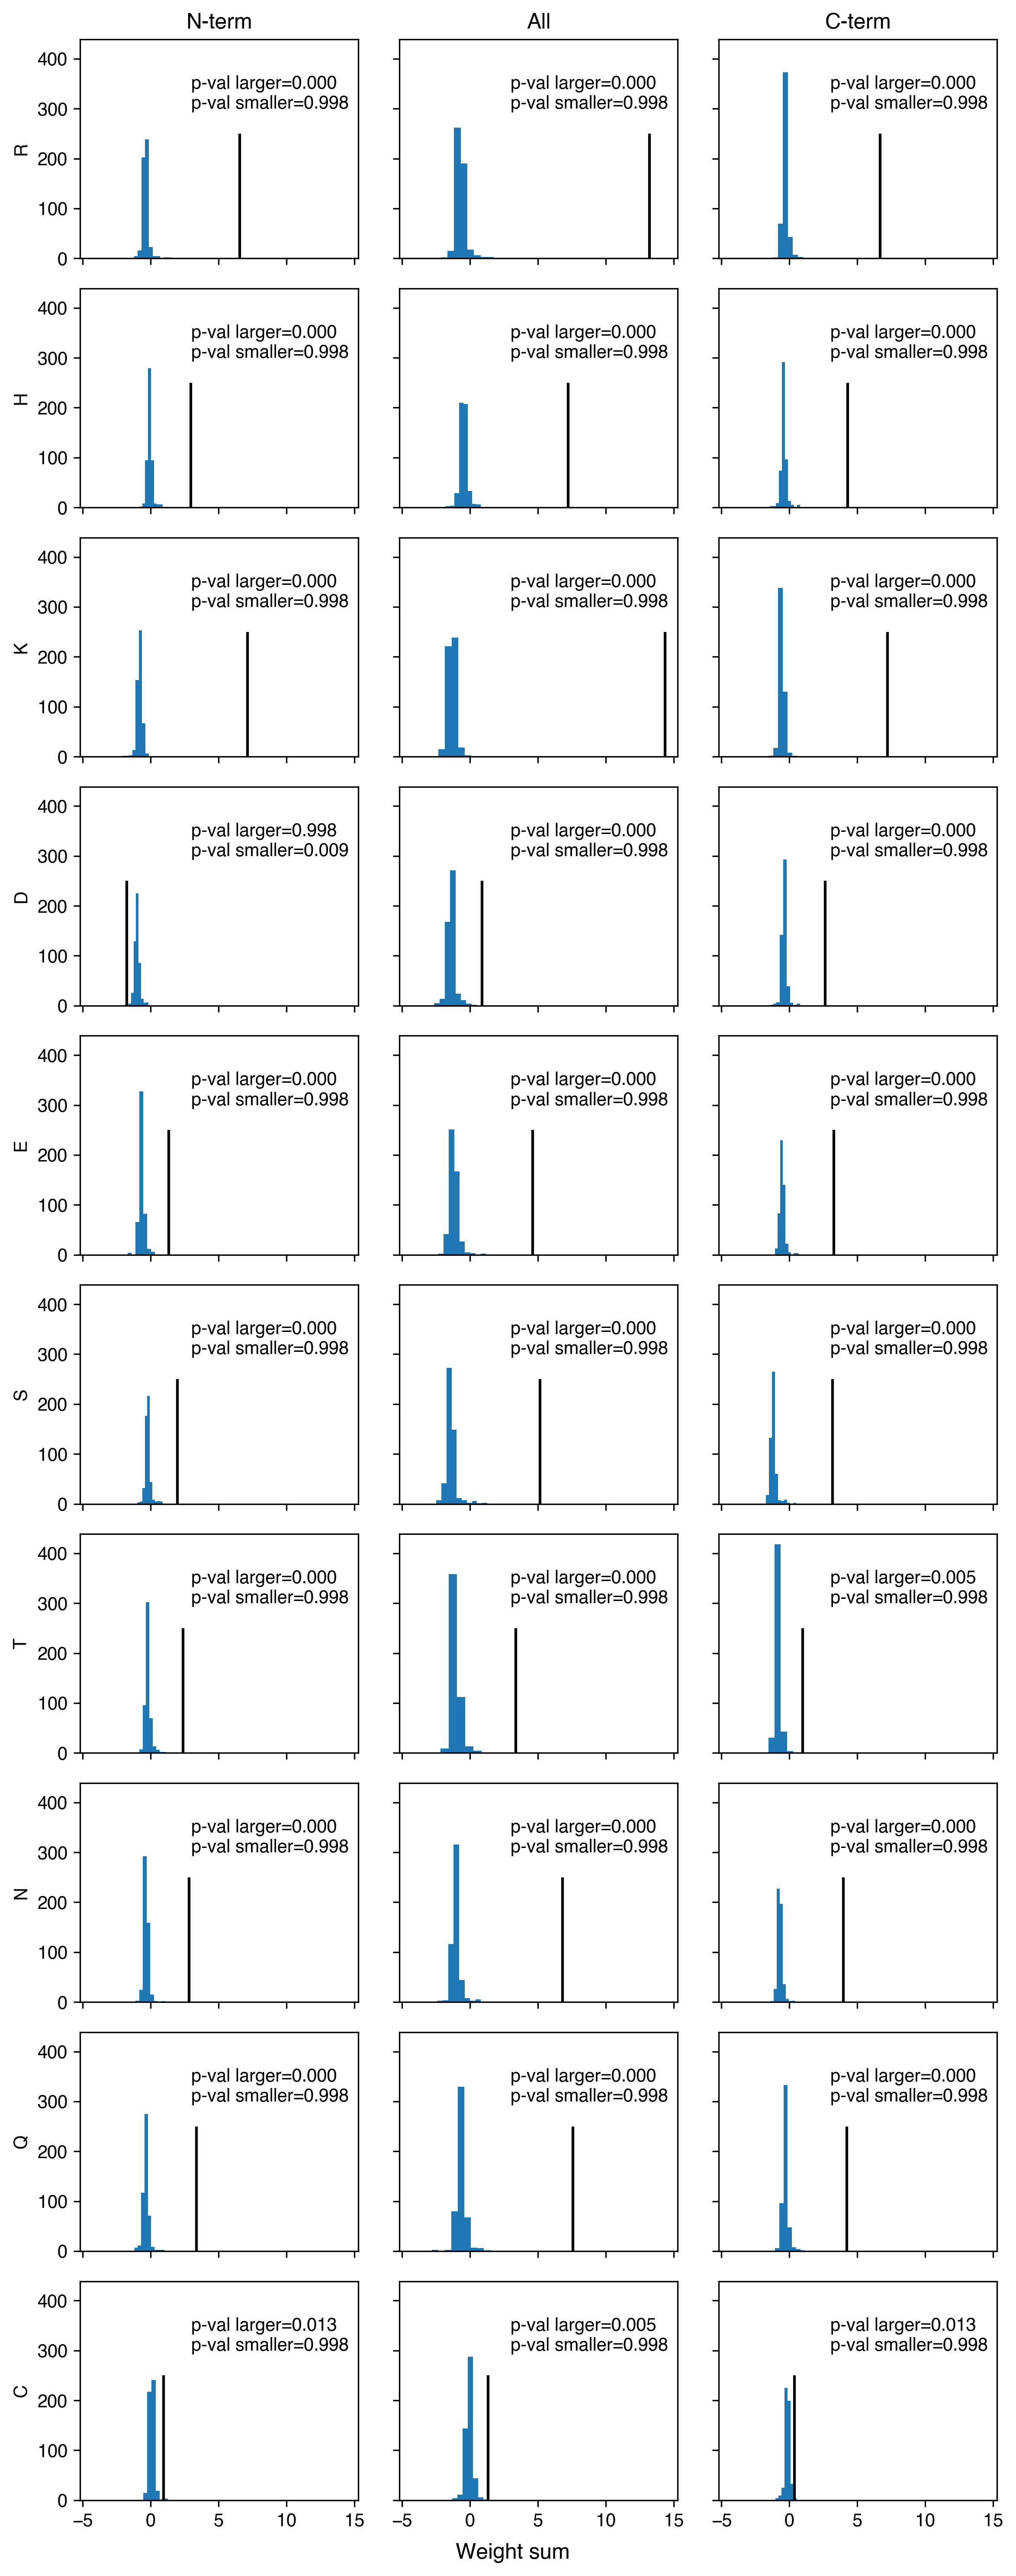

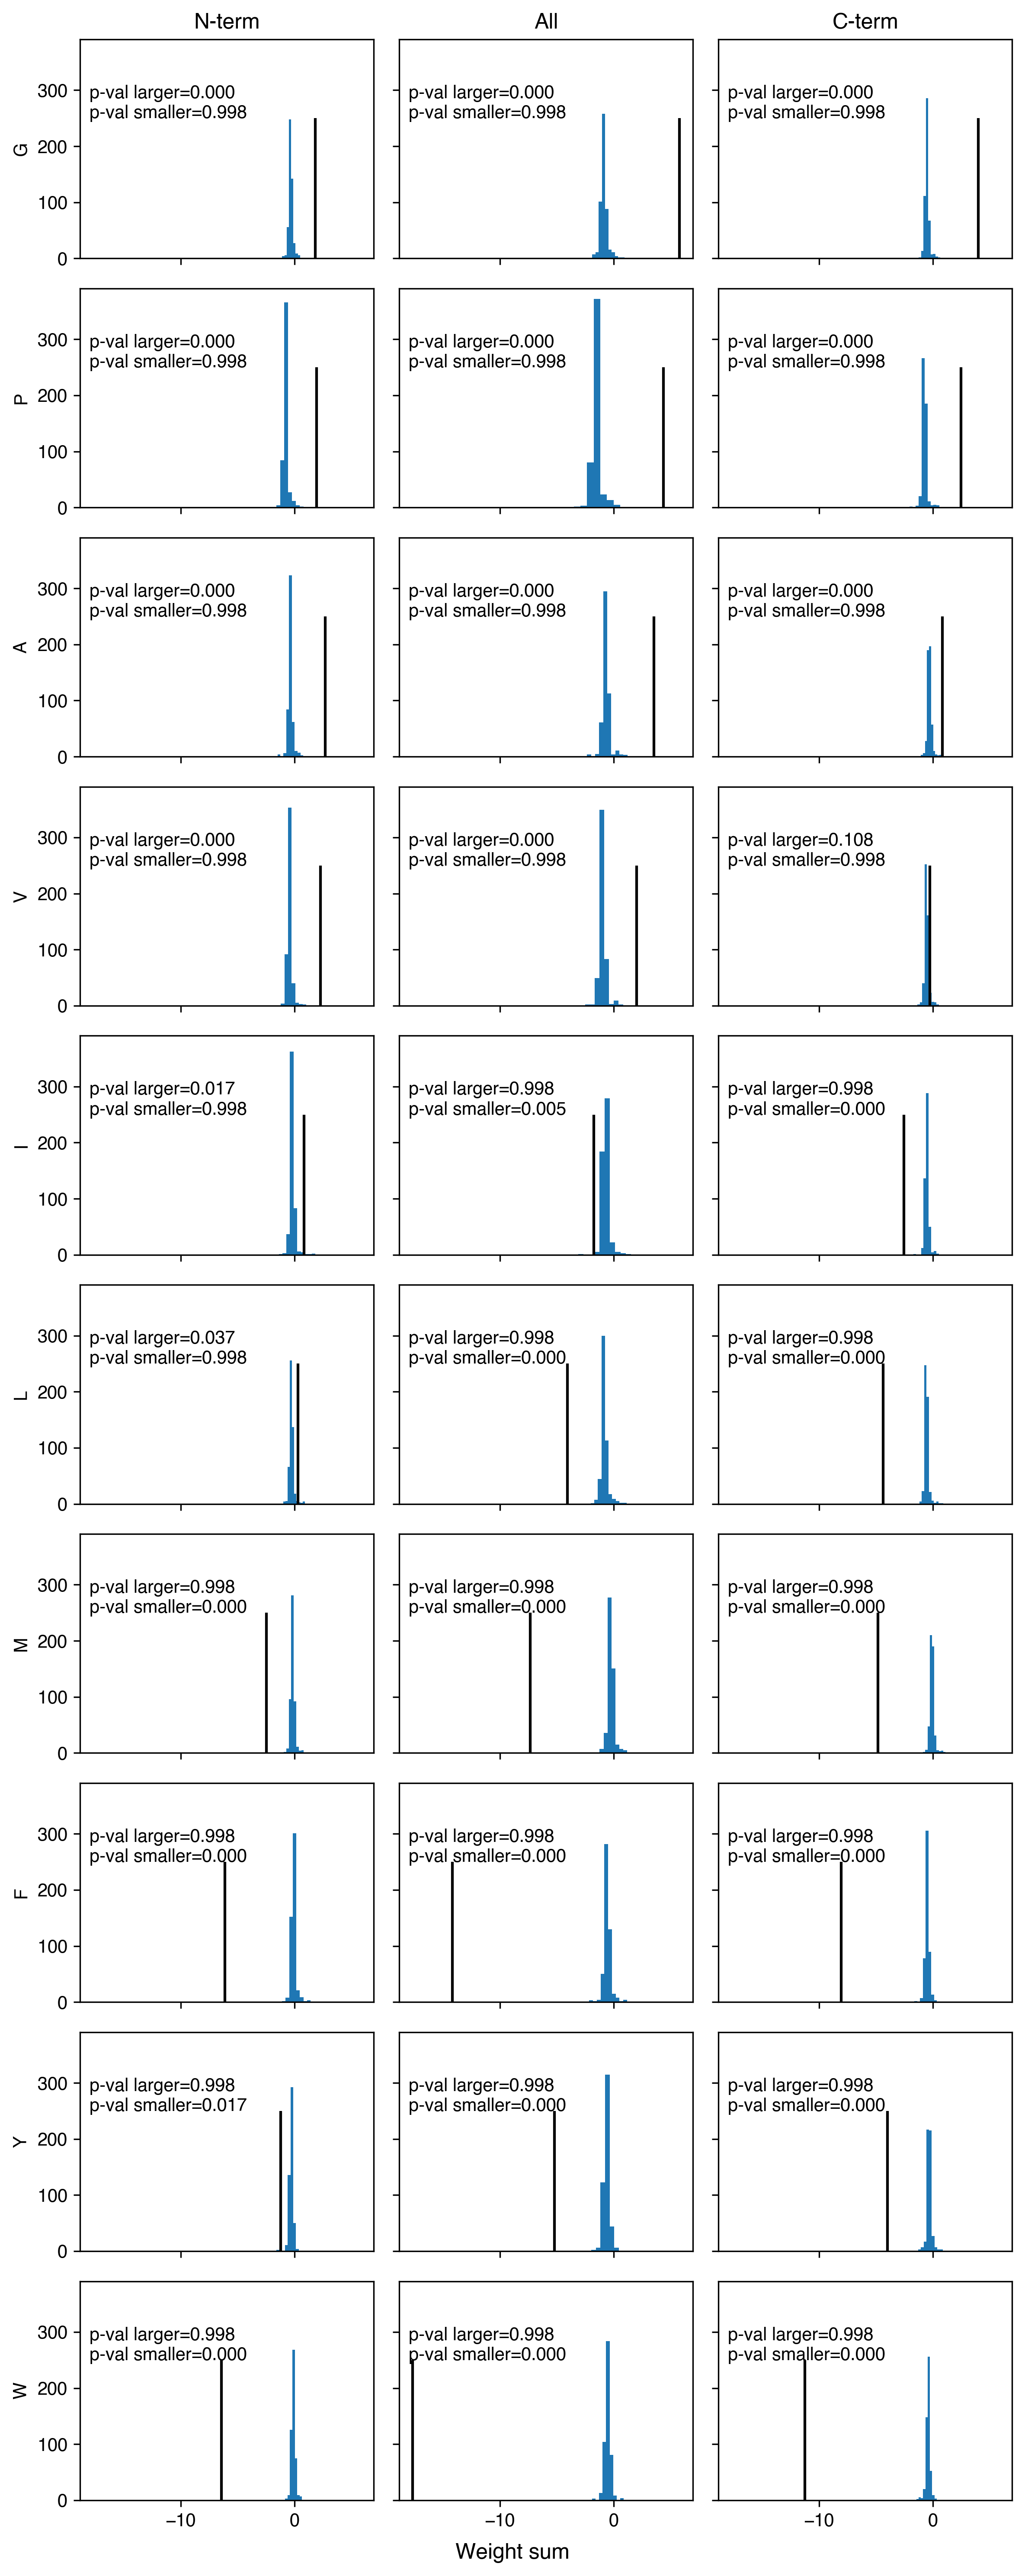

In [352]:
# N-term test stat
shuffle_test_stat_arr_N_term = shuffle_conv_arr[:, :, :20, :].sum(axis=2) 
real_test_stat_arr_N_term = real_conv_arr[:, :, :20, :].sum(axis=2)

# Calculate p-value for weight sum
p_val_N_conv_sum = (np.abs(shuffle_test_stat_arr_N_term) > np.abs(real_test_stat_arr_N_term)).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr_N_term.shape[0] + 1)
p_val_N_greater_conv_sum = (shuffle_test_stat_arr_N_term > real_test_stat_arr_N_term).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr_N_term.shape[0] + 1)
p_val_N_less_conv_sum = (shuffle_test_stat_arr_N_term < real_test_stat_arr_N_term).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr_N_term.shape[0] + 1)

# C-term test stat
shuffle_test_stat_arr_C_term = shuffle_conv_arr[:, :, 20:, :].sum(axis=2) 
real_test_stat_arr_C_term = real_conv_arr[:, :, 20:, :].sum(axis=2)

# Calculate p-value for weight sum
p_val_C_conv_sum = (np.abs(shuffle_test_stat_arr_C_term) > np.abs(real_test_stat_arr_C_term)).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr_C_term.shape[0] + 1)
p_val_C_greater_conv_sum = (shuffle_test_stat_arr_C_term > real_test_stat_arr_C_term).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr_C_term.shape[0] + 1)
p_val_C_less_conv_sum = (shuffle_test_stat_arr_C_term < real_test_stat_arr_C_term).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr_C_term.shape[0] + 1)

# Full seq weight sum
shuffle_test_stat_arr_all = shuffle_conv_arr[:, :, :, :].sum(axis=2) 
real_test_stat_arr_all = real_conv_arr[:, :, :, :].sum(axis=2)

# Calculate p-value for weight sum
p_val_all_conv_sum = (np.abs(shuffle_test_stat_arr_all) > np.abs(real_test_stat_arr_all)).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr_all.shape[0] + 1)
p_val_all_greater_conv_sum = (shuffle_test_stat_arr_all > real_test_stat_arr_all).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr_all.shape[0] + 1)
p_val_all_less_conv_sum = (shuffle_test_stat_arr_all < real_test_stat_arr_all).sum(axis=0).sum(axis=0) / (shuffle_test_stat_arr_all.shape[0] + 1)


# Correct all p-values together
reject, adjusted_p_val_conv_sum, _, _ = smt.multipletests(np.concatenate([p_val_N_greater_conv_sum, p_val_N_less_conv_sum, p_val_all_greater_conv_sum, p_val_all_less_conv_sum, p_val_C_greater_conv_sum, p_val_C_less_conv_sum]), alpha=0.05, method='fdr_bh')

adjusted_p_val_conv_sum_greater_N = adjusted_p_val_conv_sum[:20]
adjusted_p_val_conv_sum_less_N = adjusted_p_val_conv_sum[20:40]
adjusted_p_val_conv_sum_greater_all = adjusted_p_val_conv_sum[40:60]
adjusted_p_val_conv_sum_less_all = adjusted_p_val_conv_sum[60:80]
adjusted_p_val_conv_sum_greater_C = adjusted_p_val_conv_sum[80:100]
adjusted_p_val_conv_sum_less_C = adjusted_p_val_conv_sum[100:]



# Plotting functions
fig, axs = plt.subplots(10, 3, figsize=(8, 20), sharex=True, sharey=True)
amino_acids = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

axs[0, 0].set_title("N-term")
axs[0, 1].set_title("All")
axs[0, 2].set_title("C-term")

for i, aa in enumerate(amino_acids[:10]):
    axs[i, 0].hist(shuffle_test_stat_arr_N_term[:, :, i])
    axs[i, 0].vlines(real_test_stat_arr_N_term[:, :, i], 0, 250, color='black')
    
    axs[i,0].text(3, 300, f"p-val larger={adjusted_p_val_conv_sum_greater_N[i]:.3f}\np-val smaller={adjusted_p_val_conv_sum_less_N[i]:.3f}", fontsize=10)

    axs[i, 0].set_ylabel(aa)

    axs[i, 1].hist(shuffle_test_stat_arr_all[:, :, i])
    axs[i, 1].vlines(real_test_stat_arr_all[:, :, i], 0, 250, color='black')
    
    axs[i, 1].text(3, 300, f"p-val larger={adjusted_p_val_conv_sum_greater_all[i]:.3f}\np-val smaller={adjusted_p_val_conv_sum_less_all[i]:.3f}", fontsize=10)

    axs[i, 2].hist(shuffle_test_stat_arr_C_term[:, :, i])
    axs[i, 2].vlines(real_test_stat_arr_C_term[:, :, i], 0, 250, color='black')
    
    axs[i, 2].text(3, 300, f"p-val larger={adjusted_p_val_conv_sum_greater_C[i]:.3f}\np-val smaller={adjusted_p_val_conv_sum_less_C[i]:.3f}", fontsize=10)

fig.supxlabel("Weight sum")
fig.tight_layout()
plt.show()

# Plotting functions - SECOND HALF
fig, axs = plt.subplots(10, 3, figsize=(8, 20), sharex=True, sharey=True)

axs[0, 0].set_title("N-term")
axs[0, 1].set_title("All")
axs[0, 2].set_title("C-term")

for i, aa in enumerate(amino_acids[10:]):
    axs[i, 0].hist(shuffle_test_stat_arr_N_term[:, :, i+10])
    axs[i, 0].vlines(real_test_stat_arr_N_term[:, :, i+10], 0, 250, color='black')
    
    axs[i,0].text(-18, 250, f"p-val larger={adjusted_p_val_conv_sum_greater_N[i+10]:.3f}\np-val smaller={adjusted_p_val_conv_sum_less_N[i+10]:.3f}", fontsize=10)

    axs[i, 0].set_ylabel(aa)

    axs[i, 1].hist(shuffle_test_stat_arr_all[:, :, i+10])
    axs[i, 1].vlines(real_test_stat_arr_all[:, :, i+10], 0, 250, color='black')
    
    axs[i, 1].text(-18, 250, f"p-val larger={adjusted_p_val_conv_sum_greater_all[i+10]:.3f}\np-val smaller={adjusted_p_val_conv_sum_less_all[i+10]:.3f}", fontsize=10)

    axs[i, 2].hist(shuffle_test_stat_arr_C_term[:, :, i+10])
    axs[i, 2].vlines(real_test_stat_arr_C_term[:, :, i+10], 0, 250, color='black')
    
    axs[i, 2].text(-18, 250, f"p-val larger={adjusted_p_val_conv_sum_greater_C[i+10]:.3f}\np-val smaller={adjusted_p_val_conv_sum_less_C[i+10]:.3f}", fontsize=10)

fig.supxlabel("Weight sum")
fig.tight_layout()
plt.show()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


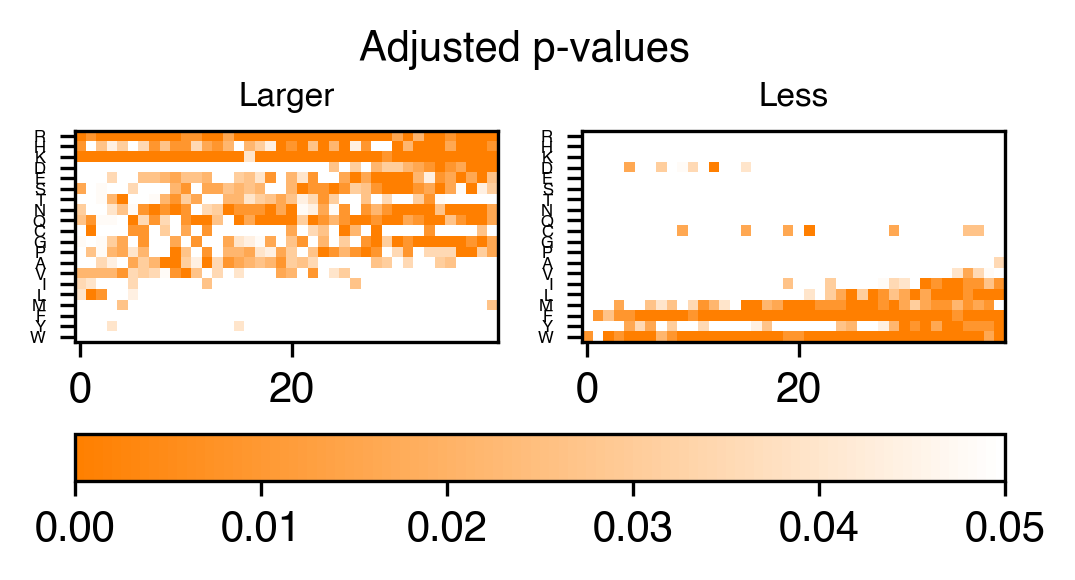

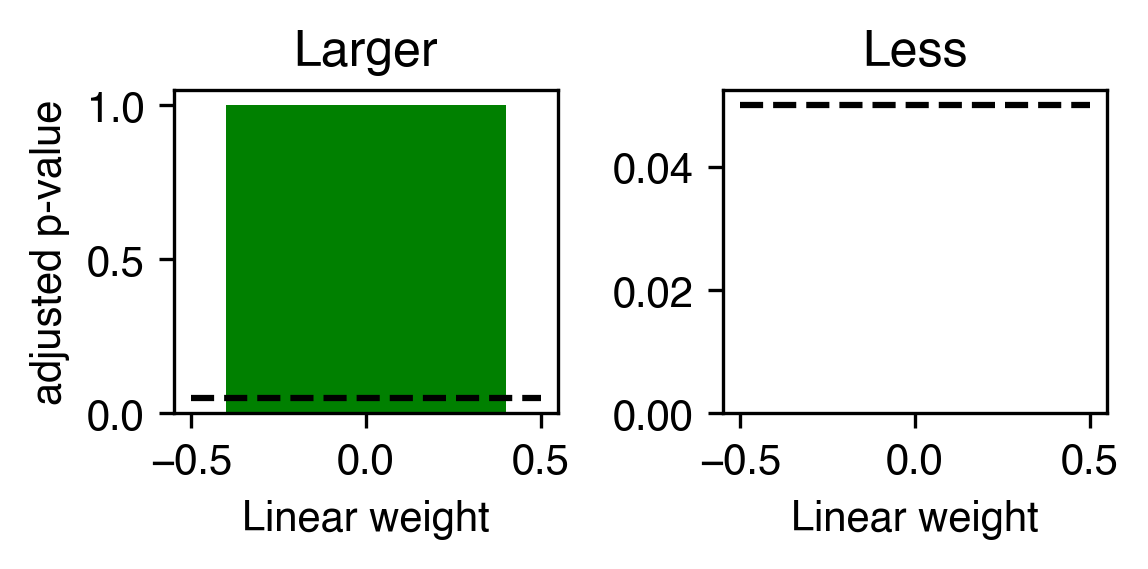

In [360]:
# This is setting up our colors for the plots

# Colors for convolutional filter
colors = [(1, 0.5, 0), (1, 1, 1)]  # Yellow, White
# colors = [(1, 0, 0), (1, 1, 1)]  # Yellow, White
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any

# Colors for AA labels
colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}

fig, axs = plt.subplots(1, 2, figsize=(4, 2))
im = axs[0].imshow(adjusted_p_val_conv_greater.squeeze(0).T, cmap=custom_cmap, vmin=0, vmax=0.05)
axs[0].set_title("Larger", fontsize=8)
# axs[0].set_colorbar()

axs[1].imshow(adjusted_p_val_conv_less.squeeze(0).T, cmap=custom_cmap, vmin=0, vmax=0.05)
axs[1].set_title("Less", fontsize=8)
# axs[1].colorbar()
fig.suptitle("Adjusted p-values", fontsize=10, y=0.9)

axs[0].set_yticks(range(0, 20), orig_aa_order, fontsize=4)
axs[1].set_yticks(range(0, 20), orig_aa_order, fontsize=4)

fig.colorbar(im, ax=axs, orientation="horizontal",pad=0.2)

plt.savefig("figures/for_revision/twostate_k40_conv_position_pvals.pdf", format='pdf', bbox_inches='tight', dpi=1000)

fig, axs = plt.subplots(1, 2, figsize=(4, 2), sharex=True)
axs[0].bar(x=range(0,1), height=adjusted_p_val_linear_greater, color='green')
axs[0].set_xlabel("Linear weight")
axs[0].set_ylabel("adjusted p-value")
axs[0].hlines(0.05, -0.5, 0.5, color='black', linestyles='--')
axs[0].set_title("Larger")

axs[1].bar(x=range(1), height=adjusted_p_val_linear_less, color='green')
axs[1].set_xlabel("Linear weight")
# axs[1].set_ylabel("adjusted p-value")
axs[1].hlines(0.05, -0.5, 0.5, color='black', linestyles='--')
axs[1].set_title("Less")

fig.tight_layout()

plt.savefig("figures/for_revision/twostate_k40_linear_position_pvals.pdf", format='pdf', bbox_inches='tight', dpi=1000)

# Results for two-state abund only k = 40

In [190]:
# For two state model - get size and seed to compare, and then get corresponding shuffle results

two_state_best_model = get_best_model(two_model_results, spearman_abund=True, spearman_act=True, pearson_act=True)
two_state_best_model = two_state_best_model[two_state_best_model["activity_fun"] == "Hill"].reset_index(drop=True)
two_state_seed = two_state_best_model.loc[0, 'seed']
two_state_k = two_state_best_model.loc[0, 'kernel_size']
two_state_ak = two_state_best_model.loc[0, 'abund_k']

two_state_comparison_subset = shuffled_results_two_state_abund_only[(shuffled_results_two_state_abund_only['seed'] == two_state_seed) & (shuffled_results_two_state_abund_only['kernel_size'] == two_state_k) & (shuffled_results_two_state_abund_only['abund_k'] == two_state_ak)].drop_duplicates()
two_state_comparison_subset

,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,spearman_abund_val,...,pearson_abund_train,pearson_act_train,K1_negative,K2_negative,abund_negative,relu,total_params,shuffle_number,seed,abund_k
0,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,0.000740,0.786773,-0.001808,...,0.179005,0.831651,True,NaN,False,False,1418,0,1298091,30
1,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,-0.020468,0.791876,-0.066845,...,0.184680,0.830487,True,NaN,False,False,1418,1,1298091,30
2,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,-0.037927,0.781321,0.029729,...,0.193410,0.831238,False,NaN,False,False,1418,2,1298091,30
3,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,-0.029983,0.787974,-0.013276,...,0.178939,0.828151,True,NaN,False,False,1418,3,1298091,30
4,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,-0.003084,0.788909,0.005400,...,0.191142,0.831989,True,NaN,False,False,1418,4,1298091,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,-0.005936,0.789217,0.020013,...,0.203158,0.837314,True,NaN,False,False,1418,395,1298091,30
396,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,-0.006454,0.787177,-0.029870,...,0.187885,0.834517,True,NaN,False,False,1418,396,1298091,30
397,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,-0.010204,0.791031,0.013520,...,0.169058,0.831347,True,NaN,False,False,1418,397,1298091,30
398,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,40,Hill,0.5,0.1,1,-0.010728,0.786076,0.054290,...,0.197665,0.829724,True,NaN,False,False,1418,398,1298091,30


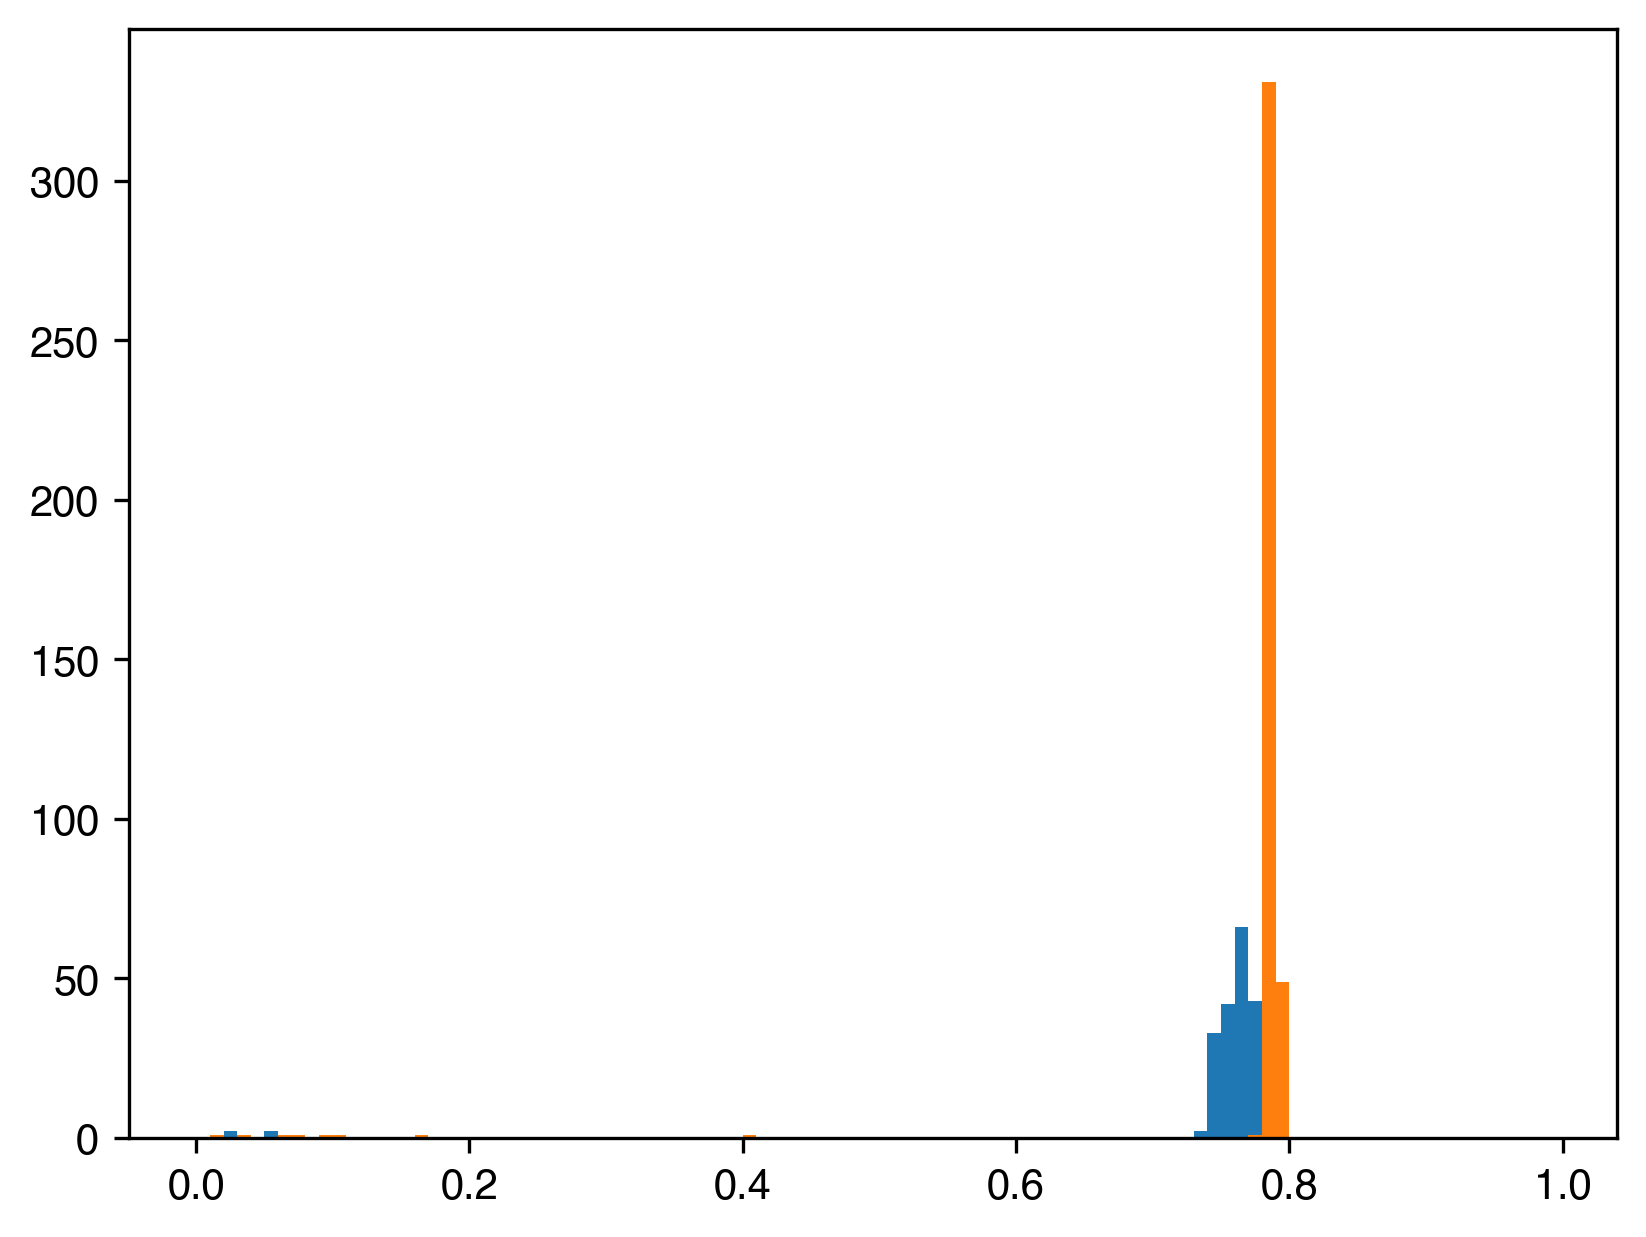

In [191]:
bins = np.arange(0, 1, 0.01)
plt.hist(two_model_results[two_model_results['kernel_size'] == 40]['spearman_act_test'], bins=bins)
plt.hist(shuffled_results_two_state_abund_only['spearman_act_test'], bins=bins)
plt.show()

In [ ]:
# Order of AAs for plotting
amino_acids = ["R","K","H","D","E","M","I","L","V","A","F","Y","W","Q","N","S","T","G","P","C"]

def get_conv_weights(model, layer): 
    """
    Extracts the convolutional layer weights and
    returns them as a pandas dataframe
    """
    model_state_dict = model.state_dict()
    width = model_state_dict[layer].shape[0] * model_state_dict[layer].shape[2]
    conv_weight = model_state_dict[layer].detach().numpy().reshape(width,20)
    conv_weights = pd.DataFrame(conv_weight,columns = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"])
    conv_weights = conv_weights[amino_acids]
    return conv_weights

def get_linear_weights(model, layer, kernel_size):
    """
    Extracts the linear layer weights and
    returns them as a numpy array. Also returns the 
    corresponding x-axis values
    """
    linear_weights = (40 - kernel_size + 1)
    model_state_dict = model.state_dict()
    linear_weight = model_state_dict[layer].detach().numpy().reshape(linear_weights)
    x_vals = np.array(range(0,linear_weights))
    return linear_weight, x_vals

# This is setting up our colors for the plots

# Colors for convolutional filter
colors = [(1, 0, 0), (1, 1, 1), (0, 0, 1)]  # Red, White, Blue
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any

# Colors for AA labels
colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}

def make_row_plot_abund(fig, kernel_size, model, row, lim, height_ratios, num_rows, abund_kernel_size):
    """
    Core functionality for creating the convolutional filter plots. 
    Plots the convolution filter as a heatmap and the linear weights as a bar plot.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object created with plt.figure
    
    kernel_size : int
        The size of the convolutional filter

    model : ADModel_abund
        Loaded model (from which parameters will be extracted)
    
    row : int
        Which row in the overall figure should we fill in

    lim : float
        The max value for the heatmap

    height_ratios : list
        Ratio of heights between rows, length should correspond to number of rows in
        gridspec object

    num_rows : list
        The number of rows in the gridspec object

    Returns
    -------
    ax1 : maplotlib.Axes object
        Contains the heatmap
    ax2 : maplotlib.Axes object
        Contains the barplot
    im1 : maplotlib.Axes.imshow object
        The heatmap
    """

    # Load the convolutional and linear weights for both NN blocks
    model_conv1 = get_conv_weights(model, "conv1.weight").T
    model_linear1, model_xvals1 = get_linear_weights(model, "linear1.weight", kernel_size)

    model_conv2 = get_conv_weights(model, "conv2.weight").T
    model_linear2, model_xvals2 = get_linear_weights(model, "linear2.weight", abund_kernel_size)

    # Calculate how much of the figure the convolutional filters vs. linear weights will take up
    ratio1 = kernel_size 
    ratio2 = 40 - kernel_size + 1
    ratio1_abund = abund_kernel_size
    ratio2_abund = 40 - abund_kernel_size + 1

    # GridSpec allows us to plot rows/columns with different dimensions
    # Here, we initalize the gridspec object with the total number of rows in our figure
    # But we only fill in the specific row that we are interested in
    # (When combined with many other gridspec objects, they will all line up and look good)
    gs1 = gridspec.GridSpec(2 + num_rows, 5, width_ratios=[ratio1, ratio2, 0.5, ratio1_abund, ratio2_abund], height_ratios=height_ratios, figure=fig)
    
    # axs are matplotlib axes
    ax1 = plt.subplot(gs1[row, 0])
    ax2 = plt.subplot(gs1[row, 1])
    ax3 = plt.subplot(gs1[row, 3])
    ax4 = plt.subplot(gs1[row, 4])


    ## Code for first set of parameters --> K1 predictor
    # This is the code for plotting the convolutional filter as a heatmap
    # Min and max values of heatmap are passed by used
    im1 = ax1.imshow(model_conv1.to_numpy(), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax1.set_yticks(range(len(model_conv1.index)), model_conv1.index)  # Label x-axis with column names
    ax1.set_xticks(np.arange(kernel_size, step=2))

    # This is to color the amino acid labels
    for ytic in ax1.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax1.tick_params(axis='both', which='major', labelsize=6) 

    # This is the code for plotting the linear weights as a bar graph
    ax2.bar(model_xvals1, model_linear1, color="grey")
    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["bottom"].set_position('zero')
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])

    ## Code for second set of parameters --> abundance predictor
    # This is the code for plotting the convolutional filter as a heatmap
    # Min and max values of heatmap are passed by used
    im2 = ax3.imshow(model_conv2.to_numpy(), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax3.set_yticks(range(len(model_conv2.index)), model_conv2.index)  # Label x-axis with column names
    ax3.set_xticks(np.arange(abund_kernel_size, step=2))
    
    # This is to color the amino acid labels
    for ytic in ax3.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax3.tick_params(axis='both', which='major', labelsize=6) 

    # This is the code for plotting the linear weights as a bar graph
    print(model_xvals2, model_linear2)
    ax4.bar(model_xvals2, model_linear2, color="grey")
    ax4.spines["top"].set_visible(False)
    ax4.spines["left"].set_visible(False)
    ax4.spines["right"].set_visible(False)
    ax4.spines["bottom"].set_position('zero')
    ax4.set_xticks([])
    ax4.set_yticks([])
    ax4.set_xticklabels([])
    ax4.set_yticklabels([])


    return ax1, ax2, ax3, ax4, im1, im2



In [ ]:
size = (1,40,20)
import torch 

def load_model(name, k, ak):
    """
    Loads ADModel_two_state_abund
    """
    model = ADModel_two_state_abund(size, "Hill", k, relu=False, abund_k=ak)
    model.load_state_dict(torch.load(f"{name}.pth"))
    return model

shuffled_model = load_model(shuffled_results_two_state_abund_only.loc[0, 'model_name'].replace("../../", ""), 40, 30)

In [ ]:
shuffled_results_two_state_abund_only

In [ ]:
# Get the range for the heatmaps
models = [shuffled_model]
conv_weights = []

for model in models: 
    conv_weights += list(get_conv_weights(model, "conv1.weight").T.values.flatten())
    conv_weights += list(get_conv_weights(model, "conv2.weight").T.values.flatten())

# Max value for heatmaps
lim = max([abs(w) for w in conv_weights])

num_rows = 1

# Create a figure
fig = plt.figure(figsize=(20, 3*num_rows))
title_font = {'fontsize': 15, 'fontweight': 'bold', 'fontname': 'Arial'}

# We add in "padding" rows between the rows we care about
height_ratios = [.3] + [3.3]*num_rows + [.1]*2

# Create a gridspec object
gs1 = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)

# Making the first row a title row
ax1 = plt.subplot(gs1[0,0])
ax1.set_title("Features predicting State2:State1 (two-state NN)", fontdict=title_font)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.patch.set_visible(False)
ax1.axis('off')

ax2 = plt.subplot(gs1[0,1])
ax2.set_title("Features predicting Abundance", fontdict=title_font)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.patch.set_visible(False)
ax2.axis('off')

# Adding the best NN parameters to the first row
ax1, ax2, ax3, ax4, im1, im2 = make_row_plot_abund(fig, 40, shuffled_model, 1, lim, height_ratios, num_rows+1, 30)

ax1.set_title("Convolutional Filter", fontsize=12)
ax2.set_title("Linear weights", fontsize=12)
ax3.set_title("Convolutional Filter", fontsize=12)
ax4.set_title("Linear weights", fontsize=12)

# Create another gridspec object to span the whole figure (1 column) to display the colorbar
gs_cb = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)
cax1 = plt.subplot(gs_cb[2 + num_rows, 0])
cax2 = plt.subplot(gs_cb[2 + num_rows, 1])

# Add the colorbar
fig.colorbar(im1,cax=cax1, orientation='horizontal')
fig.colorbar(im2, cax=cax2, orientation='horizontal')


In [ ]:
best_model = load_model(two_state_best_model.loc[0, 'model_name'].replace("../../", ""), 40, 30)

In [ ]:
def run_biophysical_model(loaded_model,sequence):
    """
    Takes a sequence and run the model on sequence
    """
    encoded_seq = one_hot_encode(sequence).reshape(1,1,40,20)
    seq_tensor = torch.from_numpy(encoded_seq).type(torch.FloatTensor)
    predictions = loaded_model(seq_tensor)
    predictions_act = predictions.detach().numpy().reshape(-1)[1].reshape(1,-1)
    predictions_abund = predictions.detach().numpy().reshape(-1)[0].reshape(1,-1)
    K = loaded_model.get_ks()[0].detach().numpy()[0][0]
    return predictions_abund[0][0], predictions_act[0][0], K


In [ ]:
experiment_data = pd.read_csv("Data/pm_gcn4_sort2_pools_allchannels_wrangled_w_ratio.csv")

In [ ]:
experiment_data["K1"] = [run_biophysical_model(best_model, tile)[2] for tile in experiment_data["aa_seq"]]
experiment_data["abund_pred"] = [run_biophysical_model(best_model, tile)[0] for tile in experiment_data["aa_seq"]]
experiment_data["act_pred"] = [run_biophysical_model(best_model, tile)[1] for tile in experiment_data["aa_seq"]]

In [ ]:
experiment_data['abund_pred'].sample(frac=1)

In [ ]:
experiment_data['shuffled_abund'] = experiment_data['abund_pred'].sample(frac=1).reset_index(drop=True)

In [ ]:
experiment_data['shuffled_abund'] == experiment_data['abund_pred']

In [ ]:
best_model.state_dict()

In [ ]:
beta = 5.5454
K = 0.3321
n = 1

def hill_activation(bound):
    xn = bound ** n 
    kn = K ** n

    numerator = beta * xn
    denom = kn + xn

    output = numerator / denom

    return output

In [ ]:
experiment_data['calculated_bound_shuffle'] = experiment_data['shuffled_abund'] / (1/ experiment_data["K1"] + 1)
experiment_data['calculated_act_shuffle'] = [hill_activation(s) for s in experiment_data['calculated_bound_shuffle']]

In [ ]:
experiment_data['calculated_bound_real'] = experiment_data['abund_pred'] / (1/ experiment_data["K1"] + 1)
experiment_data['calculated_act_real'] = [hill_activation(s) for s in experiment_data['calculated_bound_real']]

In [ ]:
plt.scatter(experiment_data['calculated_act_shuffle'], experiment_data['act_pred'], s=0.5)
plt.scatter(experiment_data['calculated_act_real'], experiment_data['act_pred'], s=0.5)

In [ ]:
# plt.scatter(experiment_data['calculated_act_shuffle'], experiment_data['activity'], s=0.5)
plt.scatter(experiment_data['activity'], experiment_data['calculated_act_shuffle'], s=0.5)
plt.ylabel("Prediction")
plt.xlabel("experiment")
pearsonr(experiment_data.dropna()['activity'].astype('float'), experiment_data.dropna()['calculated_act_shuffle'].astype('float'))

In [ ]:
experiment_data['calculated_act_real']

In [ ]:
# plt.scatter(experiment_data['calculated_act_shuffle'], experiment_data['activity'], s=0.5)
plt.scatter(experiment_data['activity'], experiment_data['calculated_act_real'], s=0.5)
plt.ylabel("Prediction")
plt.xlabel("experiment")

pearsonr(experiment_data.dropna()['activity'].astype('float'), experiment_data.dropna()['calculated_act_real'])

# Results for two-state activity only

In [ ]:
# For two state model - get size and seed to compare, and then get corresponding shuffle results

two_state_best_model = get_best_model(two_model_results, spearman_abund=True, spearman_act=True, pearson_act=True)
two_state_best_model = two_state_best_model[two_state_best_model["activity_fun"] == "Hill"].reset_index(drop=True)
two_state_seed = two_state_best_model.loc[0, 'seed']
two_state_k = two_state_best_model.loc[0, 'kernel_size']
two_state_ak = two_state_best_model.loc[0, 'abund_k']

two_state_comparison_subset = shuffled_results_two_state_act_only[(shuffled_results_two_state_act_only['seed'] == two_state_seed) & (shuffled_results_two_state_act_only['kernel_size'] == two_state_k) & (shuffled_results_two_state_act_only['abund_k'] == two_state_ak)].drop_duplicates()
two_state_comparison_subset

In [ ]:
bins = np.arange(0, 1, 0.01)
plt.hist(two_model_results[two_model_results['kernel_size'] == 40]['spearman_abund_test'], bins=bins)
plt.hist(shuffled_results_two_state_act_only['spearman_abund_test'], bins=bins) # This will always be the same because it is the same seed
plt.show()

In [ ]:
shuffled_model = load_model(shuffled_results_two_state_act_only.loc[0, 'model_name'].replace("../../", ""), 40, 30)

In [ ]:
# Get the range for the heatmaps
models = [shuffled_model]
conv_weights = []

for model in models: 
    conv_weights += list(get_conv_weights(model, "conv1.weight").T.values.flatten())
    conv_weights += list(get_conv_weights(model, "conv2.weight").T.values.flatten())

# Max value for heatmaps
lim = max([abs(w) for w in conv_weights])

num_rows = 1

# Create a figure
fig = plt.figure(figsize=(20, 3*num_rows))
title_font = {'fontsize': 15, 'fontweight': 'bold', 'fontname': 'Arial'}

# We add in "padding" rows between the rows we care about
height_ratios = [.3] + [3.3]*num_rows + [.1]*2

# Create a gridspec object
gs1 = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)

# Making the first row a title row
ax1 = plt.subplot(gs1[0,0])
ax1.set_title("Features predicting State2:State1 (two-state NN)", fontdict=title_font)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.patch.set_visible(False)
ax1.axis('off')

ax2 = plt.subplot(gs1[0,1])
ax2.set_title("Features predicting Abundance", fontdict=title_font)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.patch.set_visible(False)
ax2.axis('off')

# Adding the best NN parameters to the first row
ax1, ax2, ax3, ax4, im1, im2 = make_row_plot_abund(fig, 40, shuffled_model, 1, lim, height_ratios, num_rows+1, 30)

ax1.set_title("Convolutional Filter", fontsize=12)
ax2.set_title("Linear weights", fontsize=12)
ax3.set_title("Convolutional Filter", fontsize=12)
ax4.set_title("Linear weights", fontsize=12)

# Create another gridspec object to span the whole figure (1 column) to display the colorbar
gs_cb = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)
cax1 = plt.subplot(gs_cb[2 + num_rows, 0])
cax2 = plt.subplot(gs_cb[2 + num_rows, 1])

# Add the colorbar
fig.colorbar(im1,cax=cax1, orientation='horizontal')
fig.colorbar(im2, cax=cax2, orientation='horizontal')


# Old functions

In [ ]:
# comparison_subset
orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

k = 30
real_conv_arr, real_linear_arr = get_weights_array(best_model, k_size=k, num_shuffles=1, num_seeds=1, two_state=False)
shuffle_conv_arr, shuffle_linear_arr = get_weights_array(comparison_subset, k_size=k, num_shuffles=400, num_seeds=1, two_state=False)

shuffle_test_stat_arr = shuffle_conv_arr.sum(axis=2) 
real_test_stat_arr = real_conv_arr.sum(axis=2)

p_val_greater = (shuffle_test_stat_arr < real_test_stat_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
for aa, val in zip(orig_aa_order, p_val_greater):
    print(aa, ":", val)

print("min p-val:", 1/(shuffle_test_stat_arr.shape[0] * shuffle_test_stat_arr.shape[1]))

p_val_less = (shuffle_test_stat_arr > real_test_stat_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
for aa, val in zip(orig_aa_order, p_val_less):
    print(aa, ":", val)

print("min p-val:", 1/(shuffle_test_stat_arr.shape[0] * shuffle_test_stat_arr.shape[1]))

# Plotting functions

rows = 4
fig, axs = plt.subplots(4, 5, figsize=(10, 10))
row_idx = 0
col_idx = 0

for i in range(0, len(aa_order)):

    axs[row_idx, col_idx].hist(shuffle_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])])

    axs[row_idx, col_idx].hist(real_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])])


    axs[row_idx, col_idx].set_xlabel(aa_order[i])

    # axs[row_idx, col_idx].set_xticks(range(0, 26, 2), range(0, 26, 2))

    row_idx += 1
    if row_idx == rows:
        row_idx = 0
        col_idx += 1

fig.tight_layout()
plt.show()

p_val_greater = (shuffle_linear_arr < real_linear_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
for aa, val in enumerate(p_val_greater):
    print(aa, ":", val)

print("min p-val:", 1/(shuffle_linear_arr.shape[0] * shuffle_linear_arr.shape[1]))

p_val_less = (shuffle_linear_arr > real_linear_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
for aa, val in enumerate(p_val_less):
    print(aa, ":", val)

print("min p-val:", 1/(real_linear_arr.shape[0] * real_linear_arr.shape[1]))


# Plotting functions - linear weights

rows = 6
fig, axs = plt.subplots(6, 6, figsize=(10, 10))
row_idx = 0
col_idx = 0

for i in range(0, 36):

    axs[row_idx, col_idx].hist(shuffle_linear_arr[:, :, i])

    axs[row_idx, col_idx].hist(real_linear_arr[:, :, i])


    # axs[row_idx, col_idx].set_xlabel(aa_order[i])

    # axs[row_idx, col_idx].set_xticks(range(0, 26, 2), range(0, 26, 2))

    row_idx += 1
    if row_idx == rows:
        row_idx = 0
        col_idx += 1

fig.tight_layout()


In [ ]:
real_test_stat_arr

In [ ]:
get_weights_array(best_model_two_state, k_size=k, num_shuffles=1, num_seeds=1, two_state=True, layer1='conv2.weight', layer2='linear2.weight', abund_k=True)

In [ ]:
# comparison_subset
orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

k = 40
real_conv_arr, real_linear_arr = get_weights_array(best_model_two_state, k_size=k, num_shuffles=1, num_seeds=1, two_state=True)
shuffle_conv_arr, shuffle_linear_arr = get_weights_array(two_state_shuffle_subset, k_size=k, num_shuffles=400, num_seeds=1, two_state=True)

shuffle_test_stat_arr = shuffle_conv_arr.sum(axis=2) #* shuffle_linear_arr
real_test_stat_arr = real_conv_arr.sum(axis=2) #* real_linear_arr

p_val_greater = (shuffle_test_stat_arr < real_test_stat_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
for aa, val in zip(orig_aa_order, p_val_greater):
    print(aa, ":", val)

print("min p-val:", 1/(shuffle_test_stat_arr.shape[0] * shuffle_test_stat_arr.shape[1]))

p_val_less = (shuffle_test_stat_arr > real_test_stat_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
for aa, val in zip(orig_aa_order, p_val_less):
    print(aa, ":", val)

print("min p-val:", 1/(shuffle_test_stat_arr.shape[0] * shuffle_test_stat_arr.shape[1]))

# # Plotting functions

# rows = 4
# fig, axs = plt.subplots(4, 5, figsize=(10, 10))
# row_idx = 0
# col_idx = 0

# for i in range(0, len(aa_order)):

#     axs[row_idx, col_idx].hist(shuffle_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])])

#     axs[row_idx, col_idx].hist(real_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])])


#     axs[row_idx, col_idx].set_xlabel(aa_order[i])

#     # axs[row_idx, col_idx].set_xticks(range(0, 26, 2), range(0, 26, 2))

#     row_idx += 1
#     if row_idx == rows:
#         row_idx = 0
#         col_idx += 1

# fig.tight_layout()
# plt.show()

# p_val_greater = (shuffle_linear_arr < real_linear_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
# for aa, val in enumerate(p_val_greater):
#     print(aa, ":", val)

# print("min p-val:", 1/(shuffle_linear_arr.shape[0] * shuffle_linear_arr.shape[1]))

# p_val_less = (shuffle_linear_arr > real_linear_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
# for aa, val in enumerate(p_val_less):
#     print(aa, ":", val)

# print("min p-val:", 1/(real_linear_arr.shape[0] * real_linear_arr.shape[1]))


# Plotting functions - linear weights

# rows = 6
# fig, axs = plt.subplots(6, 6, figsize=(10, 10))
# row_idx = 0
# col_idx = 0

# for i in range(0, 36):

#     axs[row_idx, col_idx].hist(shuffle_linear_arr[:, :, i])

#     axs[row_idx, col_idx].hist(real_linear_arr[:, :, i])


#     # axs[row_idx, col_idx].set_xlabel(aa_order[i])

#     # axs[row_idx, col_idx].set_xticks(range(0, 26, 2), range(0, 26, 2))

#     row_idx += 1
#     if row_idx == rows:
#         row_idx = 0
#         col_idx += 1

# fig.tight_layout()


In [ ]:
# Beginning of sequence
#  comparison_subset
orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

k = 40
real_conv_arr, real_linear_arr = get_weights_array(best_model_two_state, k_size=k, num_shuffles=1, num_seeds=1, two_state=True)
shuffle_conv_arr, shuffle_linear_arr = get_weights_array(two_state_shuffle_subset, k_size=k, num_shuffles=400, num_seeds=1, two_state=True)

shuffle_test_stat_arr = shuffle_conv_arr[:, :, :20, :].sum(axis=2) #* shuffle_linear_arr
real_test_stat_arr = real_conv_arr[:, :, :20, :].sum(axis=2) #* real_linear_arr

p_val_greater = (shuffle_test_stat_arr < real_test_stat_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
for aa, val in zip(orig_aa_order, p_val_greater):
    print(aa, ":", val)

print("min p-val:", 1/(shuffle_test_stat_arr.shape[0] * shuffle_test_stat_arr.shape[1]))

p_val_less = (shuffle_test_stat_arr > real_test_stat_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
for aa, val in zip(orig_aa_order, p_val_less):
    print(aa, ":", val)

print("min p-val:", 1/(shuffle_test_stat_arr.shape[0] * shuffle_test_stat_arr.shape[1]))

In [ ]:
from statsmodels.stats.multitest import multipletests
adjusted_p = multipletests(p_val_less, method='fdr_bh')
for p1, p2 in zip(adjusted_p[1], p_val_less):
    print(p1, p2)

In [ ]:
# End of sequence
#  comparison_subset
orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

k = 40
real_conv_arr, real_linear_arr = get_weights_array(best_model_two_state, k_size=k, num_shuffles=1, num_seeds=1, two_state=True)
shuffle_conv_arr, shuffle_linear_arr = get_weights_array(two_state_shuffle_subset, k_size=k, num_shuffles=400, num_seeds=1, two_state=True)

shuffle_test_stat_arr = shuffle_conv_arr[:, :, 20:, :].sum(axis=2) #* shuffle_linear_arr
real_test_stat_arr = real_conv_arr[:, :, 20:, :].sum(axis=2) #* real_linear_arr

p_val_greater = (shuffle_test_stat_arr < real_test_stat_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
for aa, val in zip(orig_aa_order, p_val_greater):
    print(aa, ":", val)

print("min p-val:", 1/(shuffle_test_stat_arr.shape[0] * shuffle_test_stat_arr.shape[1]))

p_val_less = (shuffle_test_stat_arr > real_test_stat_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
for aa, val in zip(orig_aa_order, p_val_less):
    print(aa, ":", val)

print("min p-val:", 1/(shuffle_test_stat_arr.shape[0] * shuffle_test_stat_arr.shape[1]))

In [ ]:
from statsmodels.stats.multitest import multipletests
adjusted_p = multipletests(p_val_greater, method='fdr_bh')
for p1, p2 in zip(adjusted_p[1], p_val_greater):
    print(p1, p2)

In [ ]:
# comparison_subset
orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

k = 30
real_conv_arr, real_linear_arr = get_weights_array(best_model_two_state, k_size=k, num_shuffles=1, num_seeds=1, two_state=True, layer1='conv2.weight', layer2='linear2.weight', abund_k=True)
shuffle_conv_arr, shuffle_linear_arr = get_weights_array(two_state_shuffle_subset, k_size=k, num_shuffles=400, num_seeds=1, two_state=True,  layer1='conv2.weight', layer2='linear2.weight', abund_k=True)

shuffle_test_stat_arr = shuffle_conv_arr.sum(axis=2) #* shuffle_linear_arr
real_test_stat_arr = real_conv_arr.sum(axis=2) #* real_linear_arr

p_val_greater = (shuffle_test_stat_arr < real_test_stat_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
for aa, val in zip(orig_aa_order, p_val_greater):
    print(aa, ":", val)

print("min p-val:", 1/(shuffle_test_stat_arr.shape[0] * shuffle_test_stat_arr.shape[1]))

p_val_less = (shuffle_test_stat_arr > real_test_stat_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
for aa, val in zip(orig_aa_order, p_val_less):
    print(aa, ":", val)

print("min p-val:", 1/(shuffle_test_stat_arr.shape[0] * shuffle_test_stat_arr.shape[1]))

# # Plotting functions

# rows = 4
# fig, axs = plt.subplots(4, 5, figsize=(10, 10))
# row_idx = 0
# col_idx = 0

# for i in range(0, len(aa_order)):

#     axs[row_idx, col_idx].hist(shuffle_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])])

#     axs[row_idx, col_idx].hist(real_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])])


#     axs[row_idx, col_idx].set_xlabel(aa_order[i])

#     # axs[row_idx, col_idx].set_xticks(range(0, 26, 2), range(0, 26, 2))

#     row_idx += 1
#     if row_idx == rows:
#         row_idx = 0
#         col_idx += 1

# fig.tight_layout()
# plt.show()

# p_val_greater = (shuffle_linear_arr < real_linear_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
# for aa, val in enumerate(p_val_greater):
#     print(aa, ":", val)

# print("min p-val:", 1/(shuffle_linear_arr.shape[0] * shuffle_linear_arr.shape[1]))

# p_val_less = (shuffle_linear_arr > real_linear_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
# for aa, val in enumerate(p_val_less):
#     print(aa, ":", val)

# print("min p-val:", 1/(real_linear_arr.shape[0] * real_linear_arr.shape[1]))


# Plotting functions - linear weights

# rows = 6
# fig, axs = plt.subplots(6, 6, figsize=(10, 10))
# row_idx = 0
# col_idx = 0

# for i in range(0, 36):

#     axs[row_idx, col_idx].hist(shuffle_linear_arr[:, :, i])

#     axs[row_idx, col_idx].hist(real_linear_arr[:, :, i])


#     # axs[row_idx, col_idx].set_xlabel(aa_order[i])

#     # axs[row_idx, col_idx].set_xticks(range(0, 26, 2), range(0, 26, 2))

#     row_idx += 1
#     if row_idx == rows:
#         row_idx = 0
#         col_idx += 1

# fig.tight_layout()


In [ ]:
# plt.imshow(((shuffle_conv_arr < real_conv_arr).sum(axis=0).sum(axis=0) / shuffle_conv_arr.shape[0]).T)
plt.imshow((((shuffle_conv_arr > real_conv_arr).sum(axis=0).sum(axis=0) / shuffle_conv_arr.shape[0])).T, cmap='bone')

plt.yticks(range(0, 20), orig_aa_order)
plt.colorbar()

In [ ]:
# plt.imshow(((shuffle_conv_arr < real_conv_arr).sum(axis=0).sum(axis=0) / shuffle_conv_arr.shape[0]).T)
plt.imshow((((shuffle_conv_arr < real_conv_arr).sum(axis=0).sum(axis=0) / shuffle_conv_arr.shape[0])).T, cmap='bone')

plt.yticks(range(0, 20), orig_aa_order)
plt.colorbar()

In [ ]:
orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

k = 40
real_conv_arr, real_linear_arr = get_weights_array(best_model_two_state, k_size=k, num_shuffles=1, num_seeds=1, two_state=True)
shuffle_conv_arr, shuffle_linear_arr = get_weights_array(two_state_shuffle_subset, k_size=k, num_shuffles=400, num_seeds=1, two_state=True)

shuffle_test_stat_arr = shuffle_conv_arr.sum(axis=2) * shuffle_linear_arr
real_test_stat_arr = real_conv_arr.sum(axis=2) * real_linear_arr

p_val_greater = (shuffle_test_stat_arr < real_test_stat_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
for aa, val in zip(orig_aa_order, p_val_greater):
    print(aa, ":", val)

print("min p-val:", 1/(shuffle_test_stat_arr.shape[0] * shuffle_test_stat_arr.shape[1]))

p_val_less = (shuffle_test_stat_arr > real_test_stat_arr).sum(axis=0).sum(axis=0) / shuffle_test_stat_arr.shape[0]
for aa, val in zip(orig_aa_order, p_val_less):
    print(aa, ":", val)

print("min p-val:", 1/(shuffle_test_stat_arr.shape[0] * shuffle_test_stat_arr.shape[1]))

In [ ]:
# conv_arr dim
# Dim 1: Shuffle number
# Dim 2: seed
# Dim 3: kernel size
# Dim 4: aa num (20)
k = 40
real_conv_arr, real_linear_arr = get_weights_array(simple_model_results, k_size=k, num_shuffles=1, num_seeds=30, two_state=False)
shuffle_conv_arr, shuffle_linear_arr = get_weights_array(shuffled_results_act, k_size=k, num_shuffles=25, num_seeds=30, two_state=False)
cosine_sim_shuffle, cosine_sim_real = cosine_similarity(shuffle_conv_arr, real_conv_arr, real_linear_arr)
sum_shuffle, sum_real = weight_sum(shuffle_conv_arr, real_conv_arr, real_linear_arr)

print("Sum p-values")
p_vals = p_val_less_than(sum_shuffle, sum_real)

print("Cosine p-values") # higher min p-value because more comparisons
p_vals = p_val_greater_than(cosine_sim_shuffle, cosine_sim_real)

print("Cosine p-values mean")
p_vals = p_val_greater_than_mean(cosine_sim_shuffle, cosine_sim_real)

make_boxplot(sum_shuffle, sum_real, 1, 3, aa_order = ["H", "R", "K"])
make_boxplot(cosine_sim_shuffle, cosine_sim_real, 1, 3, aa_order = ["H", "R", "K"])



In [ ]:
sum_real.max(axis=1).shape

In [ ]:
sum_shuffle.shape

In [ ]:
sum_shuffle[:, :, 2].min()

In [ ]:
sum_real.max(axis=1)[0, 2]

In [ ]:
(sum_shuffle[:, :, 2] < sum_real.max(axis=1)[0, 2]).sum(axis=0).sum(axis=0)

In [ ]:
sum_real.max(axis=1)[0, 0]

In [ ]:
sum_real.max(axis=1).reshape(1, 1, 20)

In [ ]:
(sum_shuffle > sum_real.max(axis=1).reshape(1, 1, 20)).sum(axis=0).sum(axis=0) 

In [ ]:
make_boxplot(sum_shuffle, sum_real, 4, 5)

In [ ]:
make_boxplot(cosine_sim_shuffle, cosine_sim_real, 4, 5)

In [ ]:
make_boxplot(sum_shuffle, sum_real, 1, 3, aa_order = ["H", "R", "K"])

In [ ]:
make_boxplot(cosine_sim_shuffle, cosine_sim_real, 1, 3, aa_order = ["H", "R", "K"])

In [ ]:
cosine_sim_shuffle.shape

In [ ]:
sum_shuffle.shape

In [ ]:
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"] 

fig, axs = plt.subplots(4, 5, figsize=(40, 20))

row_idx = 0
col_idx = 0

for i in range(0, 20):

    axs[row_idx, col_idx].boxplot(cosine_sim_shuffle[:, :, i].T)

    axs[row_idx, col_idx].boxplot(cosine_sim_real[:, :, i].T, positions=[26], 
                                  widths=1.0, patch_artist=True, boxprops=dict(facecolor='blue'))

    axs[row_idx, col_idx].set_xlabel(aa_order[i], fontsize=20)

    axs[row_idx, col_idx].set_xticks(range(0, 26, 2), range(0, 26, 2))

    row_idx += 1
    if row_idx == 4:
        row_idx = 0
        col_idx += 1

    

In [ ]:
col_idx = 0
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

for i in range(0, 3):

    axs[col_idx].boxplot(cosine_sim_shuffle[:, :, i].T)

    axs[col_idx].boxplot(cosine_sim_real[:, :, i].T, positions=[26], 
                                  widths=1.0, patch_artist=True, boxprops=dict(facecolor='blue'))

    axs[col_idx].set_xlabel(aa_order[i], fontsize=20)

    axs[col_idx].set_xticks(range(0, 26, 2), range(0, 26, 2))

    col_idx += 1
plt.show()

# Downsampling

In [ ]:
# Downsampling

# weight_ls dim
# Dim 1: Shuffle number
# Dim 2: seed
# Dim 3: kernel size
# Dim 4: aa num (20)

vars_ls = np.zeros((4, 39, 100, 2))

# i loops through shuffles
for i in tqdm(range(1, 40)):
    for j in range(100):
        rng = np.random.default_rng()

        downsample_10 = calculate_simiarities(rng.permutation(shuffled_weight_ls[i], axis=0)[0:10, :, :])[0] 
        downsample_10_mean = np.mean(downsample_10)
        downsample_10_var = np.var(downsample_10)

        downsample_15 = calculate_simiarities(rng.permutation(shuffled_weight_ls[i], axis=0)[0:15, :, :])[0] 
        downsample_15_mean = np.mean(downsample_15)
        downsample_15_var = np.var(downsample_15)

        downsample_20 = calculate_simiarities(rng.permutation(shuffled_weight_ls[i], axis=0)[0:20, :, :])[0] 
        downsample_20_mean = np.mean(downsample_20)
        downsample_20_var = np.var(downsample_20)

        downsample_30 = calculate_simiarities(rng.permutation(shuffled_weight_ls[i], axis=0)[0:30, :, :])[0] 
        downsample_30_mean = np.mean(downsample_30)
        downsample_30_var = np.var(downsample_30)

        vars_ls[0, i-1, j, 0] = downsample_10_mean
        vars_ls[0, i-1, j, 1] = downsample_10_var

        vars_ls[1, i-1, j, 0] = downsample_15_mean
        vars_ls[1, i-1, j, 1] = downsample_15_var

        vars_ls[2, i-1, j, 0] = downsample_20_mean
        vars_ls[2, i-1, j, 1] = downsample_20_var

        vars_ls[3, i-1, j, 0] = downsample_30_mean
        vars_ls[3, i-1, j, 1] = downsample_30_var

# Dim 1: downsample type
# Dim 2: Shuffle #
# Dim 3: Permutation repeat (100 total) --> For 30, should be the same per shuffle
# Dim 4: Var or mean 

In [ ]:
vars_ls[3, 0:1, :101, 0]

In [ ]:
vars_ls[:, :10, :10, :]

In [ ]:
shuffled_weight_ls[1].shape

In [ ]:
# No replacement, sum is the same every time

# Caclulate cosine simiarity between all positions
rng.permuted(shuffled_weight_ls[1][0:30, :, :]).sum()

In [ ]:
permuted_ls = rng.permuted(shuffled_weight_ls[1][0:30, :, :])

In [ ]:
30 * 30

In [ ]:
# Calculate the Frobenius distance
# The 'ord="fro"' argument specifies the Frobenius norm
from scipy.signal import correlate2d

def calculate_simiarities(weight_matrix):
    cosine_similarities = []
    correlations = []
    cross_correlations = []

    # Looping through all matrix positions
    max_dim = weight_matrix.shape[0]
    for i in range(max_dim):
        for j in range(max_dim):
            # distance = np.linalg.norm(real_weight_ls[i] - real_weight_ls[j], ord="fro") # This is bad because it doesn't ignore differences in magnitude
            
            # Correlating two matricies
            correlation = np.corrcoef(weight_matrix[i].flatten(),weight_matrix[j].flatten())[0][1] #np.corrcoef(real_weight_ls[i],real_weight_ls[j] )
            if np.isnan(correlation):
                print(i, j)
            correlations.append(correlation)

            # Cosine similarity 
            cos_sim = np.sum(weight_matrix[i] * weight_matrix[j]) / (np.linalg.norm(weight_matrix[i]) * np.linalg.norm(weight_matrix[j]))
            cosine_similarities.append(cos_sim)
            
            # cross correlation
            C_1 = correlate2d(weight_matrix[i], weight_matrix[j], mode='same')
            cross_corr = np.max(C_1) / (np.linalg.norm(weight_matrix[i]) * np.linalg.norm(weight_matrix[j]))
            cross_correlations.append(cross_corr)
    
    return cosine_similarities, correlations, cross_correlations

In [ ]:
# First dim is shuffle
# Second dim is seed
# Third dem in k size
# Fourth dem is aa
# We want to sample: Different kernels --> Permute second dimension

shuffled_weight_ls[1, :, :, :].shape

In [ ]:
# What is spread of means for each rep and downsample? 
# What is the spread of variances for each rep and downsample

width = 0.18
n = vars_ls[0, 0:30, :, 0].reshape(100,30).shape[1]
base = np.arange(n)

fig, axs = plt.subplots(1, 1, figsize=(15, 2))

# For var_ls
# Dim 1: downsample type
# Dim 2: Shuffle #
# Dim 3: Permutation repeat (100 total) --> For 30, should be the same per shuffle
# Dim 4: Var or mean 
 
# Ten seeds
# vars_ls[0, 0:30, :, 0] --> First downsample type, all thirty shuffles, all repeats, mean --> Reshape to be repeat x shuffle (each shuffle gets separate box plot)
plt.boxplot(vars_ls[0, 0:30, :, 0].squeeze().squeeze().T, positions=base - 1.5*width, widths=width, patch_artist=True, boxprops=dict(facecolor='red'), label="Downsample to 10 seeds")

# Fifteen seeds
plt.boxplot(vars_ls[1, 0:30, :, 0].squeeze().squeeze().T, positions=base - 0.5*width, widths=width, patch_artist=True, boxprops=dict(facecolor='orange'), label="Downsample to 15 seeds")

# Twenty seeds
plt.boxplot(vars_ls[2, 0:30, :, 0].squeeze().squeeze().T, positions=base + 0.5*width, widths=width, patch_artist=True, boxprops=dict(facecolor='green'), label="Downsample to 20 seeds")

# Thirty seeds
plt.boxplot(vars_ls[3, 0:30, :, 0].squeeze().squeeze().T, positions=base + 1.5*width, widths=width, patch_artist=True, boxprops=dict(facecolor='blue'), label="Downsample to 30 seeds")

plt.xlabel("Shuffle")
plt.ylabel("Mean across sampling")
plt.xticks(range(0, 30), range(0, 30))
plt.legend(frameon=False, bbox_to_anchor = (0.2, -0.2))

plt.show()

In [ ]:
# What is spread of means for each rep and downsample? 
# What is the spread of variances for each rep and downsample

width = 0.18
n = vars_ls[0, 0:30, :, 0].reshape(100,30).shape[1]
base = np.arange(n)

fig, axs = plt.subplots(1, 1, figsize=(15, 2))

plt.boxplot(vars_ls[0, 0:30, :, 1].squeeze().squeeze().T, positions=base - 1.5*width, widths=width, patch_artist=True, boxprops=dict(facecolor='red'), label="Downsample to 10 seeds")
plt.boxplot(vars_ls[1, 0:30, :, 1].squeeze().squeeze().T, positions=base - 0.5*width, widths=width, patch_artist=True, boxprops=dict(facecolor='orange'), label="Downsample to 15 seeds")
plt.boxplot(vars_ls[2, 0:30, :, 1].squeeze().squeeze().T, positions=base + 0.5*width, widths=width, patch_artist=True, boxprops=dict(facecolor='green'), label="Downsample to 20 seeds")
plt.boxplot(vars_ls[3, 0:30, :, 1].squeeze().squeeze().T, positions=base + 1.5*width, widths=width, patch_artist=True, boxprops=dict(facecolor='blue'), label="Downsample to 30 seeds")

plt.xlabel("Shuffle")
plt.ylabel("Var across sampling")
plt.xticks(range(0, 30), range(0, 30))
plt.legend(frameon=False, bbox_to_anchor = (0.2, -0.2))

plt.show()

In [ ]:
real_cosine_similarities, real_correlations, real_cross_correlations = calculate_simiarities(real_weight_ls.squeeze())

In [ ]:
np.mean(cosine_similarities)

In [ ]:
1/100

In [ ]:
# cosine_means = [np.mean(sub_ls) for sub_ls in cosine_sim_ls]
plt.hist(vars_ls[0, :, 0, 0], label="Shuffles (downsampled to 10)", alpha=0.5)
plt.hist(vars_ls[1, :, 0, 0], label="Shuffles (downsampled to 15)", alpha=0.5)
plt.hist(vars_ls[2, :, 0, 0], label="Shuffles (downsampled to 20)", alpha=0.5)
plt.hist(vars_ls[3, :, 0, 0], label="Shuffles (no downsampling)", alpha=0.5)

plt.vlines(np.mean(real_cosine_similarities), ymin=0, ymax=8, color = 'black')
plt.xlabel("Mean conv. filter cosine similarity between seeds (k=10)")

plt.legend(frameon=False)
sns.despine()

In [ ]:
# cosine_means = [np.mean(sub_ls) for sub_ls in cosine_sim_ls]
plt.hist(vars_ls[0, :, 0, 1], label="Shuffles (downsampled to 10)", alpha=0.5)
plt.hist(vars_ls[1, :, 0, 1], label="Shuffles (downsampled to 15)", alpha=0.5)
plt.hist(vars_ls[2, :, 0, 1], label="Shuffles (downsampled to 20)", alpha=0.5)
plt.hist(vars_ls[3, :, 0, 1], label="Shuffles (no downsampling)", alpha=0.5)

plt.vlines(np.var(real_cosine_similarities), ymin=0, ymax=8, color = 'black')
plt.xlabel("Variance of conv. filter cosine similarity between seeds (k=10)")

plt.legend(frameon=False)
sns.despine()

# Compare sum of all positive weights

In [ ]:
# Downsampling

# weight_ls dim
# Dim 1: Shuffle number
# Dim 2: seed
# Dim 3: kernel size
# Dim 4: aa num (20)

vars_ls = np.zeros((47, 30, 20))

# i loops through shuffles
for i in tqdm(range(1, 47)):

    for j in range(20):
        weight_sum = np.sum(shuffled_weight_ls[i, :, :, j], axis=1)
        vars_ls[i-1, :, j] = weight_sum

# Dim 1: downsample type
# Dim 2: Shuffle #
# Dim 3: Permutation repeat (100 total) --> For 30, should be the same per shuffle
# Dim 4: Var or mean 

In [ ]:
real_weight_ls.shape

In [ ]:
real_linear_weight_ls.shape

In [ ]:
real_weight_sum = real_weight_ls[0, :, :, 0].sum(axis=1)
neg_weight_filter = (real_linear_weight_ls > 0).all(axis=2)

In [ ]:
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"] 

fig, axs = plt.subplots(4, 5, figsize=(40, 20))

row_idx = 0
col_idx = 0

for i in range(0, 20):

    axs[row_idx, col_idx].boxplot(vars_ls[:, :, i].T)

    real_weight_sum = real_weight_ls[0, :, :, i].sum(axis=1)
    
    # Only looking at + weight filters
    axs[row_idx, col_idx].boxplot(real_weight_sum[neg_weight_filter.squeeze()], positions=[49], 
                                  widths=1.0, patch_artist=True, boxprops=dict(facecolor='blue'))

    # Only looking at - weight filters
    axs[row_idx, col_idx].boxplot(real_weight_sum[~ neg_weight_filter.squeeze()], positions=[49], 
                                   widths=1.0, patch_artist=True, boxprops=dict(facecolor='red'))


    axs[row_idx, col_idx].set_xlabel(aa_order[i], fontsize=20)

    axs[row_idx, col_idx].set_xticks(range(0, 49, 2), range(0, 49, 2))

    row_idx += 1
    if row_idx == 4:
        row_idx = 0
        col_idx += 1

plt.show()

In [ ]:
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"] 

fig, axs = plt.subplots(1, 3, figsize=(20, 5))

row_idx = 0
col_idx = 0

for i in range(0, 3):

    axs[col_idx].boxplot(vars_ls[:, :, i].T)

    real_weight_sum = real_weight_ls[0, :, :, i].sum(axis=1)
    axs[col_idx].boxplot(real_weight_sum, positions=[48], widths=1.0, patch_artist=True, boxprops=dict(facecolor='blue'))
    axs[col_idx].set_xlabel(aa_order[i], fontsize=20)

    axs[col_idx].set_xticks(range(0, 49, 2), range(0, 49, 2))

    col_idx += 1
plt.show()

In [ ]:
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"] 

fig, axs = plt.subplots(1, 3, figsize=(20, 5))

row_idx = 0
col_idx = 0

for i in range(0, 3):

    axs[col_idx].boxplot(vars_ls[:, :, i].T)

    real_weight_sum = real_weight_ls[0, :, :, i].sum(axis=1)
    
        # Only looking at + weight filters
    axs[col_idx].boxplot(real_weight_sum[neg_weight_filter.squeeze()], positions=[49], 
                                  widths=1.0, patch_artist=True, boxprops=dict(facecolor='blue'))

    # Only looking at - weight filters
    axs[col_idx].boxplot(real_weight_sum[~ neg_weight_filter.squeeze()], positions=[49], 
                                   widths=1.0, patch_artist=True, boxprops=dict(facecolor='red'))

    axs[col_idx].set_xlabel(aa_order[i], fontsize=20)

    axs[col_idx].set_xticks(range(0, 49, 2), range(0, 49, 2))

    col_idx += 1
plt.show()

In [ ]:
real_weight_sum[~ neg_weight_filter.squeeze()]

In [ ]:
real_weight_sum[neg_weight_filter.squeeze()]

In [ ]:
# Significantly smaller: 
for i in range(0, 20):
    shuffles = vars_ls[:, :, i].flatten()
    real_weight_sum = real_weight_ls[0, :, :, i].sum(axis=1)

    print(f"aa: {aa_order[i]}", sum(shuffles < real_weight_sum.max()) / len(shuffles))

In [ ]:
1 / len(shuffles) # min p-value

In [ ]:
# Significantly larger: 
for i in range(0, 20):
    shuffles = vars_ls[:, :, i].flatten()
    real_weight_sum = real_weight_ls[0, :, :, i].sum(axis=1)

    print(f"aa: {aa_order[i]}", sum(shuffles > real_weight_sum.min()) / len(shuffles))

# Comparing weight similarity

In [ ]:
# Dim 1: Shuffle number
# Dim 2: seed
# Dim 3: kernel size
# Dim 4: aa num (20)

shuffled_weight_ls.shape

In [ ]:
import scipy.spatial as sp

In [ ]:
# Cosine similarity between vectors
# Dot product between vectors / magnitude of two vectors


In [ ]:
# Cosine similarities of a specific weight
shuffle_num = 0
aa_num = 0

similarities_0 = []
for i in range(29):
    for j in range(i+1, 30):
        vector1 = shuffled_weight_ls[shuffle_num, i, :, aa_num]
        vector2 = shuffled_weight_ls[shuffle_num, j, :, aa_num]
        
        sim = np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2))  
        similarities_0.append(sim)

similarities_0_real = []
for i in range(29):
    for j in range(i+1, 30):
        vector1 = real_weight_ls[shuffle_num, i, :, aa_num]
        vector2 = real_weight_ls[shuffle_num, j, :, aa_num]
        
        sim = np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2))  
        similarities_0_real.append(sim)

plt.hist(similarities_0_real)
plt.hist(similarities_0, alpha=0.5)

In [ ]:
np.corrcoef(vector1, vector2)[0][1] 

In [ ]:
# Correlation of a specific weight
shuffle_num = 0
aa_num = 0

similarities_0 = []
for i in range(29):
    for j in range(i+1, 30):
        vector1 = shuffled_weight_ls[shuffle_num, i, :, aa_num]
        vector2 = shuffled_weight_ls[shuffle_num, j, :, aa_num]
        
        sim = np.corrcoef(vector1, vector2)[0][1] 
        similarities_0.append(sim)

similarities_0_real = []
for i in range(29):
    for j in range(i+1, 30):
        vector1 = real_weight_ls[shuffle_num, i, :, aa_num]
        vector2 = real_weight_ls[shuffle_num, j, :, aa_num]
        
        sim = np.corrcoef(vector1, vector2)[0][1]  
        similarities_0_real.append(sim)
        
plt.hist(similarities_0_real)
plt.hist(similarities_0, alpha=0.5)

In [ ]:
# Frobenius norm
shuffle_num = 0
aa_num = 2

similarities_0 = []
for i in range(29):
    for j in range(i+1, 30):
        vector1 = shuffled_weight_ls[shuffle_num, i, :, aa_num]
        vector2 = shuffled_weight_ls[shuffle_num, j, :, aa_num]
        
        sim = np.linalg.norm(vector1 - vector2)  
        similarities_0.append(sim)

similarities_0_real = []
for i in range(29):
    for j in range(i+1, 30):
        vector1 = real_weight_ls[shuffle_num, i, :, aa_num]
        vector2 = real_weight_ls[shuffle_num, j, :, aa_num]
        
        sim = np.linalg.norm(vector1 - vector2)
        similarities_0_real.append(sim)
        
plt.hist(similarities_0_real)
plt.hist(similarities_0, alpha=0.5)

In [ ]:
plt.imshow(real_weight_ls[shuffle_num, i, :, :].T)

In [ ]:
plt.imshow(real_weight_ls[shuffle_num, j, :, :].T)

In [ ]:
aa_num = 2

plt.plot(real_weight_ls[shuffle_num, i, :, aa_num])
plt.plot(real_weight_ls[shuffle_num, j, :, aa_num])

plt.plot(shuffled_weight_ls[shuffle_num, i, :, aa_num])
plt.plot(shuffled_weight_ls[shuffle_num, j, :, aa_num])